**Course**: Computational Social Science, Homework #2  
**Team**: FightClub  
**Research topic**: Brainrot analysis  
**Lecturer**: Andrew Kurochkin  
**Date**: October 2026  
**Place**: National University of Kyiv-Mohyla Academy, Faculty of Informatics

# Time spent
|  Name  | Time |
| ---    |  ---   |
| Danylo | 15h 5m  |
| Ivan   | 12h   |
| Daryna | 7h   |
| Total |  34h 5m  | 


# Table of contents
0. Overview
    1. Hypotheses
    2. Datasets
    3. Additional approaches
1. H1: Discourse is getting shorter and simpler
    1. Overview
    2. Activity and distribution
    3. Lexical & NLP analysis
        1. Shrinking vocabulary
        2. Sentences are getting shorter
        3. Lempel-Ziv algorithm
    4. Temporal/Behavioral analysis
2. H3: Wellbeing is getting worse among doomscrollers
    1. Description of the Analysis Concept
    2. Data Landscape
    3. Datasets Analysis
    4. The Conceptual Framework
        1. Sleep & Circadian Rhythms
3. H4: Crises intensify doomscrolling and negativity
    1. Overview
        1. Events
        2. Communities
        3. Data
    2. Methods
    3. Do crises show up in what people write?
    4. Did each event reach each community?
    5. Did tone get more negative after the events?
    6. Did talk about doomscrolling rise after the events?
    7. Did brainrot words spike around the crises?
    8. Did posting sessions in r/nosurf get longer?
    9. Do the same r/nosurf authors write differently after an event?
    10. Result
4. Result

# 0. Overview
Since our goal is many-sided and has certain specific characteristics, we will follow our own flow with exploration and analysis of data. We already have hypotheses to test and we will try to find approaches in order to prove those hypothese right or wrong. We will not follow guidelines or try to check any boxes, instead we will follow our curiosity and play until we have the answer.

However, there is one guideline: before freestyling with analysis - explore the data and brainstorm what visualizations should be made.

Since we have 4 different hypotheses to test, the research is structured into 4 independent parts, each of them testing one hypothesis and doing separate data overview. Each hypothesis is tested with separate datasets and those datasets are reviewed independently in each of 4 parts. After that some of the results and findings are merged.

## 0.1 Hypotheses
Our topic is analysis of impact of doomscrolling and brainrot on people, discourse, their wellbeing and cognitive abilities over time. We study the effects of doomscrolling with the hypotheses below.

- H1: Discourse is getting shorter and simpler
    - Lexical & NLP approach
    - Temporal/Behavioral aspect
- H2: Short-form platforms accelerated the degradation of discourse
- H3: Wellbeing is getting worse among doomscrollers
- H4: Crises intensify doomscrolling and negativity

## 0.2 Datasets
Each hypothesis is proven by using different datasets.

### H1: Discourse is getting shorter and simpler  
Comments and submissions from reddit, collected from 01.2012 to 09.2026, divided into different categories.

1. Short-form: r/memes, r/teenagers
2. Long-form: r/books, r/explainlikeimfive
3. Baseline: r/todayilearned
4. Qualitative: r/nosurf

### H2: Short-form platforms accelerated the degradation of discourse
1. [Reels/Shorts Consumption vs Attention Span](https://www.kaggle.com/datasets/jayjoshi37/reelsshorts-consumption-vs-attention-span)

### H3: Wellbeing is getting worse among doomscrollers
1. [Social Media Addiction dataset](https://www.kaggle.com/datasets/engieid/social-media-addiction-dataset)
2. [The Dark At The End Of The Tunnel: Doomscrolling On Social Media Newsfeeds](https://osf.io/u9f6h/)
3. [Sleep & Doomscrolling Habits Dataset](https://www.kaggle.com/datasets/harpartapsingh13/sleep-and-doomscrolling-habits-dataset)
4. [Social Media and Mental Health](https://www.kaggle.com/datasets/souvikahmed071/social-media-and-mental-health)
5. [Student Social Media & Mental Health](https://www.kaggle.com/datasets/shivasingh4945/student-social-media-and-mental-health-impact)

### H4: Crises intensify doomscrolling and negativity


## 0.3 Additional approaches
- Questionnaire - work in progress
- YouTube comments - work in progress

# 1 H1: Discourse is getting shorter and simpler

In this section we test this hypothesis with data. We'll be analyzing the discourse of a dataset of 9.2 million comments and 1.8 million submissions that were posted on reddit between 2012 and 2026.

Before getting into data and into analysis, in order to pick the correct analysis path, let's take a bird's-eye view of our data and on our goal. We want to verify that over the 14 years discourse has been getting shorter and simpler. In order to check that, we have two approaches:

1. **Lexical & NLP approach**
2. **Temporal/Behavioral aspect**

In **Lexical & NLP approach** we analyse sentences and check the following metrics:

1. Vocabulary is shrinking
2. Sentences are getting shorter
    1. Words per comment
    2. Words per sentence
3. Lempel-Ziv algorithm
    1. Concatenation of comments into fixed-size chunks per subreddit per month

In **Temporal/Behavioral aspect** we analyze conversantions and look into:

1. Thread depth
    1. Thread size
    2. Share or replies vs top-level comments
    3. True depth <!-- download full month for that -->

Ideas for analysis:

1. Readability (Flesch-Kincaid)
2. Avg word length

## 1.1. Overview
Our dataset consists of 9,237,205 comments and 1,870,257 posts, collected from 01.2012 to 09.2026, from these subreddits:

1. Short-form: r/memes, r/teenagers
2. Long-form: r/books, r/explainlikeimfive
3. Baseline: r/todayilearned
4. Qualitative: r/nosurf

Dataset was downloaded from [Arctic Shift API](https://arctic-shift.photon-reddit.com/). We didn't download full dataset of comments and posts because of the size and downloading time. Instead, we sampled 10,000 comments per subreddit per month and 2,000 posts per subreddit per month. Samples are downloaded from random time slots. Each month is cut into equal time slots, each slot holding roughly 1,000 comments or 200 posts. For our subreddits total amount of comments is 346.4 million and total amount of posts is 27.3 million. Our sample covers about 2.7% of all comments and 6.9% of all posts.


In [118]:
"""
!Important!
Libraries needed:
 - 


Overview here:
- number of records
- timeframe
"""

"""
1. Setup
"""
from pathlib import Path
import duckdb
import pandas as pd

DATA = Path("data/reddit_arctic")
con = duckdb.connect()
con.sql("SET TimeZone = 'UTC'")   # Reddit timestamps are UTC; without this DuckDB uses your computer's time zone

FOLDERS = {"comments": "comments", "posts": "submissions"}
for view, folder in FOLDERS.items():
    con.sql(f"""CREATE OR REPLACE VIEW {view} AS
                SELECT * FROM read_parquet('{(DATA / folder).as_posix()}/**/*.parquet', hive_partitioning=false)""")

In [119]:
"""
2. Number of records, timeframe, size
"""
rows = []
for view, folder in FOLDERS.items():
    files = list((DATA / folder).rglob("*.parquet"))
    stats = con.sql(f"""
        SELECT count(*)                                                     AS records,
               count(DISTINCT subreddit)                                    AS subreddits,
               min(to_timestamp(created_utc))::DATE                         AS first_record,
               max(to_timestamp(created_utc))::DATE                         AS last_record,
               count(DISTINCT strftime(to_timestamp(created_utc), '%Y-%m')) AS months
        FROM {view}""").df().iloc[0].to_dict()
    rows.append({"type": view, **stats, "files": len(files),
                 "size_MB": round(sum(f.stat().st_size for f in files) / 1024**2, 1)})
overview = pd.DataFrame(rows).set_index("type")
overview

,records,subreddits,first_record,last_record,months,files,size_MB
type,,,,,,,
comments,9237205,6,2012-01-01,2026-09-30,177,1062,897.5
posts,1870257,6,2012-01-01,2026-09-30,177,1062,225.4


In [120]:
"""
3. Per subreddit, the sample vs everything on Reddit
"""
totals = pd.read_csv(DATA / "_monthly_totals.csv")
per_sub = []
for view, total_col in [("comments", "comments_total"), ("posts", "posts_total")]:
    s = con.sql(f"""SELECT subreddit, strftime(to_timestamp(created_utc), '%Y-%m') AS month, count(*) AS sampled
                    FROM {view} GROUP BY ALL""").df()
    m = totals[["subreddit", "month", total_col]].merge(s, on=["subreddit", "month"], how="left").fillna({"sampled": 0})
    g = m.groupby("subreddit").agg(sampled=("sampled", "sum"), total=(total_col, "sum"),
                                   first_month=("month", "min"), last_month=("month", "max"))
    g["coverage_%"] = (100 * g["sampled"] / g["total"]).round(1)
    g["complete_months"] = (m["sampled"] >= 0.99 * m[total_col]).groupby(m["subreddit"]).sum()
    g.columns = pd.MultiIndex.from_product([[view], g.columns])
    per_sub.append(g)
per_sub = pd.concat(per_sub, axis=1)
per_sub

comments                                               \
                   sampled      total first_month last_month coverage_%   
subreddit                                                                 
books              1876751   13137631     2012-01    2026-09       14.3   
explainlikeimfive  1852536   21058471     2012-01    2026-09        8.8   
memes              1334537  108528872     2012-01    2026-09        1.2   
nosurf              478540     478745     2012-01    2026-09      100.0   
teenagers          1843775  133272831     2012-01    2026-09        1.4   
todayilearned      1851066   69926671     2012-01    2026-09        2.6   

                                      posts                                   \
                  complete_months   sampled     total first_month last_month   
subreddit                                                                      
books                           0  368255.0    890216     2012-01    2026-09   
explainlikeimfive               0  369085.0   2000253     2012-01    2026-09   
memes                          62  343402.0  11858295     2012-01    2026-09   
nosurf                        177   56057.0     56082     2012-01    2026-09   
teenagers                       0  363975.0  10305407     2012-01    2026-09   
todayilearned                   0  369483.0   2162300     2012-01    2026-09   

                                              
                  coverage_% complete_months  
subreddit                                     
books                   41.4               0  
explainlikeimfive       18.5               0  
memes                    2.9              38  
nosurf                 100.0             177  
teenagers                3.5               8  
todayilearned           17.1               0

## 1.2 Activity and distribution
Before analysing the datasets, let's explore the activity over the last 14 years. First 2 plots represent the streamgraphs of comments and posts per day for all subreddit in absolute values. In August 2018 TikTok global, in March 2020 COVID-19 took place and TikTok went viral during the same period of time, as can seen on the streamgraph.

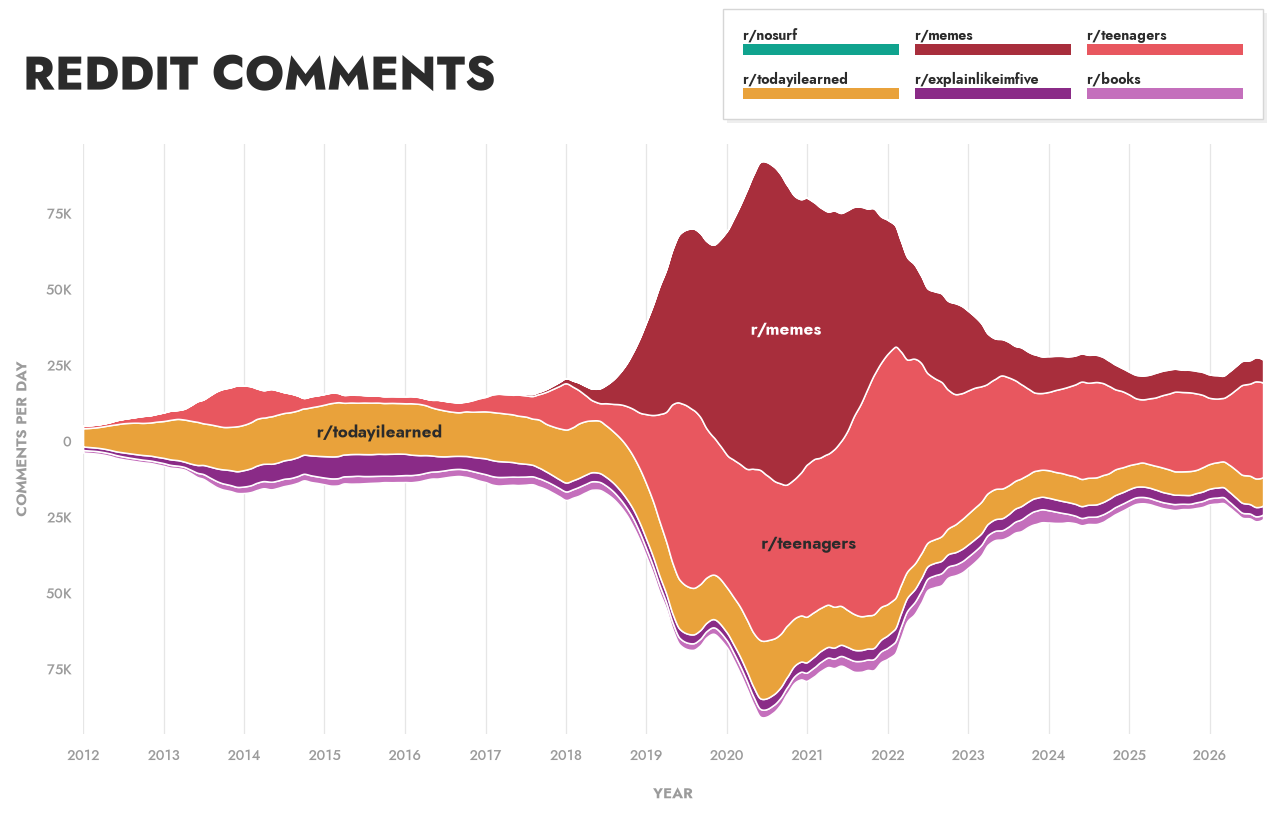

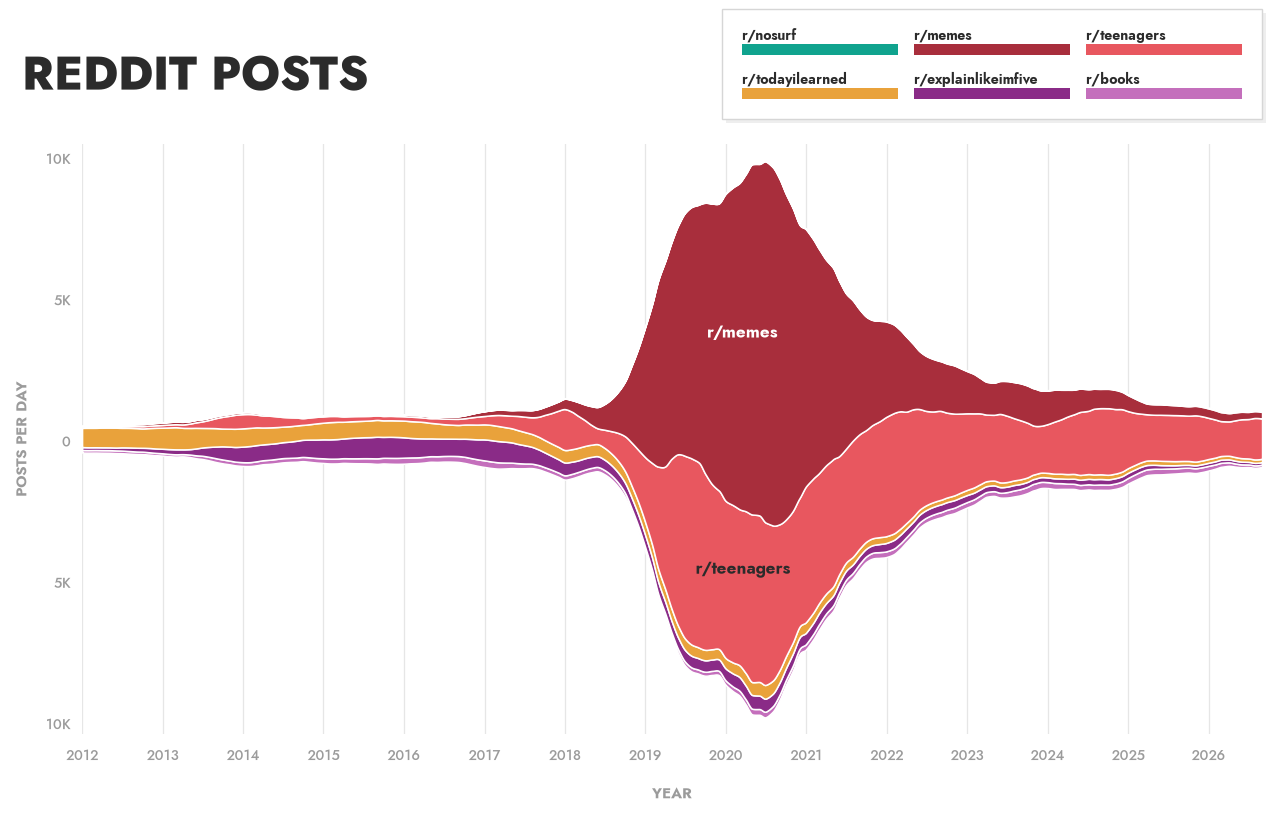

In [121]:
# Libraries: pandas, numpy, matplotlib, scipy   (pip install scipy, if missing)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import font_manager
from matplotlib.patches import Rectangle
from scipy.interpolate import PchipInterpolator

DATA = Path("data/reddit_arctic")


# ---- font: Jost, loaded straight from its .ttf files ------------------------------------------------------------
def find_jost():
    """Folder with Jost-Bold.ttf: looks in fonts/ (any subfolder) next to the notebook and up to two folders above."""
    for base in [Path.cwd(), *list(Path.cwd().parents)[:2]]:
        for pattern in ("fonts/**/Jost-Bold.ttf", "jost_fonts/**/Jost-Bold.ttf"):
            hit = next(base.glob(pattern), None)
            if hit:
                return hit.parent
    return None


JOST_DIR = find_jost()
JOST_FILES = {"light": "Jost-Light.ttf", "regular": "Jost-Medium.ttf", "medium": "Jost-Medium.ttf",
              "semibold": "Jost-SemiBold.ttf", "bold": "Jost-Bold.ttf", "heavy": "Jost-ExtraBold.ttf"}
if JOST_DIR is None:
    _installed = {f.name for f in font_manager.fontManager.ttflist}
    FALLBACK = next((f for f in ["Futura", "Century Gothic", "Avenir Next", "Arial"] if f in _installed), "DejaVu Sans")
    print(f"Jost not found (expected fonts/Jost-*.ttf in {Path.cwd()}); using {FALLBACK} instead.")


def font(weight, size):
    if JOST_DIR is not None and (JOST_DIR / JOST_FILES[weight]).exists():
        return font_manager.FontProperties(fname=JOST_DIR / JOST_FILES[weight], size=size)
    # fallback fonts usually have only regular and bold - asking for other weights causes "findfont" warnings
    return font_manager.FontProperties(family=FALLBACK, size=size,
                                       weight="bold" if weight in ("semibold", "bold", "heavy") else "normal")


# ---- colours and shared helpers -----------------------------------------------------------------------------
STREAMS = [  # bottom -> top; colours checked for colour-blind safety in this order
    ("books", "#C46FBC"),
    ("explainlikeimfive", "#8A2B87"),
    ("todayilearned", "#E9A23B"),
    ("teenagers", "#E8575F"),
    ("memes", "#A82E3C"),
    ("nosurf", "#10A38E"),
]
WRAPPED = {"explainlikeimfive": "r/explain\nlikeimfive", "todayilearned": "r/today\nilearned"}
AREA_ALPHA = 1                                     # areas very slightly transparent
INK, AXIS_TEXT, GRID = "#2b2b2b", "#9b9b9b", "#e6e6e6"


def compact(v, _=None):
    v = abs(v)
    return f"{v / 1e6:g}M" if v >= 1e6 else f"{v / 1e3:g}K" if v >= 1e3 else f"{v:g}"


def label_color(fill, alpha=AREA_ALPHA):
    """White or dark text, whichever contrasts more with the (slightly transparent) fill on white."""
    rgb = [alpha * int(fill[i:i + 2], 16) / 255 + (1 - alpha) for i in (1, 3, 5)]
    lin = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4 for c in rgb]
    lum = 0.2126 * lin[0] + 0.7152 * lin[1] + 0.0722 * lin[2]
    return "white" if 1.05 / (lum + 0.05) >= (lum + 0.05) / 0.074 else INK


def base_figure(title, ylabel):
    """Figure with the plot area, title (top left) and legend (top right) in the reference style."""
    fig = plt.figure(figsize=(13, 8.4), facecolor="white")
    W, H = fig.get_size_inches()
    ax = fig.add_axes([0.95 / W, 0.85 / H, 1 - 1.2 / W, 1 - (0.85 + 1.65) / H])
    fig.text(0.35 / W, 1 - 0.6 / H, title, fontproperties=font("heavy", 34), color=INK, va="top")
    ax.set_xlabel("YEAR", fontproperties=font("bold", 11), color=AXIS_TEXT, labelpad=12)
    ax.set_ylabel(ylabel, fontproperties=font("bold", 11), color=AXIS_TEXT, labelpad=10)

    # legend: framed box, every entry = caption above a colour bar (3 x 2), same order as the bands top to bottom
    entries = list(reversed(STREAMS))
    ncol, col_w, row_h, pad = 3, 1.72, 0.44, 0.2                     # inches
    box_w, box_h = ncol * col_w + 2 * pad - 0.16, -(-len(entries) // ncol) * row_h + 0.22
    lg = fig.add_axes([(W - 0.25 - box_w) / W, (H - 0.3 - box_h) / H, box_w / W, box_h / H])
    lg.set_xlim(0, box_w)
    lg.set_ylim(0, box_h)
    lg.axis("off")
    lg.add_patch(Rectangle((0.04, -0.04), box_w, box_h, facecolor="#eeeeee", edgecolor="none", clip_on=False, zorder=0))
    lg.add_patch(Rectangle((0, 0), box_w, box_h, facecolor="white", edgecolor="#d6d6d6", linewidth=1, clip_on=False, zorder=1))
    for i, (s, c) in enumerate(entries):
        x0, y0 = pad + (i % ncol) * col_w, box_h - 0.16 - (i // ncol) * row_h
        lg.text(x0, y0, f"r/{s}", fontproperties=font("bold", 10), color=INK, va="top", ha="left", zorder=2)
        lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=c, alpha=AREA_ALPHA,
                               edgecolor="none", zorder=2))
    return fig, ax


def style_axes(ax, xs, index):
    years = pd.date_range(index[0], index[-1], freq="YS")
    ax.set_xticks(mdates.date2num(years), [str(y.year) for y in years])
    ax.set_xlim(xs[0], xs[-1])
    ax.grid(axis="x", color=GRID, linewidth=0.9, zorder=0)
    ax.grid(axis="y", visible=False)
    for side in ax.spines.values():
        side.set_visible(False)
    ax.tick_params(length=0, pad=8)
    for lab in ax.get_xticklabels():
        lab.set_fontproperties(font("regular", 10))
        lab.set_color(AXIS_TEXT)


def style_y_labels(ax):
    for lab in ax.get_yticklabels():
        lab.set_fontproperties(font("regular", 10))
        lab.set_color(AXIS_TEXT)


def smooth(per_day, smooth_months=5):
    """Monthly values -> smooth curves on a dense grid (5-month moving average + shape-preserving interpolation)."""
    v = per_day[[s for s, _ in STREAMS]].rolling(smooth_months, center=True, min_periods=1).mean()
    x = mdates.date2num(v.index)
    xs = np.linspace(x[0], x[-1], len(x) * 10)
    ys = np.array([np.clip(PchipInterpolator(x, v[s].to_numpy())(xs), 0, None) for s in v.columns])
    return xs, ys


def label_bands(ax, xs, lower, upper, sizes=(12, 10)):
    """Write each subreddit's name inside its band, where the band is widest. Bands too thin for text get none."""
    W, H = ax.figure.get_size_inches()
    pos = ax.get_position()
    ax_w, ax_h = pos.width * W, pos.height * H
    y_per_inch = np.diff(ax.get_ylim())[0] / ax_h
    step = xs[1] - xs[0]
    for i, (s, c) in enumerate(STREAMS):
        candidates = [(size, text) for size in sizes for text in (f"r/{s}", WRAPPED.get(s)) if text]
        for size, text in candidates:
            n_lines = text.count("\n") + 1
            width_in = max(map(len, text.split("\n"))) * size * 0.6 / 72 + 0.3
            need = (n_lines * size * 1.25 / 72 + 0.1) * y_per_inch
            win = max(3, int(width_in / ax_w * (xs[-1] - xs[0]) / step))
            floor = pd.Series(lower[i]).rolling(win, center=True).max()      # highest lower edge under the text
            ceil = pd.Series(upper[i]).rolling(win, center=True).min()       # lowest upper edge under the text
            room = (ceil - floor).to_numpy()
            if np.nanmax(room) >= need:
                j = int(np.nanargmax(room))
                ax.text(xs[j], (floor[j] + ceil[j]) / 2, text, ha="center", va="center", linespacing=1.1,
                        fontproperties=font("bold", size), color=label_color(c), zorder=4)
                break


# ---- streamgraph --------------------------------------------------------------------------------------------
def streamgraph(per_day, title, ylabel):
    """Streams centred on a horizontal axis; y-axis = absolute values measured from the centre line."""
    xs, ys = smooth(per_day)
    fig, ax = base_figure(title, ylabel)
    ax.stackplot(xs, *ys, baseline="sym", colors=[c for _, c in STREAMS], alpha=AREA_ALPHA,
                 edgecolor="white", linewidth=1.1, zorder=2)
    style_axes(ax, xs, per_day.index)
    top = ys.sum(axis=0).max() / 2 * 1.06
    ax.set_ylim(-top, top)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8, symmetric=True, steps=[1, 2, 2.5, 5, 10]))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(compact))
    style_y_labels(ax)
    lower = -ys.sum(axis=0) / 2 + np.vstack([np.zeros(len(xs)), np.cumsum(ys, axis=0)[:-1]])
    label_bands(ax, xs, lower, lower + ys)
    plt.show()


monthly = pd.read_csv(DATA / "_monthly_totals.csv", parse_dates=["month"])
days = monthly["month"].dt.days_in_month
comments_per_day = monthly.assign(v=monthly["comments_total"] / days).pivot(index="month", columns="subreddit", values="v")
posts_per_day = monthly.assign(v=monthly["posts_total"] / days).pivot(index="month", columns="subreddit", values="v")

streamgraph(comments_per_day, "REDDIT COMMENTS", "COMMENTS PER DAY")
streamgraph(posts_per_day, "REDDIT POSTS", "POSTS PER DAY")

Let's take a look at stacked area chart which represents the activity of comments and posts per day for all subreddit, but in relative values.

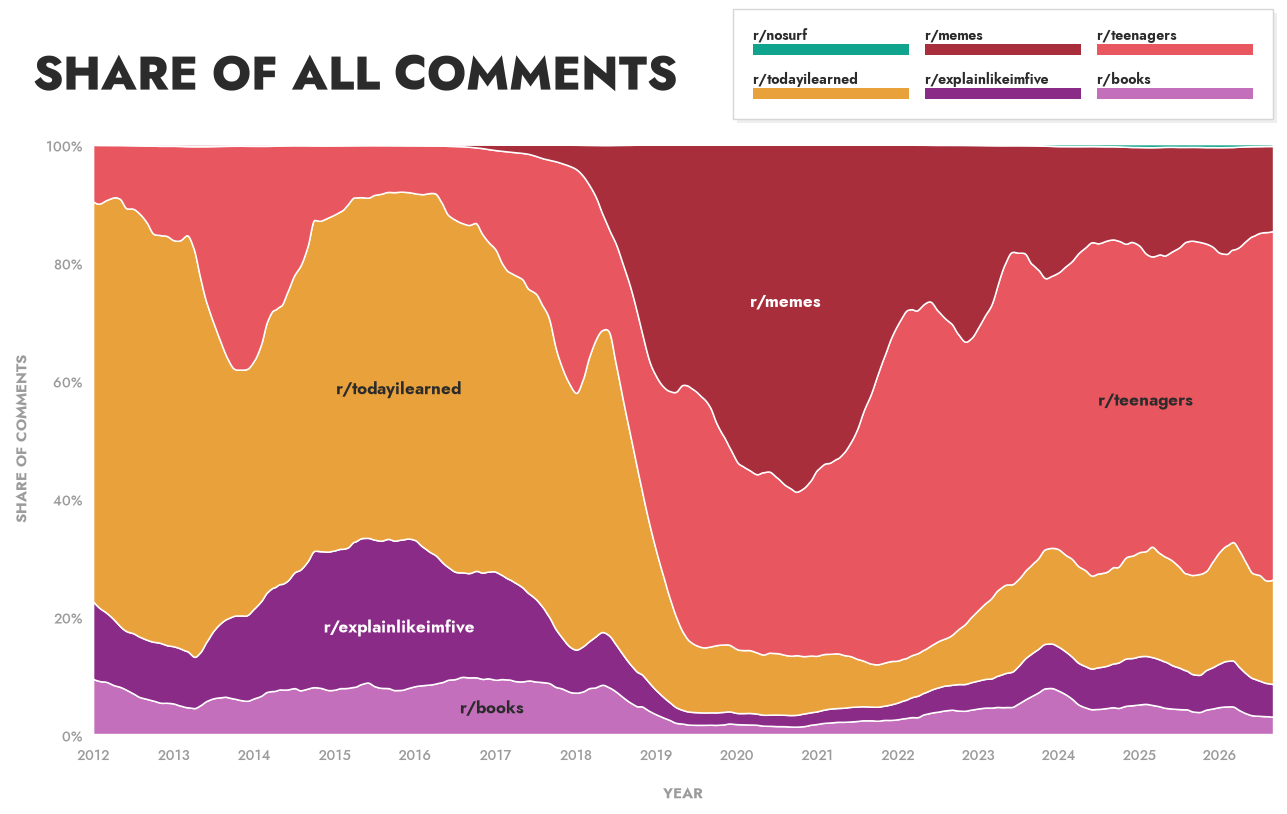

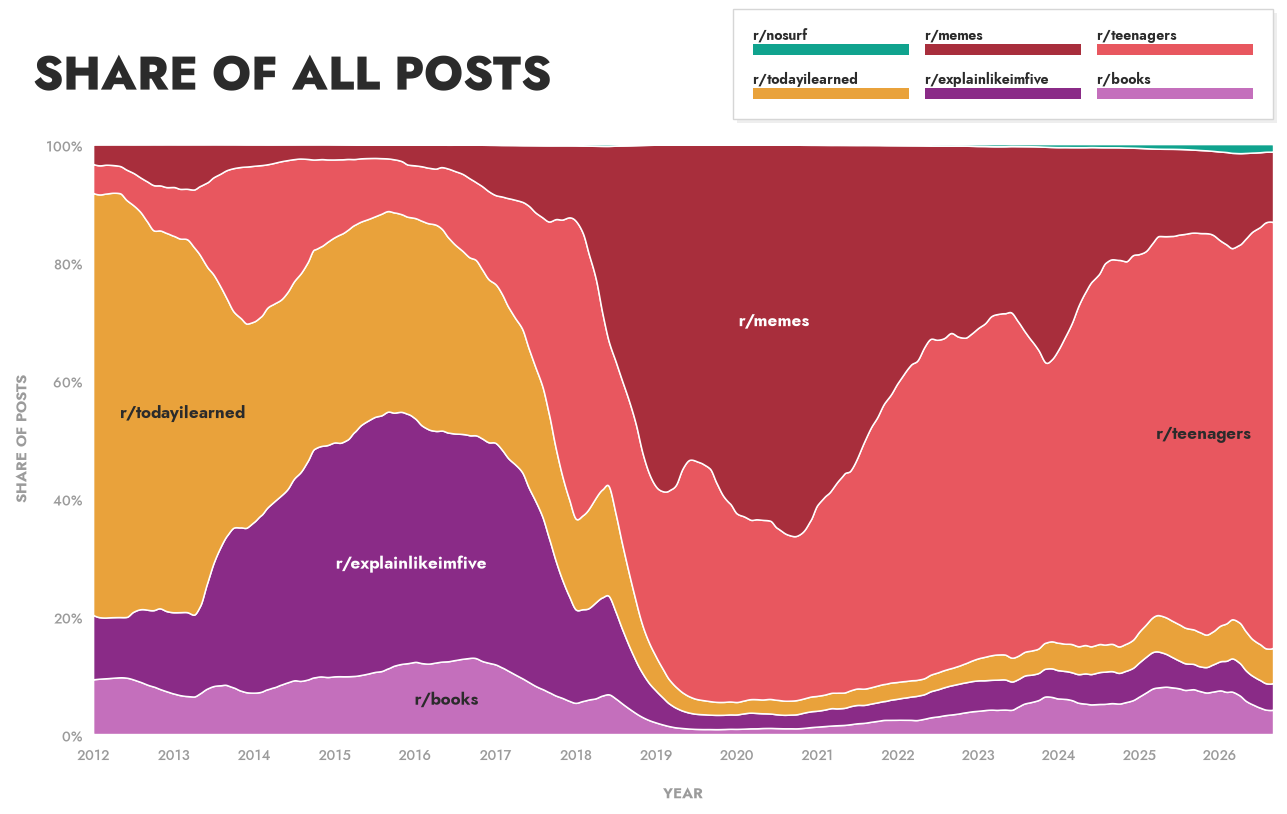

In [122]:
def share_chart(per_day, title, ylabel):
    """100% stacked area: each subreddit's share of the six subreddits' total, names inside the bands."""
    xs, ys = smooth(per_day)
    share = ys / ys.sum(axis=0)                                       # every column sums to 100%
    fig, ax = base_figure(title, ylabel)
    ax.stackplot(xs, *share, colors=[c for _, c in STREAMS], alpha=AREA_ALPHA,
                 edgecolor="white", linewidth=1.1, zorder=2)
    style_axes(ax, xs, per_day.index)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    style_y_labels(ax)
    lower = np.vstack([np.zeros(len(xs)), np.cumsum(share, axis=0)[:-1]])
    label_bands(ax, xs, lower, lower + share)
    plt.show()


share_chart(comments_per_day, "SHARE OF ALL COMMENTS", "SHARE OF COMMENTS")
share_chart(posts_per_day, "SHARE OF ALL POSTS", "SHARE OF POSTS")

Below is a ridgeline chart which represents the activity of each subreddit individually in gradient in absolute values.

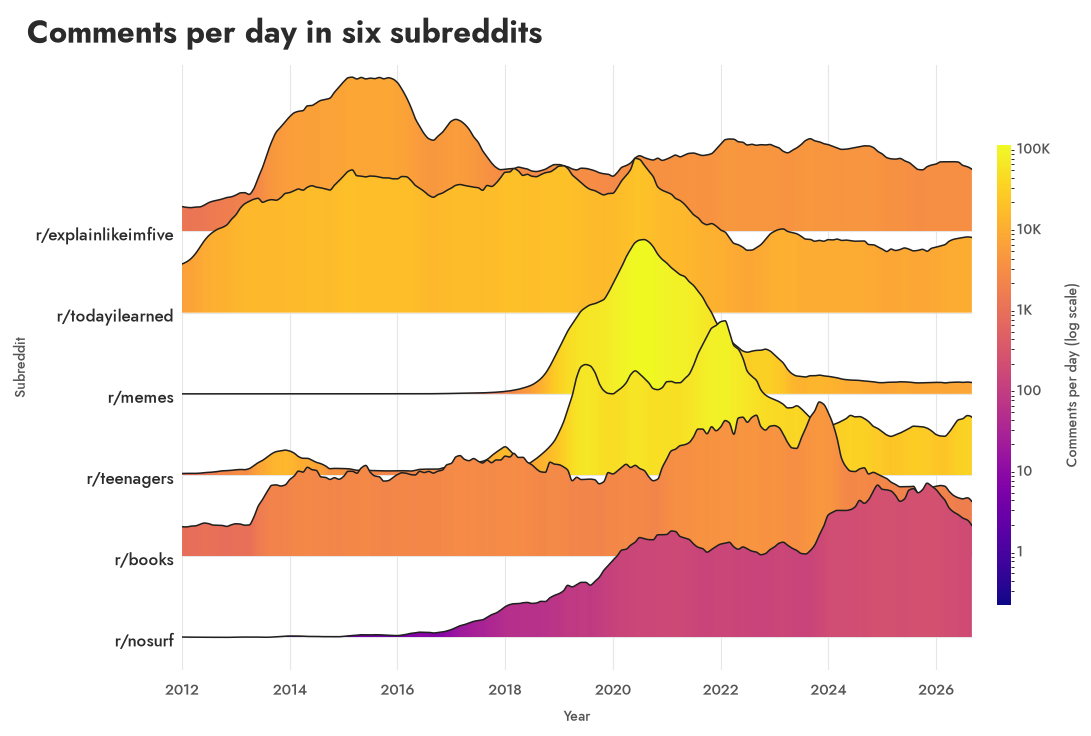

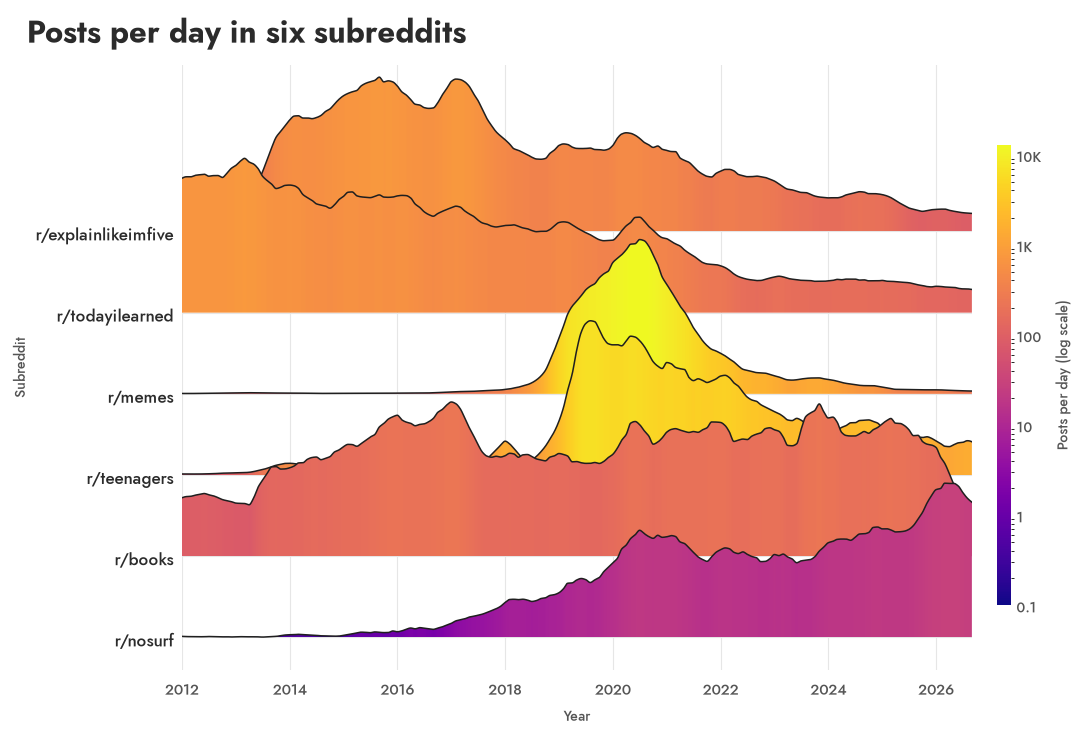

In [123]:
# Run after the streamgraph cell: uses its font(), smooth(), STREAMS, colours, comments_per_day and posts_per_day.
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Polygon

RIDGE_CMAP = plt.get_cmap("plasma")
INK2_RIDGE = "#555555"


def ridgeline(per_day, title, unit, order=None, overlap=1.9):
    """One ridge per subreddit. Height: activity relative to the subreddit's own busiest month.
    Colour: the actual activity per day at that moment, on one log scale shared by all ridges."""
    xs, ys = smooth(per_day)                                       # same smoothing as the streamgraphs
    subs = [s for s, _ in STREAMS]
    values = dict(zip(subs, ys))
    if order is None:                                               # earliest peak at the top
        order = sorted(subs, key=lambda s: xs[np.argmax(values[s])])

    positive = np.concatenate([v[v > 0] for v in values.values()])
    norm = LogNorm(vmin=max(positive.min(), 0.1), vmax=positive.max())

    fig = plt.figure(figsize=(11, 7.6), facecolor="white")
    W, H = fig.get_size_inches()
    ax = fig.add_axes([1.85 / W, 0.75 / H, (W - 3.1) / W, (H - 1.55) / H])
    cax = fig.add_axes([(W - 1.0) / W, 1.4 / H, 0.14 / W, (H - 3.0) / H])

    n = len(order)
    for i, s in enumerate(order):                                   # top row first; lower rows drawn in front
        base = n - 1 - i
        v = values[s]
        top = base + overlap * v / v.max()
        z = 2 + 2 * i
        ridge = Polygon(np.column_stack([np.r_[xs, xs[::-1]], np.r_[top, np.full_like(xs, base)]]),
                        facecolor="none", edgecolor="none", transform=ax.transData)
        ax.add_patch(ridge)
        colours = RIDGE_CMAP(norm(np.clip(v, norm.vmin, None)))[np.newaxis, :, :]
        img = ax.imshow(colours, extent=[xs[0], xs[-1], base, base + overlap], aspect="auto",
                        origin="lower", interpolation="bilinear", zorder=z)
        img.set_clip_path(ridge)                                    # gradient only inside the ridge
        ax.plot(xs, top, color="#1f1f1f", linewidth=1.1, zorder=z + 1)

    # axes in the style of the reference: light grid, row names on the left, small axis titles
    years = pd.date_range(per_day.index[0], per_day.index[-1], freq="2YS")
    ax.set_xticks(mdates.date2num(years), [str(y.year) for y in years])
    ax.set_yticks(range(n), [f"r/{s}" for s in reversed(order)])
    ax.set_xlim(xs[0], xs[-1])
    ax.set_ylim(-0.4, n - 1 + overlap + 0.15)
    ax.grid(color=GRID, linewidth=0.8, zorder=0)
    for side in ax.spines.values():
        side.set_visible(False)
    ax.tick_params(length=0, pad=6)
    for lab in ax.get_xticklabels():
        lab.set_fontproperties(font("regular", 11))
        lab.set_color(INK2_RIDGE)
    for lab in ax.get_yticklabels():
        lab.set_fontproperties(font("medium", 12))
        lab.set_color(INK)
    ax.set_xlabel("Year", loc="center", fontproperties=font("regular", 10), color=INK2_RIDGE)
    ax.set_ylabel("Subreddit", loc="center", fontproperties=font("regular", 10), color=INK2_RIDGE)
    fig.text(0.3 / W, 1 - 0.25 / H, title, fontproperties=font("bold", 22), color=INK, va="top")

    cb = fig.colorbar(ScalarMappable(norm=norm, cmap=RIDGE_CMAP), cax=cax)
    cb.outline.set_visible(False)
    cb.ax.tick_params(length=0, pad=4)
    cb.ax.yaxis.set_major_formatter(mticker.FuncFormatter(compact))
    cb.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    for lab in cb.ax.get_yticklabels():
        lab.set_fontproperties(font("regular", 10))
        lab.set_color(INK2_RIDGE)
    cb.set_label(f"{unit} per day (log scale)", fontproperties=font("regular", 10), color=INK2_RIDGE, labelpad=8)
    plt.show()
    return order


ridge_order = ridgeline(comments_per_day, "Comments per day in six subreddits", "Comments")
_ = ridgeline(posts_per_day, "Posts per day in six subreddits", "Posts", order=ridge_order)

## 1.3 Lexical & NLP analysis
Let's analyze sentances with the following metrics:

1. Vocabulary is shrinking
2. Sentences are getting shorter
    1. Words per comment
    2. Words per sentence
3. Lempel-Ziv algorithm
    1. Concatenation of comments into fixed-size chunks per subreddit per month

### 1.3.1. Shrinking vocabulary
Question is if people use fewer different words over time. In order to find that we measure distinct lemmas per 10,000 words per month per subreddit.

25,949 chunks of 10,000 words; 968 of 1062 subreddit-months have at least 3 chunks and are shown.


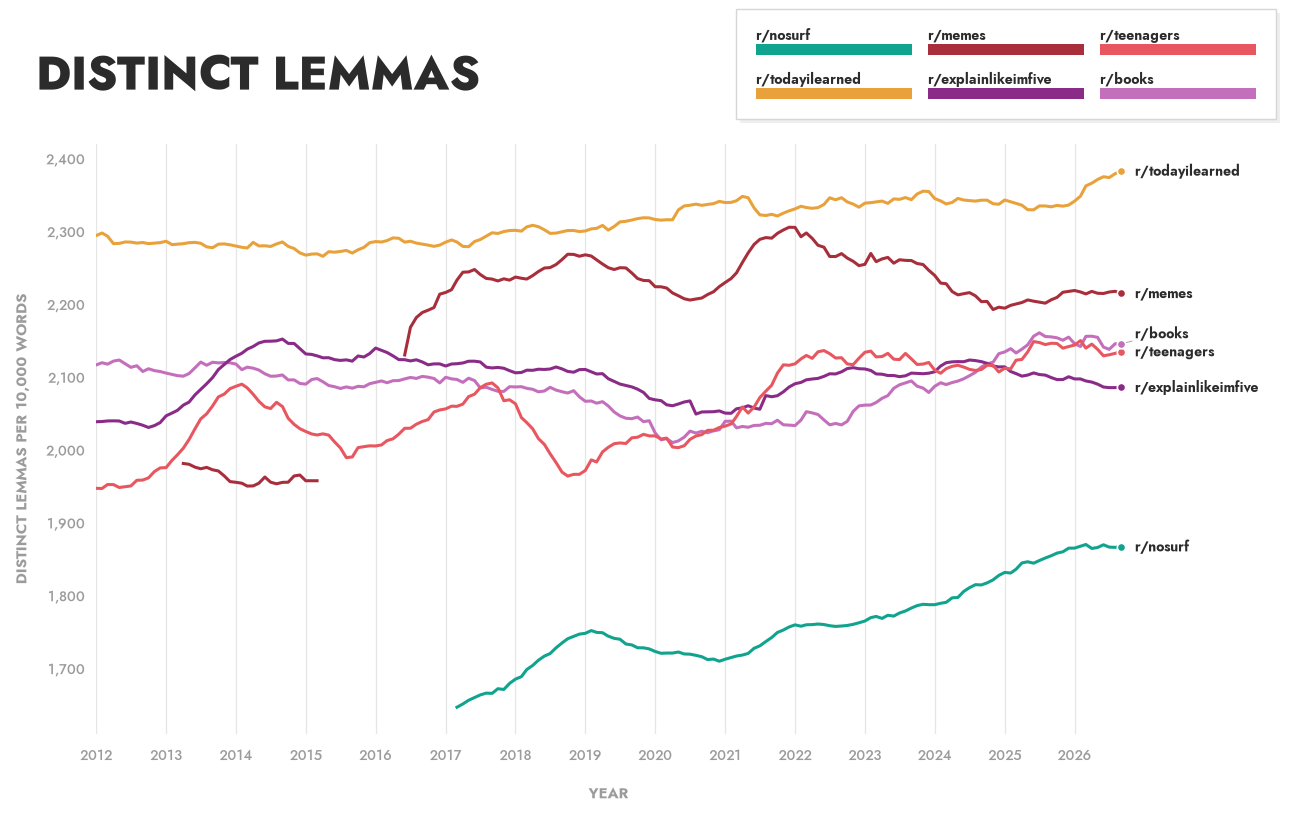

In [124]:
# Needs (once):  pip install spacy  and  python -m spacy download en_core_web_sm
import re
import duckdb
import spacy

CHUNK = 10_000                                     # words per chunk (try 5_000 / 20_000 as a robustness check)
MIN_CHUNKS = 3                                     # a month is shown only if it has at least this many full chunks
BATCHES = 1                                        # use sample batches 1..BATCHES
SEED = "fightclub"                                 # fixes the order of comments -> identical chunks on every computer
BOT_ACCOUNTS = ["AutoModerator", "hive-protect"]   # bots whose names do not end in "bot" (add more if you find them)

DERIVED = Path("data/derived")
DERIVED.mkdir(parents=True, exist_ok=True)
WORDS_FILE = DERIVED / f"comment_words_b{BATCHES}.parquet"   # every comment as a list of cleaned words
LEMMA_FILE = DERIVED / f"lemma_map_b{BATCHES}.parquet"       # word -> normalised word form -> lemma

con = duckdb.connect()
con.sql("SET TimeZone = 'UTC'")
con.sql(f"SET temp_directory = '{(DERIVED / 'duckdb_tmp').as_posix()}'")

# ---- step 1 (one time): clean and split every comment into words -> comment_words.parquet --------------------
if not WORDS_FILE.exists():
    con.sql(rf"""
    COPY (
        SELECT subreddit, strftime(to_timestamp(created_utc), '%Y-%m') AS month, id, author, words
        FROM (
            SELECT *, regexp_extract_all(
                regexp_replace(regexp_replace(regexp_replace(regexp_replace(lower(body),
                    '(^|\n)\s*(&gt;|>)[^\n]*', '\1', 'g'),         -- lines quoted from other comments
                    '\[([^\]]*)\]\([^)]*\)', '\1', 'g'),           -- markdown links: keep only the link text
                    'https?://\S+|www\.\S+|&\w+;', ' ', 'g'),      -- urls and html entities
                    '\b[ru]/\w+', ' ', 'g'),                        -- r/subreddit and u/user mentions
                '[a-z]+(?:''[a-z]+)*') AS words                     -- words: letters, inner apostrophes (don't)
            FROM read_parquet('{(DATA / "comments").as_posix()}/**/*.parquet', hive_partitioning = false)
            WHERE batch <= {BATCHES}
              AND body NOT IN ('[deleted]', '[removed]')
              AND author NOT IN ({', '.join(repr(a) for a in BOT_ACCOUNTS)}) AND lower(author) NOT LIKE '%bot'
              AND coalesce(distinguished, '') <> 'moderator'
              AND body NOT ILIKE '%i am a bot%' AND body NOT ILIKE '%performed automatically%'  -- bot footers
        )
        WHERE len(words) > 0
          -- spam: long comments that repeat the same few words (e.g. one word typed 1,810 times)
          AND NOT (len(words) >= 30 AND len(list_distinct(words)) < 0.2 * len(words))
        -- the same text posted again by the same author in the same month counts only once
        QUALIFY row_number() OVER (PARTITION BY subreddit, month, author, md5(array_to_string(words, ' '))
                                   ORDER BY id) = 1
    ) TO '{WORDS_FILE.as_posix()}' (FORMAT parquet, COMPRESSION zstd)
    """)

# ---- step 2 (one time): lemma of every distinct word -> lemma_map.parquet ------------------------------------
if not LEMMA_FILE.exists():
    forms = con.sql(f"""SELECT form, count(*) AS n
                        FROM (SELECT unnest(words) AS form FROM '{WORDS_FILE.as_posix()}') GROUP BY form""").df()
    stretched = re.compile(r"(.)\1{2,}")
    forms["norm"] = forms["form"].map(lambda w: stretched.sub(r"\1", w))       # sooo -> so, lmaooo -> lmao
    counts = forms.groupby("norm")["n"].sum()
    todo = counts[counts >= 2].index.tolist()          # words seen only once (typos, names) keep their own form
    print(f"Lemmatizing {len(todo):,} distinct words - one time, a few minutes ...")
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    lemma = {d.text: (d[0].lemma_.lower() if len(d) == 1 else d.text)        # "don't" stays "don't"
             for d in nlp.pipe(todo, batch_size=5_000)}
    forms["lemma"] = forms["norm"].map(lemma).fillna(forms["norm"])
    forms.to_parquet(LEMMA_FILE, index=False)

UNITS = {"lemmas": "lemma", "word_forms": "norm"}  # what is counted -> column of lemma_map


def vocab_by_month(unit):
    """Distinct `unit` per CHUNK words for every subreddit-month. Each month's comments are put in a fixed
    pseudo-random order and cut into consecutive chunks of CHUNK words; the incomplete last chunk is dropped.
    Saves vocab_<unit>_<CHUNK>_b<BATCHES>_chunks.parquet (one row per chunk) and ..._monthly.parquet (one row
    per month). Results already saved for the same settings are loaded instead of recomputed."""
    chunks_file = DERIVED / f"vocab_{unit}_{CHUNK}_b{BATCHES}_chunks.parquet"
    monthly_file = DERIVED / f"vocab_{unit}_{CHUNK}_b{BATCHES}_monthly.parquet"
    if chunks_file.exists() and monthly_file.exists():
        return pd.read_parquet(chunks_file), pd.read_parquet(monthly_file)

    con.sql(f"CREATE OR REPLACE VIEW words AS SELECT * FROM '{WORDS_FILE.as_posix()}'")
    con.sql(f"CREATE OR REPLACE VIEW lemma_map AS SELECT * FROM '{LEMMA_FILE.as_posix()}'")
    parts = []
    for sub, _ in STREAMS:                            # one subreddit at a time keeps memory low
        parts.append(con.sql(f"""
            WITH shuffled AS (
                SELECT month, words,
                       coalesce(sum(len(words)) OVER (PARTITION BY month ORDER BY md5(id || '{SEED}')
                                ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING), 0) AS start
                FROM words WHERE subreddit = '{sub}'
            ),
            tokens AS (
                SELECT month, start, unnest(range(len(words))) AS i, unnest(words) AS form FROM shuffled
            ),
            full_chunks AS (
                SELECT month, sum(len(words)) // {CHUNK} AS n FROM words WHERE subreddit = '{sub}' GROUP BY month
            )
            SELECT '{sub}' AS subreddit, t.month, (t.start + t.i) // {CHUNK} AS chunk,
                   count(DISTINCT m.{UNITS[unit]}) AS distinct_n
            FROM tokens t JOIN lemma_map m USING (form) JOIN full_chunks f USING (month)
            WHERE (t.start + t.i) // {CHUNK} < f.n
            GROUP BY ALL
        """).df())
    chunks = pd.concat(parts, ignore_index=True).sort_values(["subreddit", "month", "chunk"])

    sizes = con.sql("SELECT subreddit, month, count(*) AS comments, sum(len(words)) AS words FROM words GROUP BY ALL").df()
    stats = (chunks.groupby(["subreddit", "month"])["distinct_n"]
             .agg(chunks="size", mean="mean", sd="std").reset_index())
    monthly = sizes.merge(stats, on=["subreddit", "month"], how="left").fillna({"chunks": 0})
    monthly["chunks"] = monthly["chunks"].astype(int)
    monthly["ci95"] = 1.96 * monthly["sd"] / np.sqrt(monthly["chunks"].where(monthly["chunks"] > 0))
    monthly["shown"] = monthly["chunks"] >= MIN_CHUNKS
    monthly["month"] = pd.to_datetime(monthly["month"])
    monthly = monthly.sort_values(["subreddit", "month"]).reset_index(drop=True)
    chunks.to_parquet(chunks_file, index=False)
    monthly.to_parquet(monthly_file, index=False)
    return chunks, monthly


def end_labels(ax, ends, min_gap_pt=13):
    """Name at the end of every line (coloured dot + dark text); names that would overlap are moved apart."""
    fig = ax.figure
    fig.canvas.draw()
    px = fig.dpi / 72
    colours = dict(STREAMS)
    placed = None
    for disp, s, x, y in sorted((ax.transData.transform((x, y))[1], s, x, y) for s, (x, y) in ends.items()):
        target = disp if placed is None else max(disp, placed + min_gap_pt * px)
        placed = target
        dy = (target - disp) / px
        ax.plot([x], [y], "o", ms=6, color=colours[s], mec="white", mew=1.2, zorder=5, clip_on=False)
        ax.annotate(f"r/{s}", xy=(x, y), xytext=(10, dy), textcoords="offset points", va="center",
                    fontproperties=font("bold", 10), color=INK, annotation_clip=False,
                    arrowprops=dict(arrowstyle="-", color=AXIS_TEXT, lw=0.6, shrinkA=0, shrinkB=3) if abs(dy) > 2 else None)


def vocab_chart(monthly, title, ylabel):
    """All subreddits on one chart, each as a 12-month moving average of its monthly values."""
    fig, ax = base_figure(title, ylabel)
    W, H = fig.get_size_inches()
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0, pos.width - 1.55 / W, pos.height])      # room for the names at the line ends
    months = pd.date_range("2012-01-01", monthly["month"].max(), freq="MS")
    x = mdates.date2num(months)
    ends = {}
    for s, c in STREAMS:
        m = monthly[(monthly["subreddit"] == s) & monthly["shown"]].set_index("month")["mean"].reindex(months)
        trend = m.rolling(12, center=True, min_periods=6).mean()
        ax.plot(x, trend, color=c, linewidth=2.2, zorder=3)
        if trend.notna().any():
            last = trend.last_valid_index()
            ends[s] = (mdates.date2num(last), trend[last])
    style_axes(ax, x, months)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    style_y_labels(ax)
    end_labels(ax, ends)
    plt.show()


lemma_chunks, lemma_monthly = vocab_by_month("lemmas")
print(f"{len(lemma_chunks):,} chunks of {CHUNK:,} words; {lemma_monthly['shown'].sum()} of {len(lemma_monthly)} "
      f"subreddit-months have at least {MIN_CHUNKS} chunks and are shown.")
vocab_chart(lemma_monthly, "DISTINCT LEMMAS", f"DISTINCT LEMMAS PER {CHUNK:,} WORDS")

And now the same measure, but for distict word forms per 10,000 word per month per subreddit.

25,949 chunks of 10,000 words; 968 of 1062 subreddit-months have at least 3 chunks and are shown.


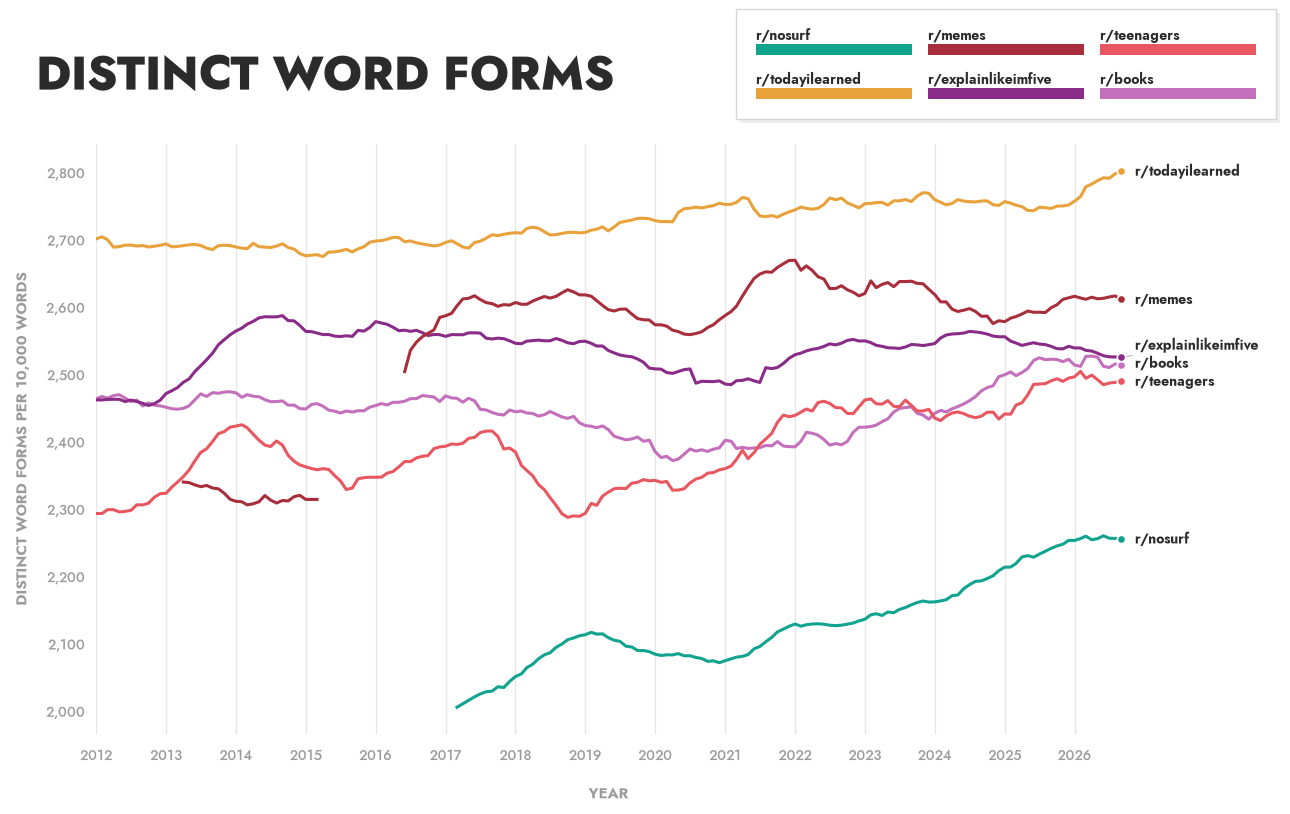

In [125]:
form_chunks, form_monthly = vocab_by_month("word_forms")
print(f"{len(form_chunks):,} chunks of {CHUNK:,} words; {form_monthly['shown'].sum()} of {len(form_monthly)} "
      f"subreddit-months have at least {MIN_CHUNKS} chunks and are shown.")
vocab_chart(form_monthly, "DISTINCT WORD FORMS", f"DISTINCT WORD FORMS PER {CHUNK:,} WORDS")

### 1.3.2. Sentences are getting shorter

### 1.3.3. Lempel-Ziv algorithm

## 1.4. Temporal/Behavioral analysis
Let's analyze conversantions and look into:
1. Thread depth
    1. Thread size
    2. Share or replies vs top-level comments
    3. True depth <!-- download full month for that -->

# 2 H3: Wellbeing is getting worse among doomscrollers
## 2.1 Description of the Analysis Concept
It usually starts harmlessly — just a few minutes of catching up on short videos. But hours later, the pattern is always the same: a subtle shift in mood, a persistent dull headache, and heavy, strained eyes. Experiencing this firsthand made me wonder: *Is this just an isolated personal reaction, or is it a quantifiable, widespread digital ailment?

To answer this, I am diving into the data to uncover the hidden behavioral patterns behind screen time and well-being. Rather than forcing disparate Kaggle datasets into a single lossy table, I am treating each as a distinct chapter in a broader story. Together, they offer a multi-faceted view of how media consumption shapes human health.

## 2.2 Data Landscape
There are 5 such datasets:

1. Social Media Addiction dataset
2. The Dark At The End Of The Tunnel: Doomscrolling On Social Media Newsfeeds
3. Sleep & Doomscrolling Habits Dataset
4. Social Media and Mental Health
5. Student Social Media & Mental Health

## 2.3 Datasets Analysis


In [126]:
from pathlib import Path
import pandas as pd
from IPython.display import display

In [127]:
folder_path = Path("data")

files = [
    "sleep_doomscrolling_habits_clean.csv",
    "smmh_clean.csv",
    "student_sm_clean.csv",
    "Social_Media_Addiction.csv"
]

<!--
for file_name in files:
    file_path = folder_path / file_name

    if file_path.exists():
        df = pd.read_csv(file_path)

        print(f"File: {file_name}")
        print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
        print("\nColumns and Data Types:")
        print(df.dtypes)
        print("\nSample rows:")
        display(df.sample(2))
    else:
        print(f"File not found: {file_path}")
-->

## 2.4 The Conceptual Framework
To synthesize these varied dimensions, I will structure the data analysis around four core well-being clusters:

* *Sleep & Circadian Rhythms:* Mapping the impact of late-night scrolling on sleep quality and sleep delay.
* *Mental Health & Affect:* Tracking mood shifts, anxiety levels, and psychological strain.
* *Addiction & Doomscrolling Behavior:* Quantifying screen time intensity, loss of agency, and compulsion loops.
* *Physical & Cognitive Well-being:* Measuring direct physical symptoms like eye strain, headaches, and cognitive fatigue.

### 2.4.1 Sleep & Circadian Rhythms
  > *Picture this:* You return home exhausted after a long day with zero energy left to do anything productive. Turning to your phone for a quick scroll through lighthearted reels feels like the easiest way to decompress. But before you know it, hours pass, falling asleep becomes surprisingly difficult, your sleep is fragmented with frequent night awakenings, and you wake up feeling completely drained. 
  > 
  > It feels like a perfect vicious cycle: exhaustion drives late-night scrolling, which destroys sleep, leading to even greater fatigue the next day. But are short-form videos truly the root cause of this poor sleep quality?

*- The relationship between the amount of time spent watching videos before bed and the time it takes to fall asleep

In [128]:
import numpy as np
import os
data_dir = "data"

In [129]:
df_doom = pd.read_csv(os.path.join(data_dir, 'sleep_doomscrolling_habits_clean.csv'))
df_doom_video = df_doom[df_doom['bedtime_routine_type'] == 'Watching Videos'].copy()
df_doom_video['bedtime_screen_min'] = df_doom_video['bedtime_screen_time_minutes'].astype(float)

# Remove outliers (respondents with a viewing time of >= 165 minutes)
df_doom_video = df_doom_video[df_doom_video['bedtime_screen_min'] < 165].copy()

# Min-Max Normalization Function [0, 1]
def min_max_norm(series):
    return (series - series.min()) / (series.max() - series.min())

In [130]:
# Normalization of three performance indicators

# Bedtime ( sleep_latency_minutes )
df_doom_video['norm_latency'] = min_max_norm(df_doom_video['sleep_latency_minutes'])

# Sleep Quality ( sleep_quality_score )
df_doom_video['norm_quality'] = min_max_norm(df_doom_video['sleep_quality_score'])

# Level of sleep problems / fatigue ( daytime_fatigue_score або sleep_issues )
df_doom_video['norm_issues'] = min_max_norm(df_doom_video['daytime_fatigue_score'])

In [131]:
max_time = df_doom_video['bedtime_screen_min'].max()
bins = np.arange(0, max_time + 30, 30)
labels = [f"{int(b)}-{int(b+30)}" for b in bins[:-1]]

df_doom_video['screen_time_bin'] = pd.cut(
    df_doom_video['bedtime_screen_min'], 
    bins=bins, 
    labels=labels, 
    right=False
)

In [132]:
df_graph_data = df_doom_video.groupby('screen_time_bin', observed=False).agg(
    avg_screen_time_min=('bedtime_screen_min', 'mean'),
    norm_sleep_latency=('norm_latency', 'mean'),
    norm_sleep_quality=('norm_quality', 'mean'),
    norm_sleep_issues=('norm_issues', 'mean')
).reset_index().dropna()

In [133]:
display(df_graph_data.head())

,screen_time_bin,avg_screen_time_min,norm_sleep_latency,norm_sleep_quality,norm_sleep_issues
0,0-30,18.901961,0.216460,1.000000,0.377451
1,30-60,44.975904,0.296132,0.959839,0.498494
2,60-90,72.677419,0.440153,0.924731,0.508065
3,90-120,99.800000,0.585965,0.911111,0.508333
4,120-150,122.000000,0.736842,0.666667,0.500000


#### Visualisation

In [134]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [135]:
font_dir = "fonts"

bold_font_path = os.path.join(font_dir, "Jost-Bold.ttf")
medium_font_path = os.path.join(font_dir, "Jost-Medium.ttf")

if os.path.exists(bold_font_path) and os.path.exists(medium_font_path):
    font_title = fm.FontProperties(fname=bold_font_path, size=14)
    font_label = fm.FontProperties(fname=medium_font_path, size=11)
    font_ticks = fm.FontProperties(fname=medium_font_path, size=9)
    print("Fonts loaded successfully from:", font_dir)
else:
    font_title = fm.FontProperties(family='sans-serif', size=14, weight='bold')
    font_label = fm.FontProperties(family='sans-serif', size=11)
    font_ticks = fm.FontProperties(family='sans-serif', size=9)
    print("Warning: Jost fonts not found in directory. Using fallback system fonts.")

df = df_graph_data.astype({'screen_time_bin': str})

colors = {
    'latency': '#E06C63',  # Coral Red
    'quality': '#3AAFA9',  # Teal Green
    'issues':  '#E0A946'   # Ochre Yellow
}

Fonts loaded successfully from: fonts


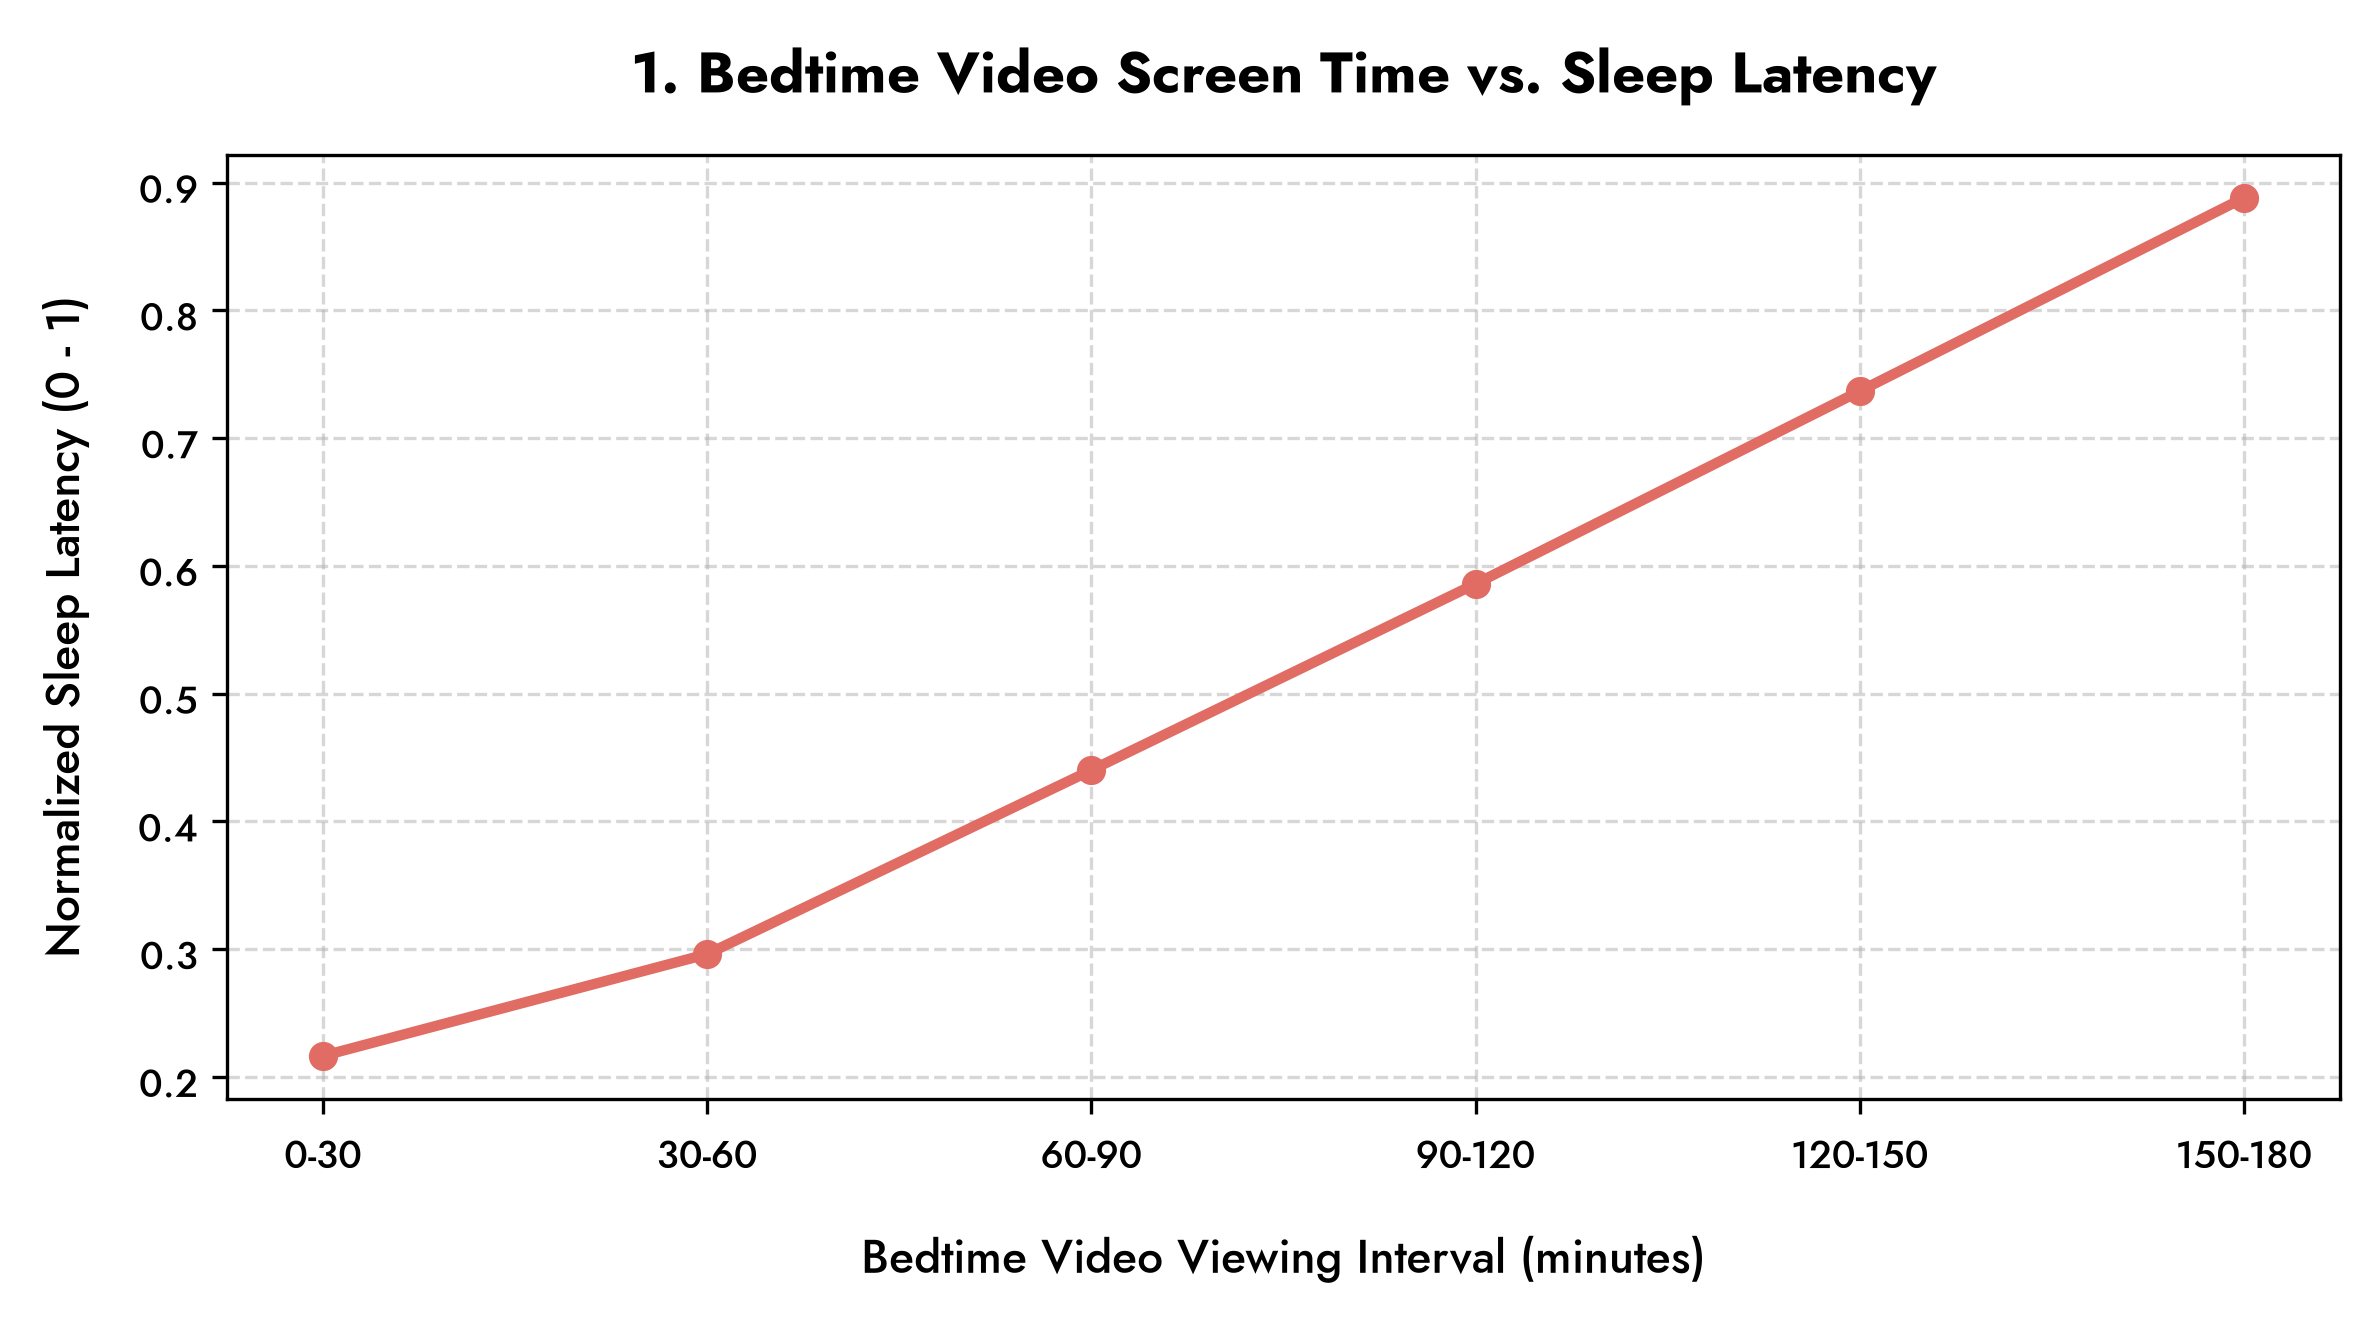

In [136]:
# Graph 1: Sleep Latency

plt.figure(figsize=(8, 4.5), dpi=300)
plt.plot(df['screen_time_bin'], df['norm_sleep_latency'], marker='o', color=colors['latency'], linewidth=2.5)
plt.title("1. Bedtime Video Screen Time vs. Sleep Latency", fontproperties=font_title, pad=15)
plt.xlabel("Bedtime Video Viewing Interval (minutes)", fontproperties=font_label, labelpad=10)
plt.ylabel("Normalized Sleep Latency (0 - 1)", fontproperties=font_label, labelpad=10)
plt.xticks(fontproperties=font_ticks)
plt.yticks(fontproperties=font_ticks)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

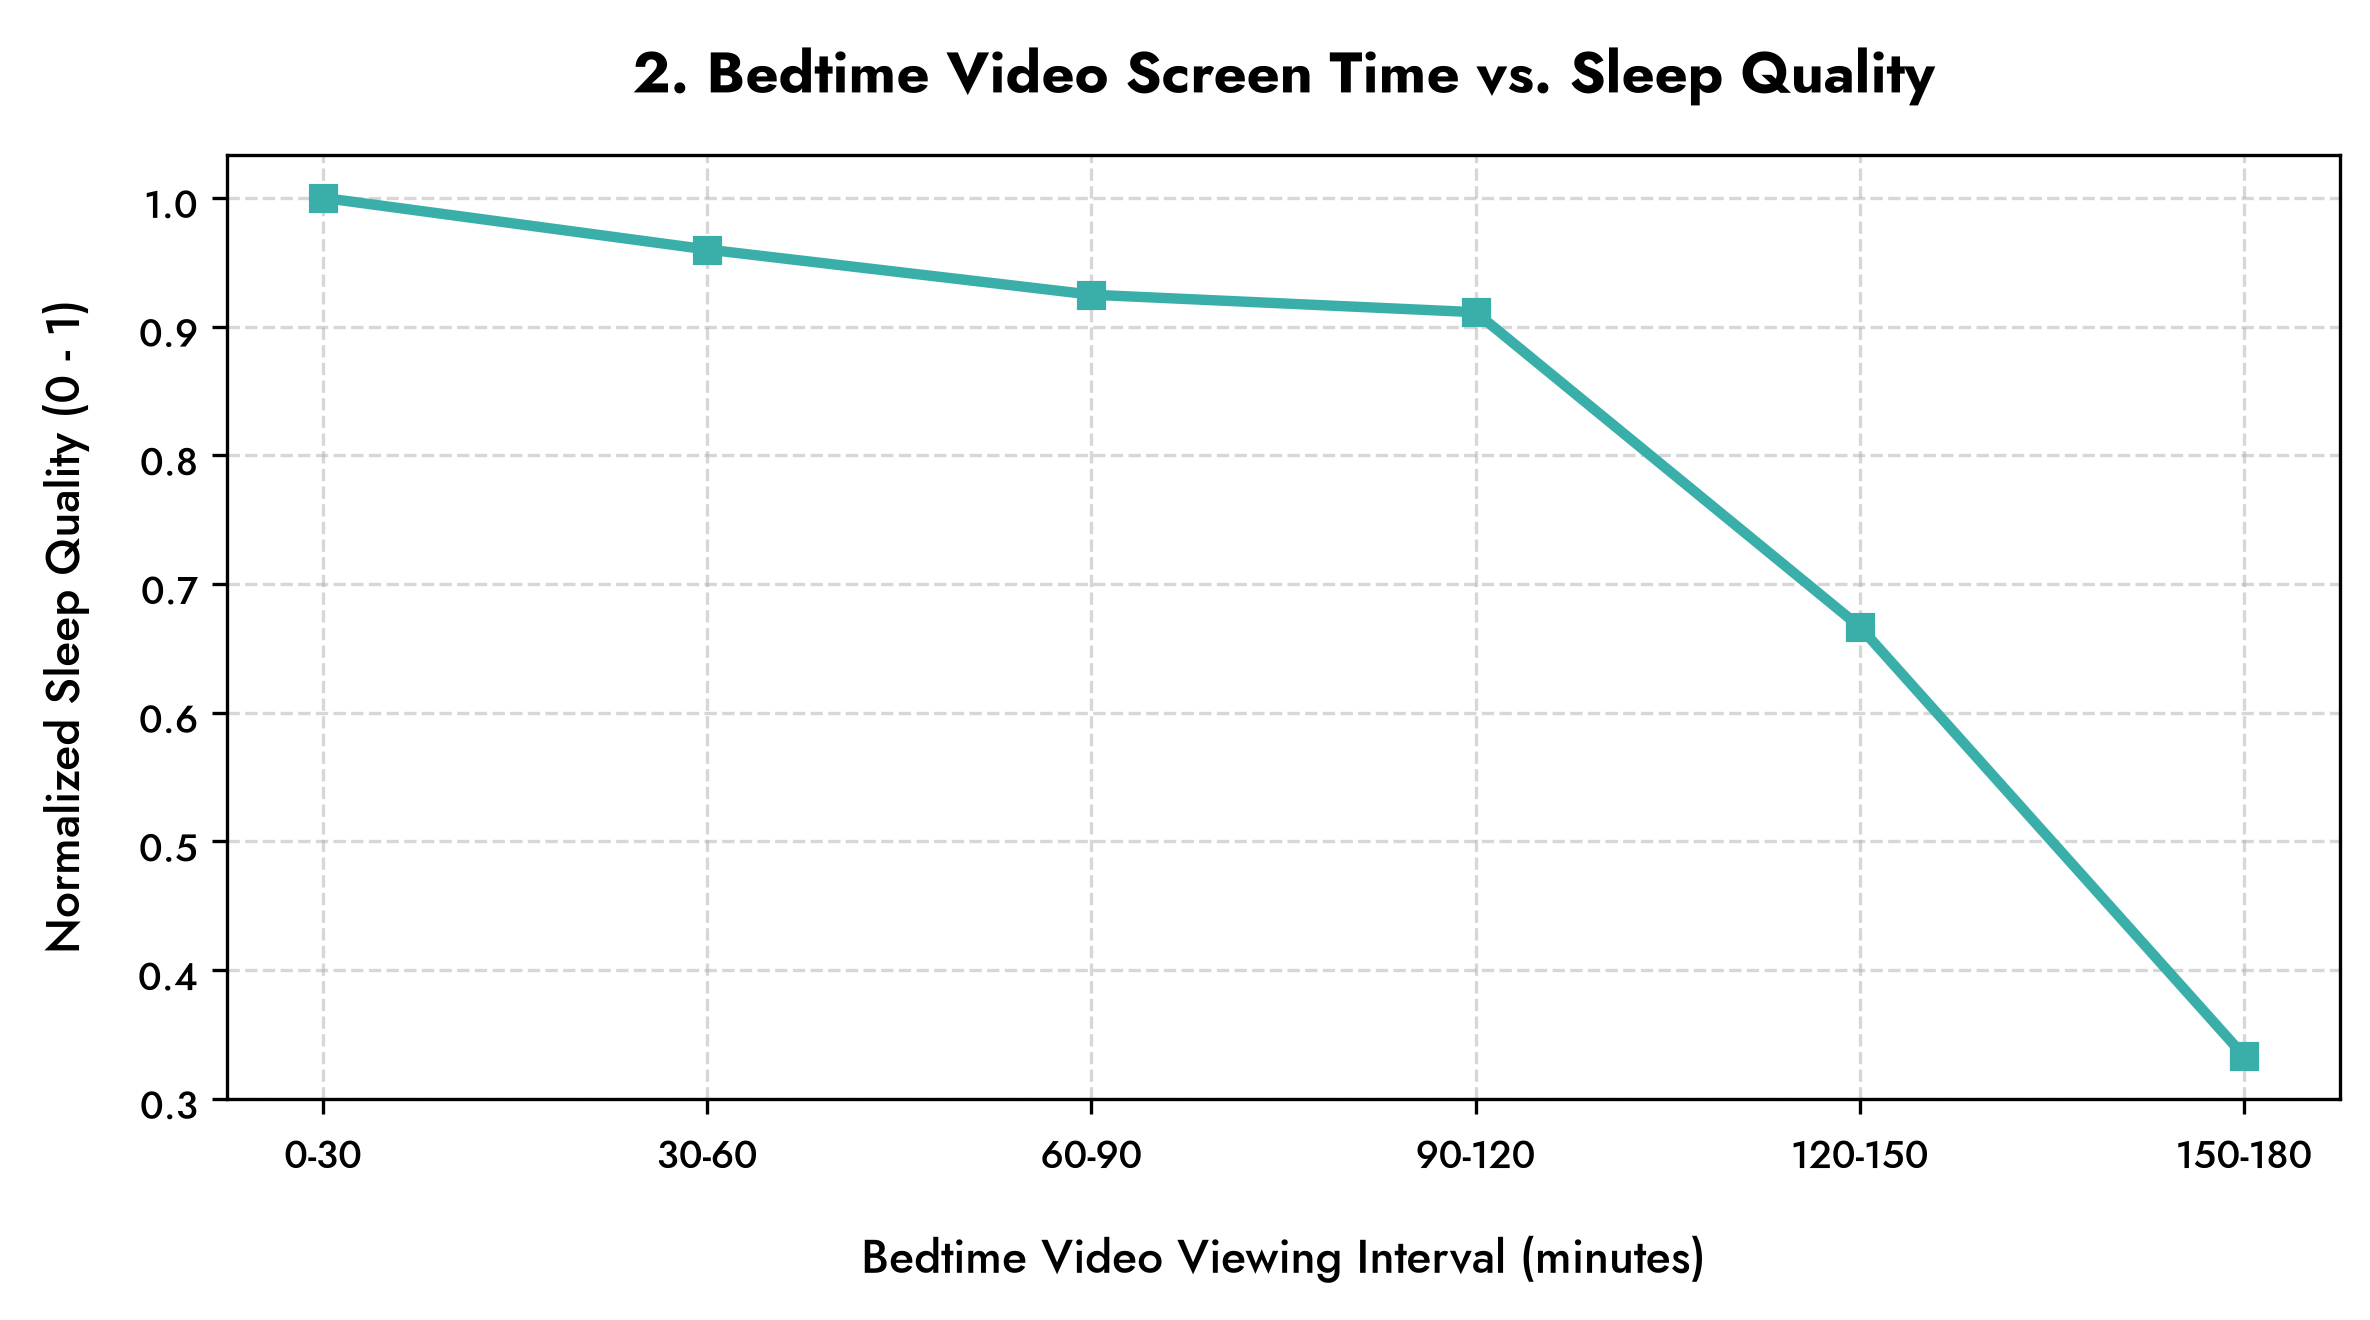

In [137]:
plt.figure(figsize=(8, 4.5), dpi=300)
plt.plot(df['screen_time_bin'], df['norm_sleep_quality'], marker='s', color=colors['quality'], linewidth=2.5)
plt.title("2. Bedtime Video Screen Time vs. Sleep Quality", fontproperties=font_title, pad=15)
plt.xlabel("Bedtime Video Viewing Interval (minutes)", fontproperties=font_label, labelpad=10)
plt.ylabel("Normalized Sleep Quality (0 - 1)", fontproperties=font_label, labelpad=10)
plt.xticks(fontproperties=font_ticks)
plt.yticks(fontproperties=font_ticks)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

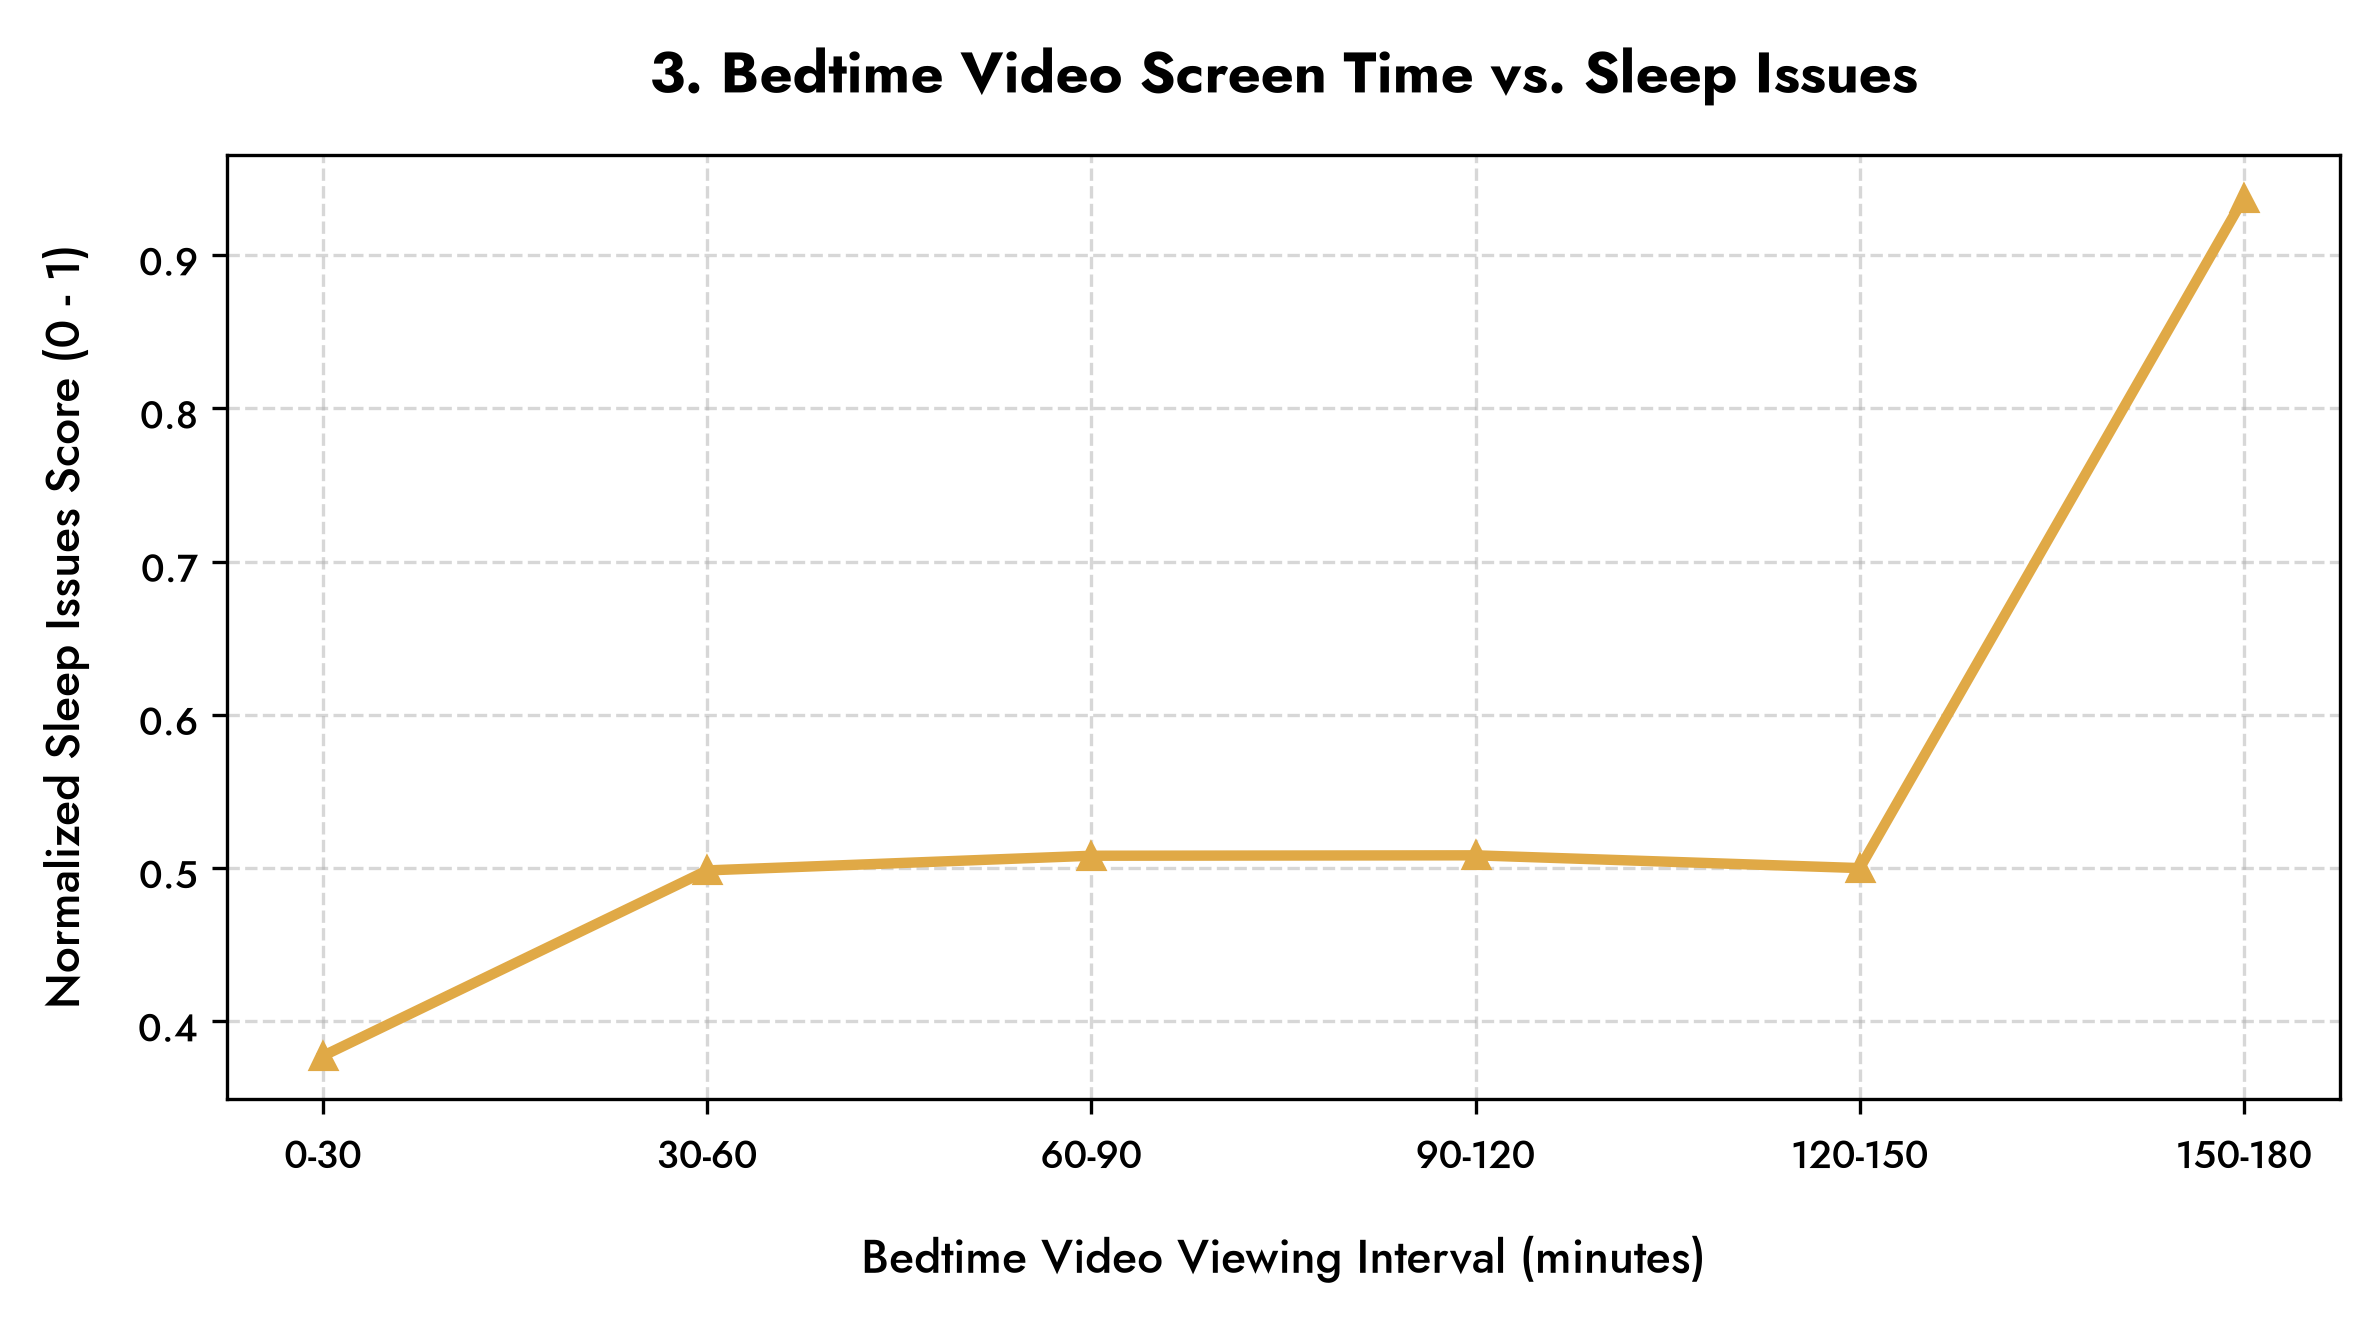

In [138]:
plt.figure(figsize=(8, 4.5), dpi=300)
plt.plot(df['screen_time_bin'], df['norm_sleep_issues'], marker='^', color=colors['issues'], linewidth=2.5)
plt.title("3. Bedtime Video Screen Time vs. Sleep Issues", fontproperties=font_title, pad=15)
plt.xlabel("Bedtime Video Viewing Interval (minutes)", fontproperties=font_label, labelpad=10)
plt.ylabel("Normalized Sleep Issues Score (0 - 1)", fontproperties=font_label, labelpad=10)
plt.xticks(fontproperties=font_ticks)
plt.yticks(fontproperties=font_ticks)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

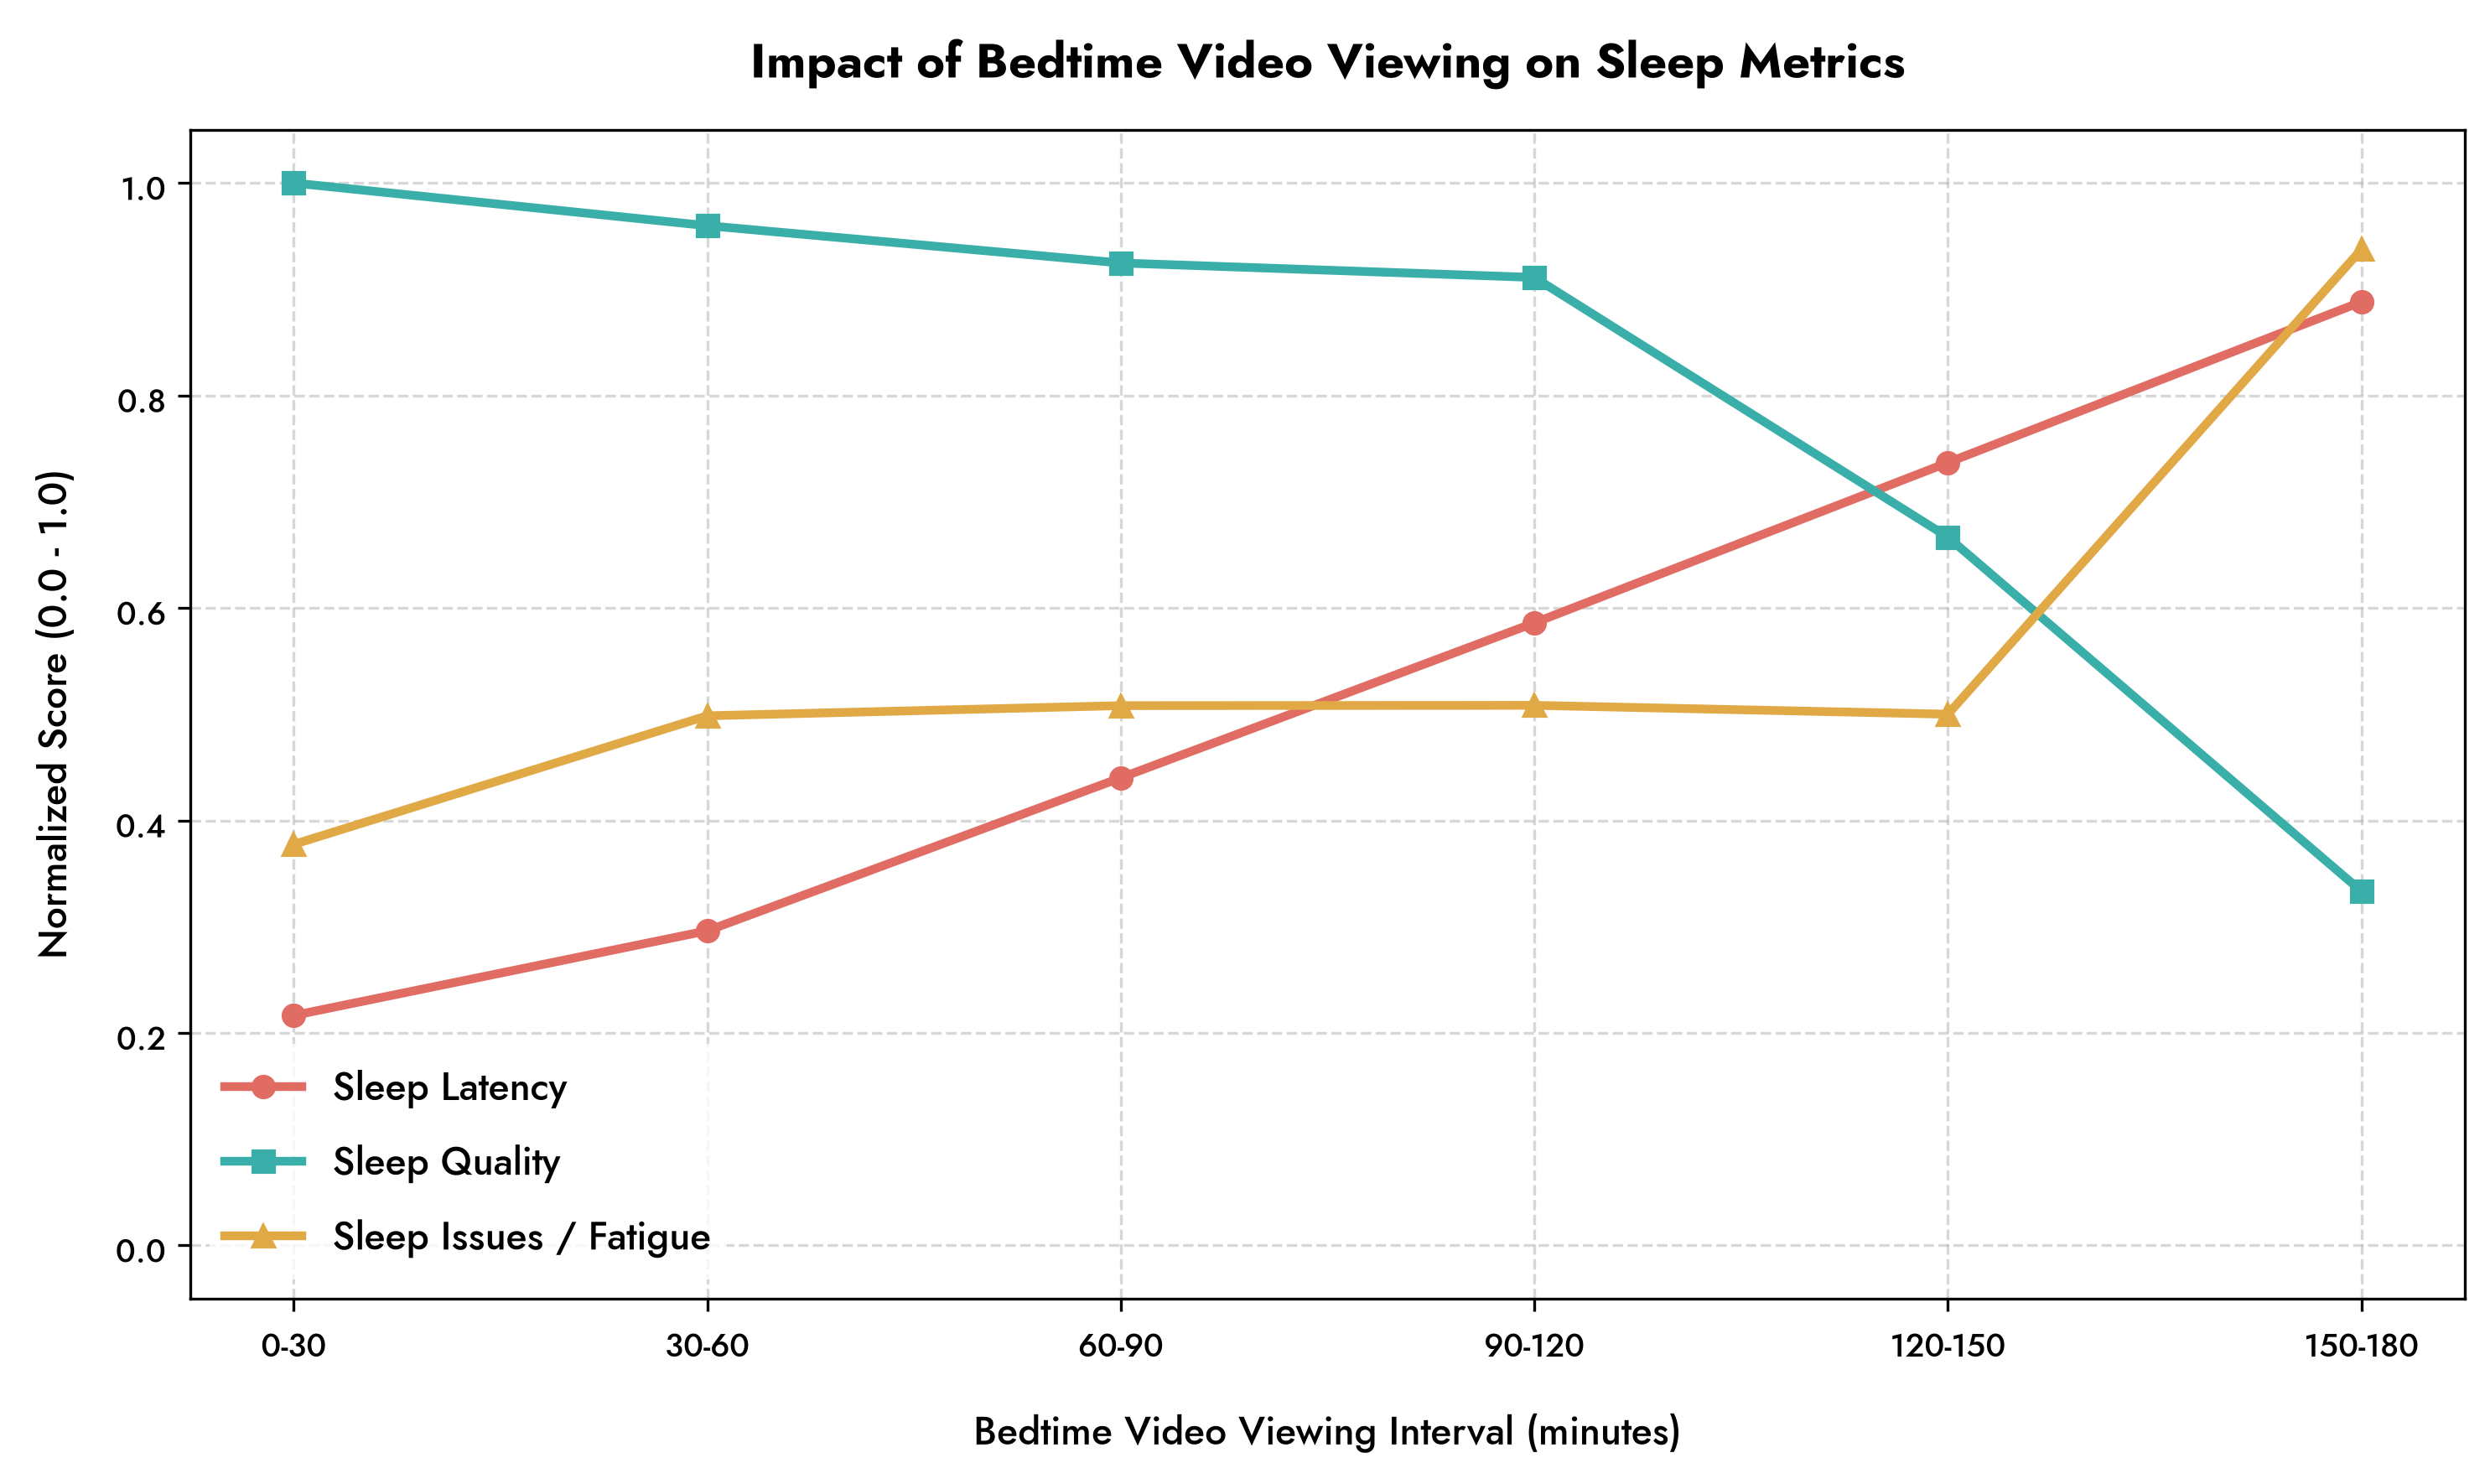

In [139]:
plt.figure(figsize=(10, 6), dpi=300)

plt.plot(df['screen_time_bin'], df['norm_sleep_latency'], marker='o', color=colors['latency'], linewidth=2.5, label='Sleep Latency')
plt.plot(df['screen_time_bin'], df['norm_sleep_quality'], marker='s', color=colors['quality'], linewidth=2.5, label='Sleep Quality')
plt.plot(df['screen_time_bin'], df['norm_sleep_issues'], marker='^', color=colors['issues'], linewidth=2.5, label='Sleep Issues / Fatigue')

plt.title("Impact of Bedtime Video Viewing on Sleep Metrics", fontproperties=font_title, pad=15)
plt.xlabel("Bedtime Video Viewing Interval (minutes)", fontproperties=font_label, labelpad=10)
plt.ylabel("Normalized Score (0.0 - 1.0)", fontproperties=font_label, labelpad=10)
plt.xticks(fontproperties=font_ticks)
plt.yticks(fontproperties=font_ticks)

plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(prop=font_label, frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

Weekly Sleep Debt Statistics by Bedtime Routine:
     bedtime_routine_type      mean  median  count
3  Scrolling Social Media  5.055696    4.20    395
2                 Reading  4.917834    3.80    157
1        No Fixed Routine  4.787179    3.90    156
0   Meditation/Journaling  4.666667    3.95    108
4         Watching Videos  4.588043    3.55    184


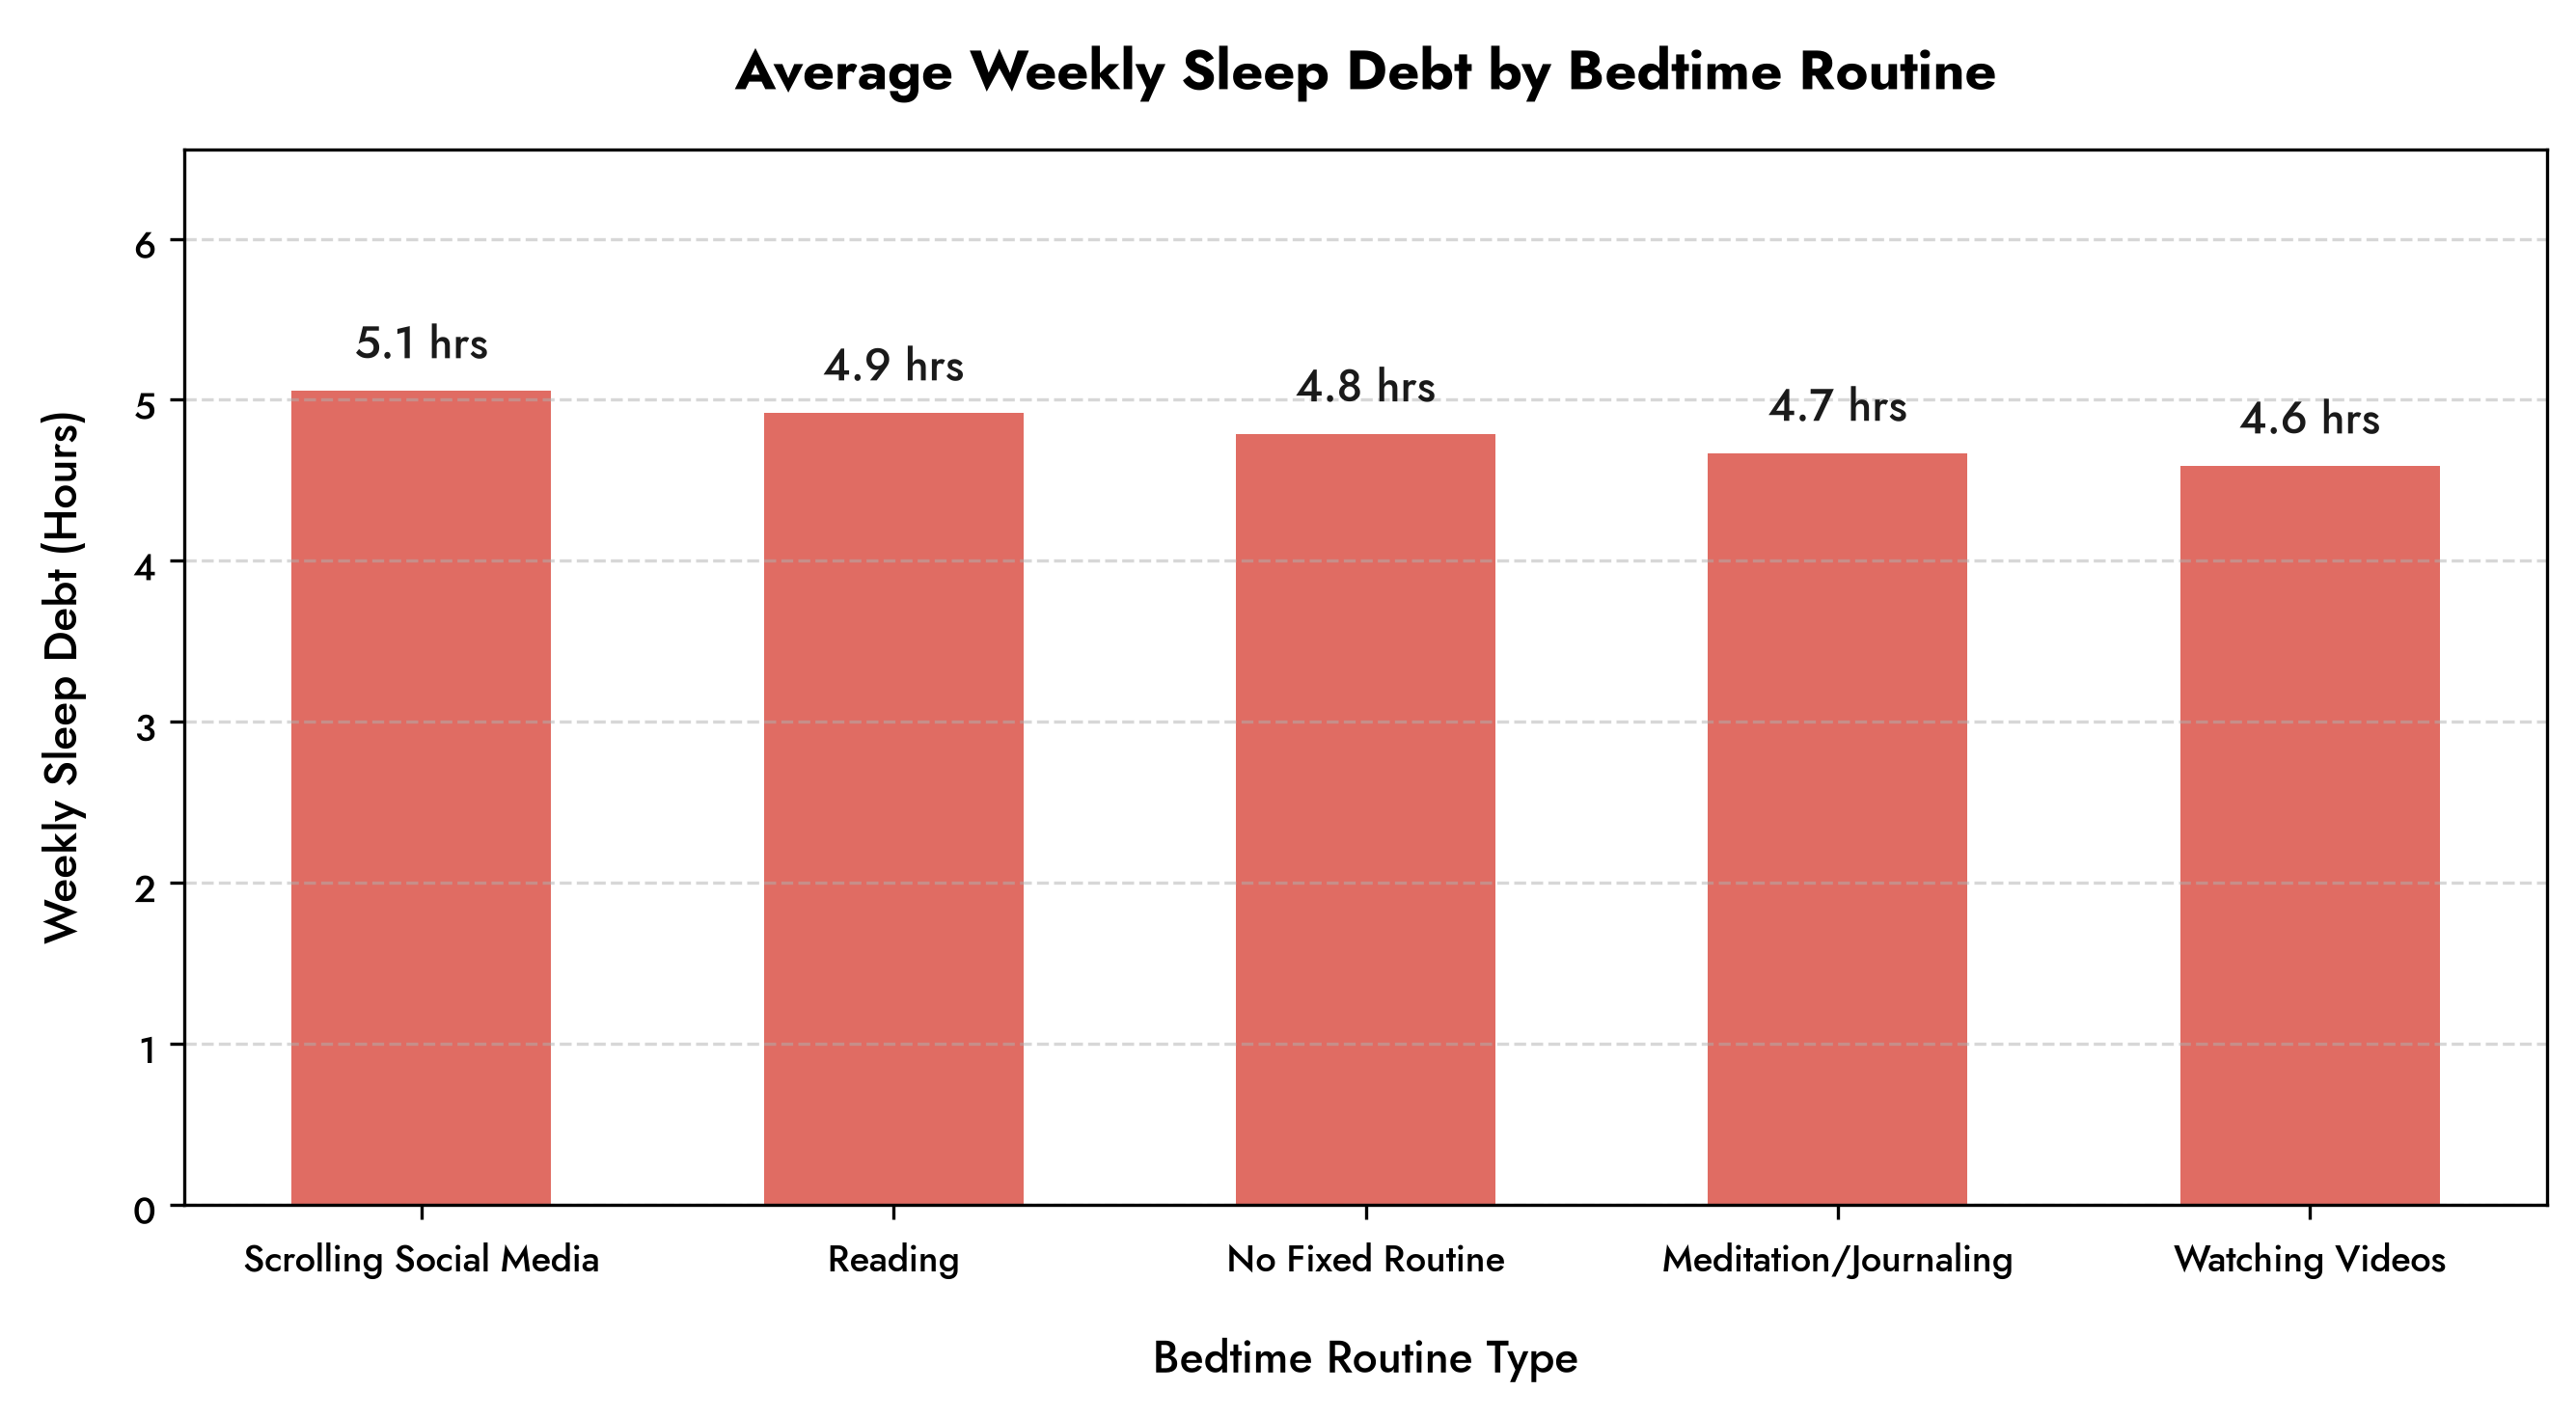

In [140]:
# ==========================================
# STEP 6: WEEKLY SLEEP DEBT BY BEDTIME ROUTINE
# ==========================================

# 1. Aggregate mean weekly sleep debt hours per routine type
debt_stats = df_doom.groupby('bedtime_routine_type')['weekly_sleep_debt_hours'].agg(
    ['mean', 'median', 'count']
).reset_index()

debt_stats.sort_values(by='mean', ascending=False, inplace=True)

print("Weekly Sleep Debt Statistics by Bedtime Routine:")
print(debt_stats)

# 2. Plot Bar Chart
plt.figure(figsize=(9, 5), dpi=300)

bars = plt.bar(
    debt_stats['bedtime_routine_type'], 
    debt_stats['mean'], 
    color=colors['latency'],  # Coral Red (#E06C63)
    edgecolor='none',
    width=0.55
)

# Highlights / Labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + 0.1, 
        f"{yval:.1f} hrs", 
        ha='center', 
        va='bottom', 
        fontproperties=font_label,
        color='#1A1A1A'
    )

plt.title("Average Weekly Sleep Debt by Bedtime Routine", fontproperties=font_title, pad=15)
plt.xlabel("Bedtime Routine Type", fontproperties=font_label, labelpad=10)
plt.ylabel("Weekly Sleep Debt (Hours)", fontproperties=font_label, labelpad=10)

plt.xticks(fontproperties=font_ticks)
plt.yticks(fontproperties=font_ticks)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adjusting Y limits to give room for text labels
plt.ylim(0, debt_stats['mean'].max() + 1.5)

plt.tight_layout()
plt.show()

Weekly Sleep Debt by Screen Time Group:
  screen_time_group  weekly_sleep_debt_hours
0           <30 min                 3.287372
1         30-60 min                 4.258416
2         60-90 min                 6.306736
3           90+ min                 8.757273


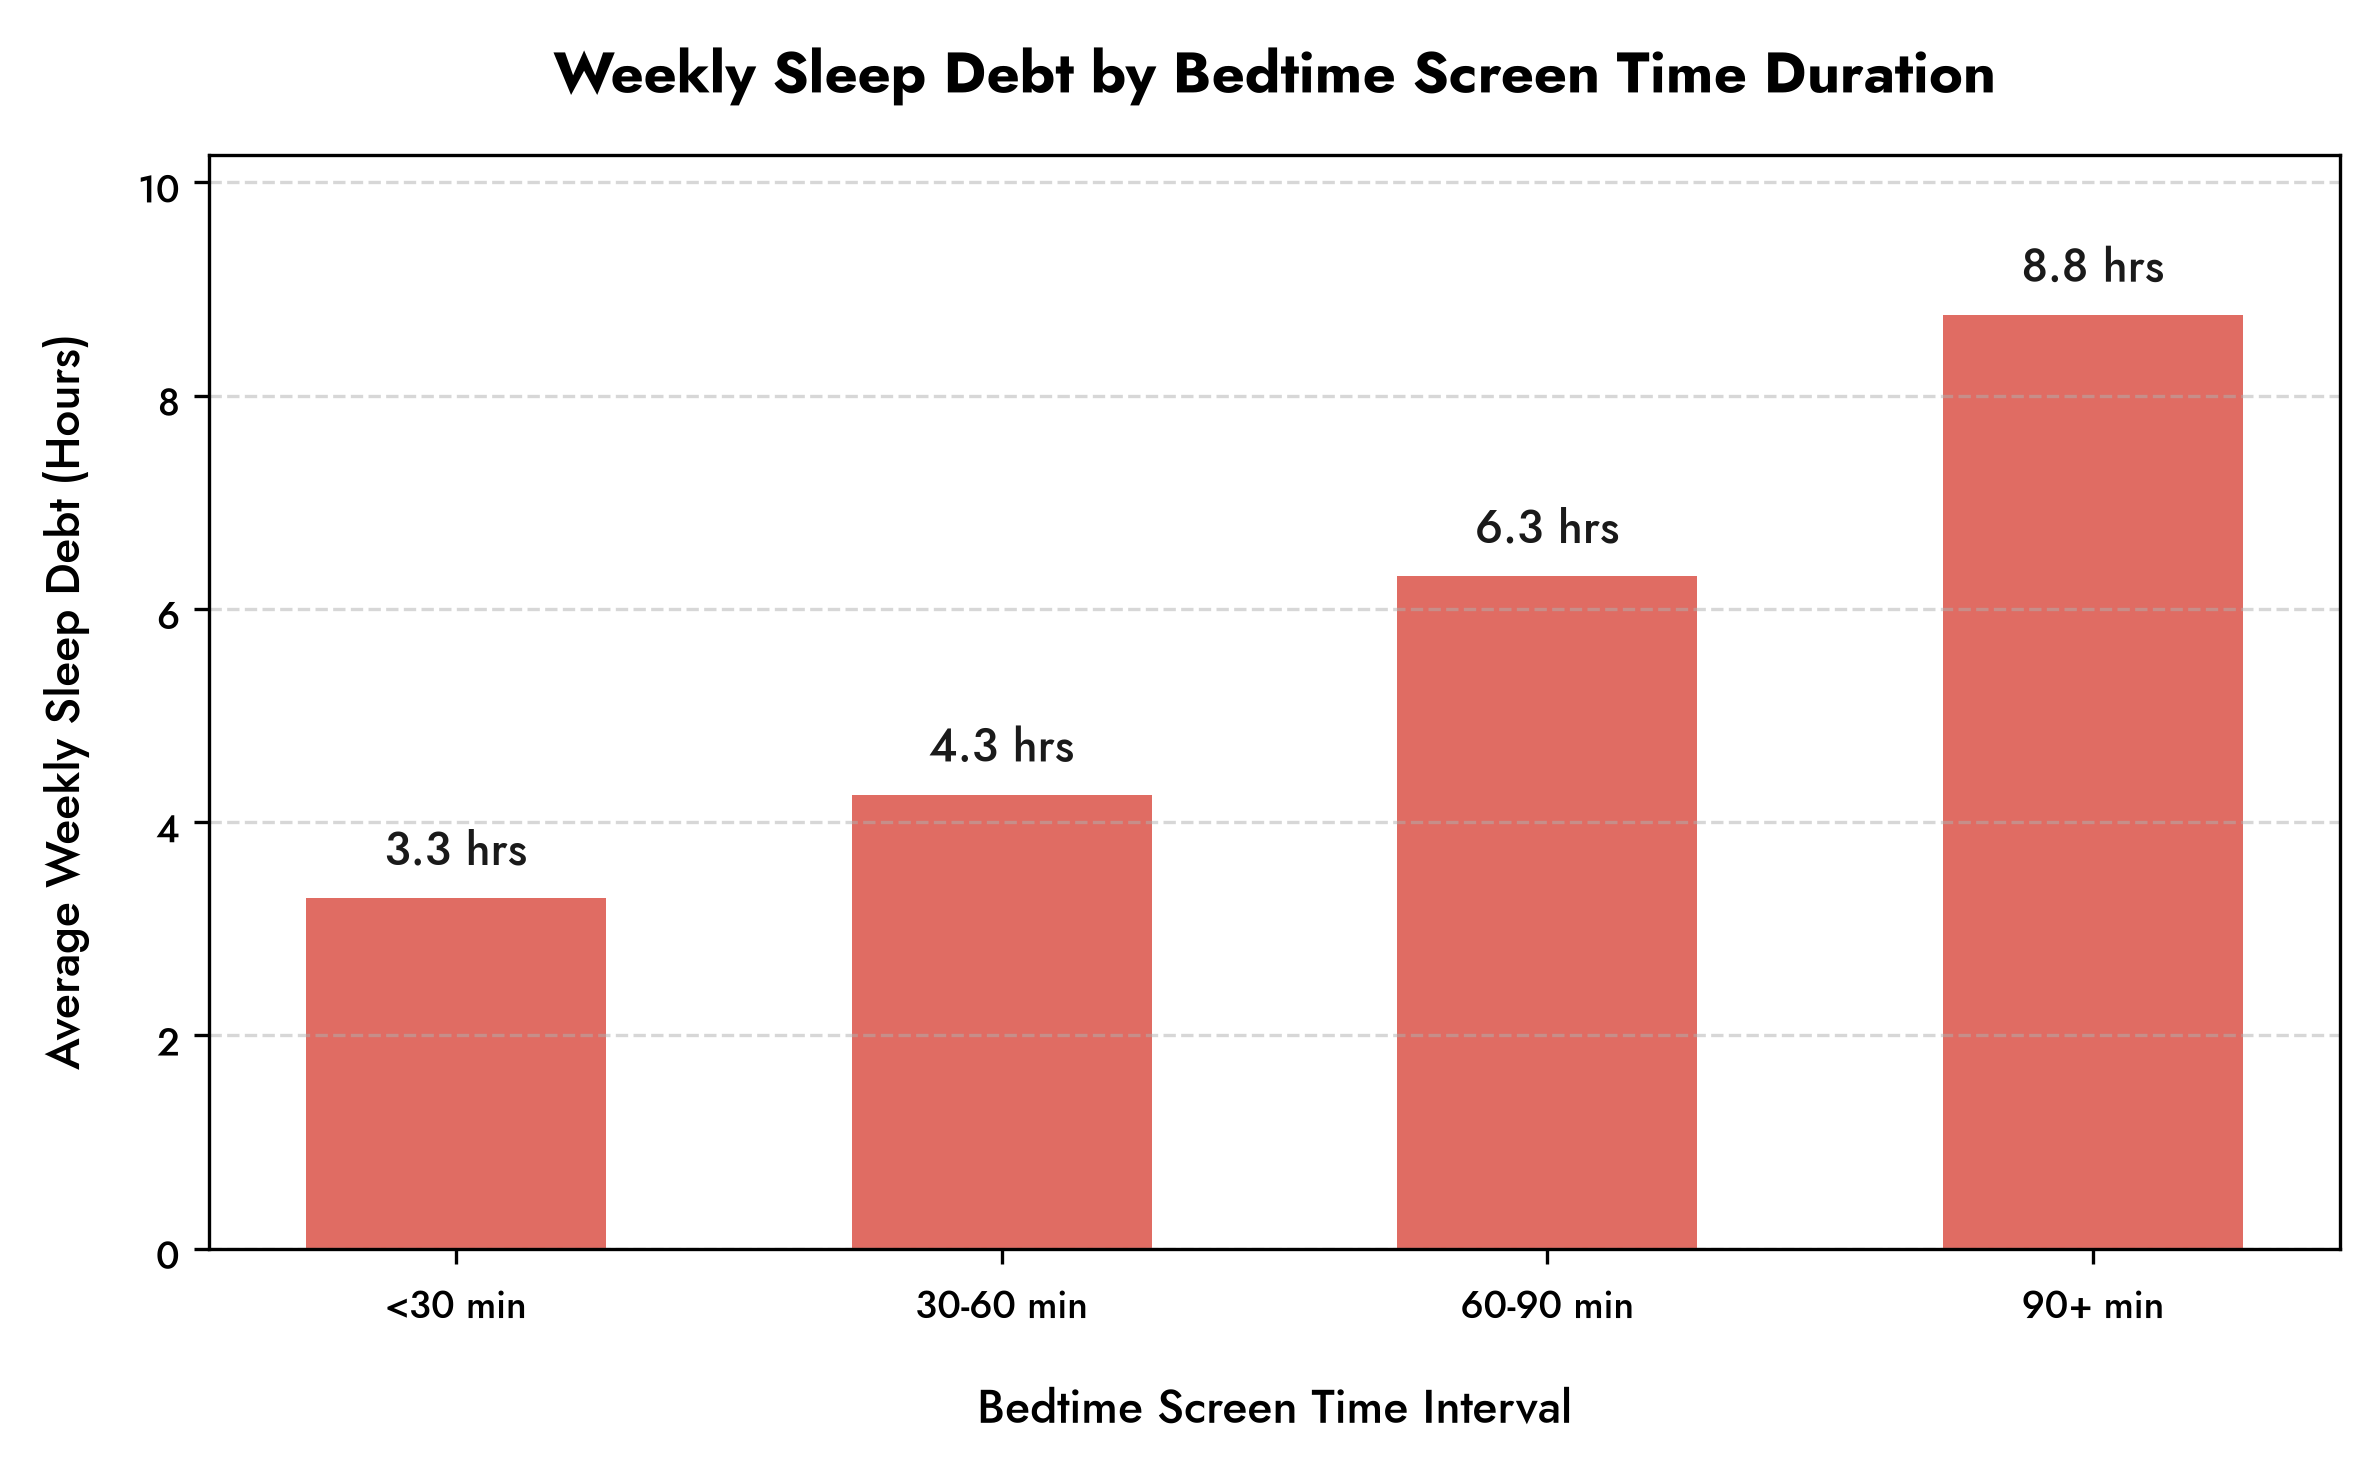

In [141]:
# 1. Define screen time bins
screen_bins = [0, 30, 60, 90, 300]
screen_labels = ['<30 min', '30-60 min', '60-90 min', '90+ min']

df_doom['screen_time_group'] = pd.cut(
    df_doom['bedtime_screen_time_minutes'], 
    bins=screen_bins, 
    labels=screen_labels, 
    right=False
)

# 2. Aggregate mean sleep debt by screen time group
screen_debt_stats = df_doom.groupby('screen_time_group', observed=False)['weekly_sleep_debt_hours'].mean().reset_index()

print("Weekly Sleep Debt by Screen Time Group:")
print(screen_debt_stats)

# 3. Plot Bar Chart
plt.figure(figsize=(8, 5), dpi=300)

bars1 = plt.bar(
    screen_debt_stats['screen_time_group'], 
    screen_debt_stats['weekly_sleep_debt_hours'], 
    color=colors['latency'],  # Coral Red (#E06C63)
    width=0.55
)

# Add values above bars
for bar in bars1:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + 0.15, 
        f"{yval:.1f} hrs", 
        ha='center', 
        va='bottom', 
        fontproperties=font_label,
        color='#1A1A1A'
    )

plt.title("Weekly Sleep Debt by Bedtime Screen Time Duration", fontproperties=font_title, pad=15)
plt.xlabel("Bedtime Screen Time Interval", fontproperties=font_label, labelpad=10)
plt.ylabel("Average Weekly Sleep Debt (Hours)", fontproperties=font_label, labelpad=10)

plt.xticks(fontproperties=font_ticks)
plt.yticks(fontproperties=font_ticks)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, screen_debt_stats['weekly_sleep_debt_hours'].max() + 1.5)

plt.tight_layout()
plt.show()

Doomscroller Comparison Stats:
   doomscroller  sleep_debt  sleep_latency  night_wakeups        group_label
0         False    4.154771      22.854962       1.179389  Non-Doomscrollers
1          True    5.644958      33.415966       1.663866      Doomscrollers


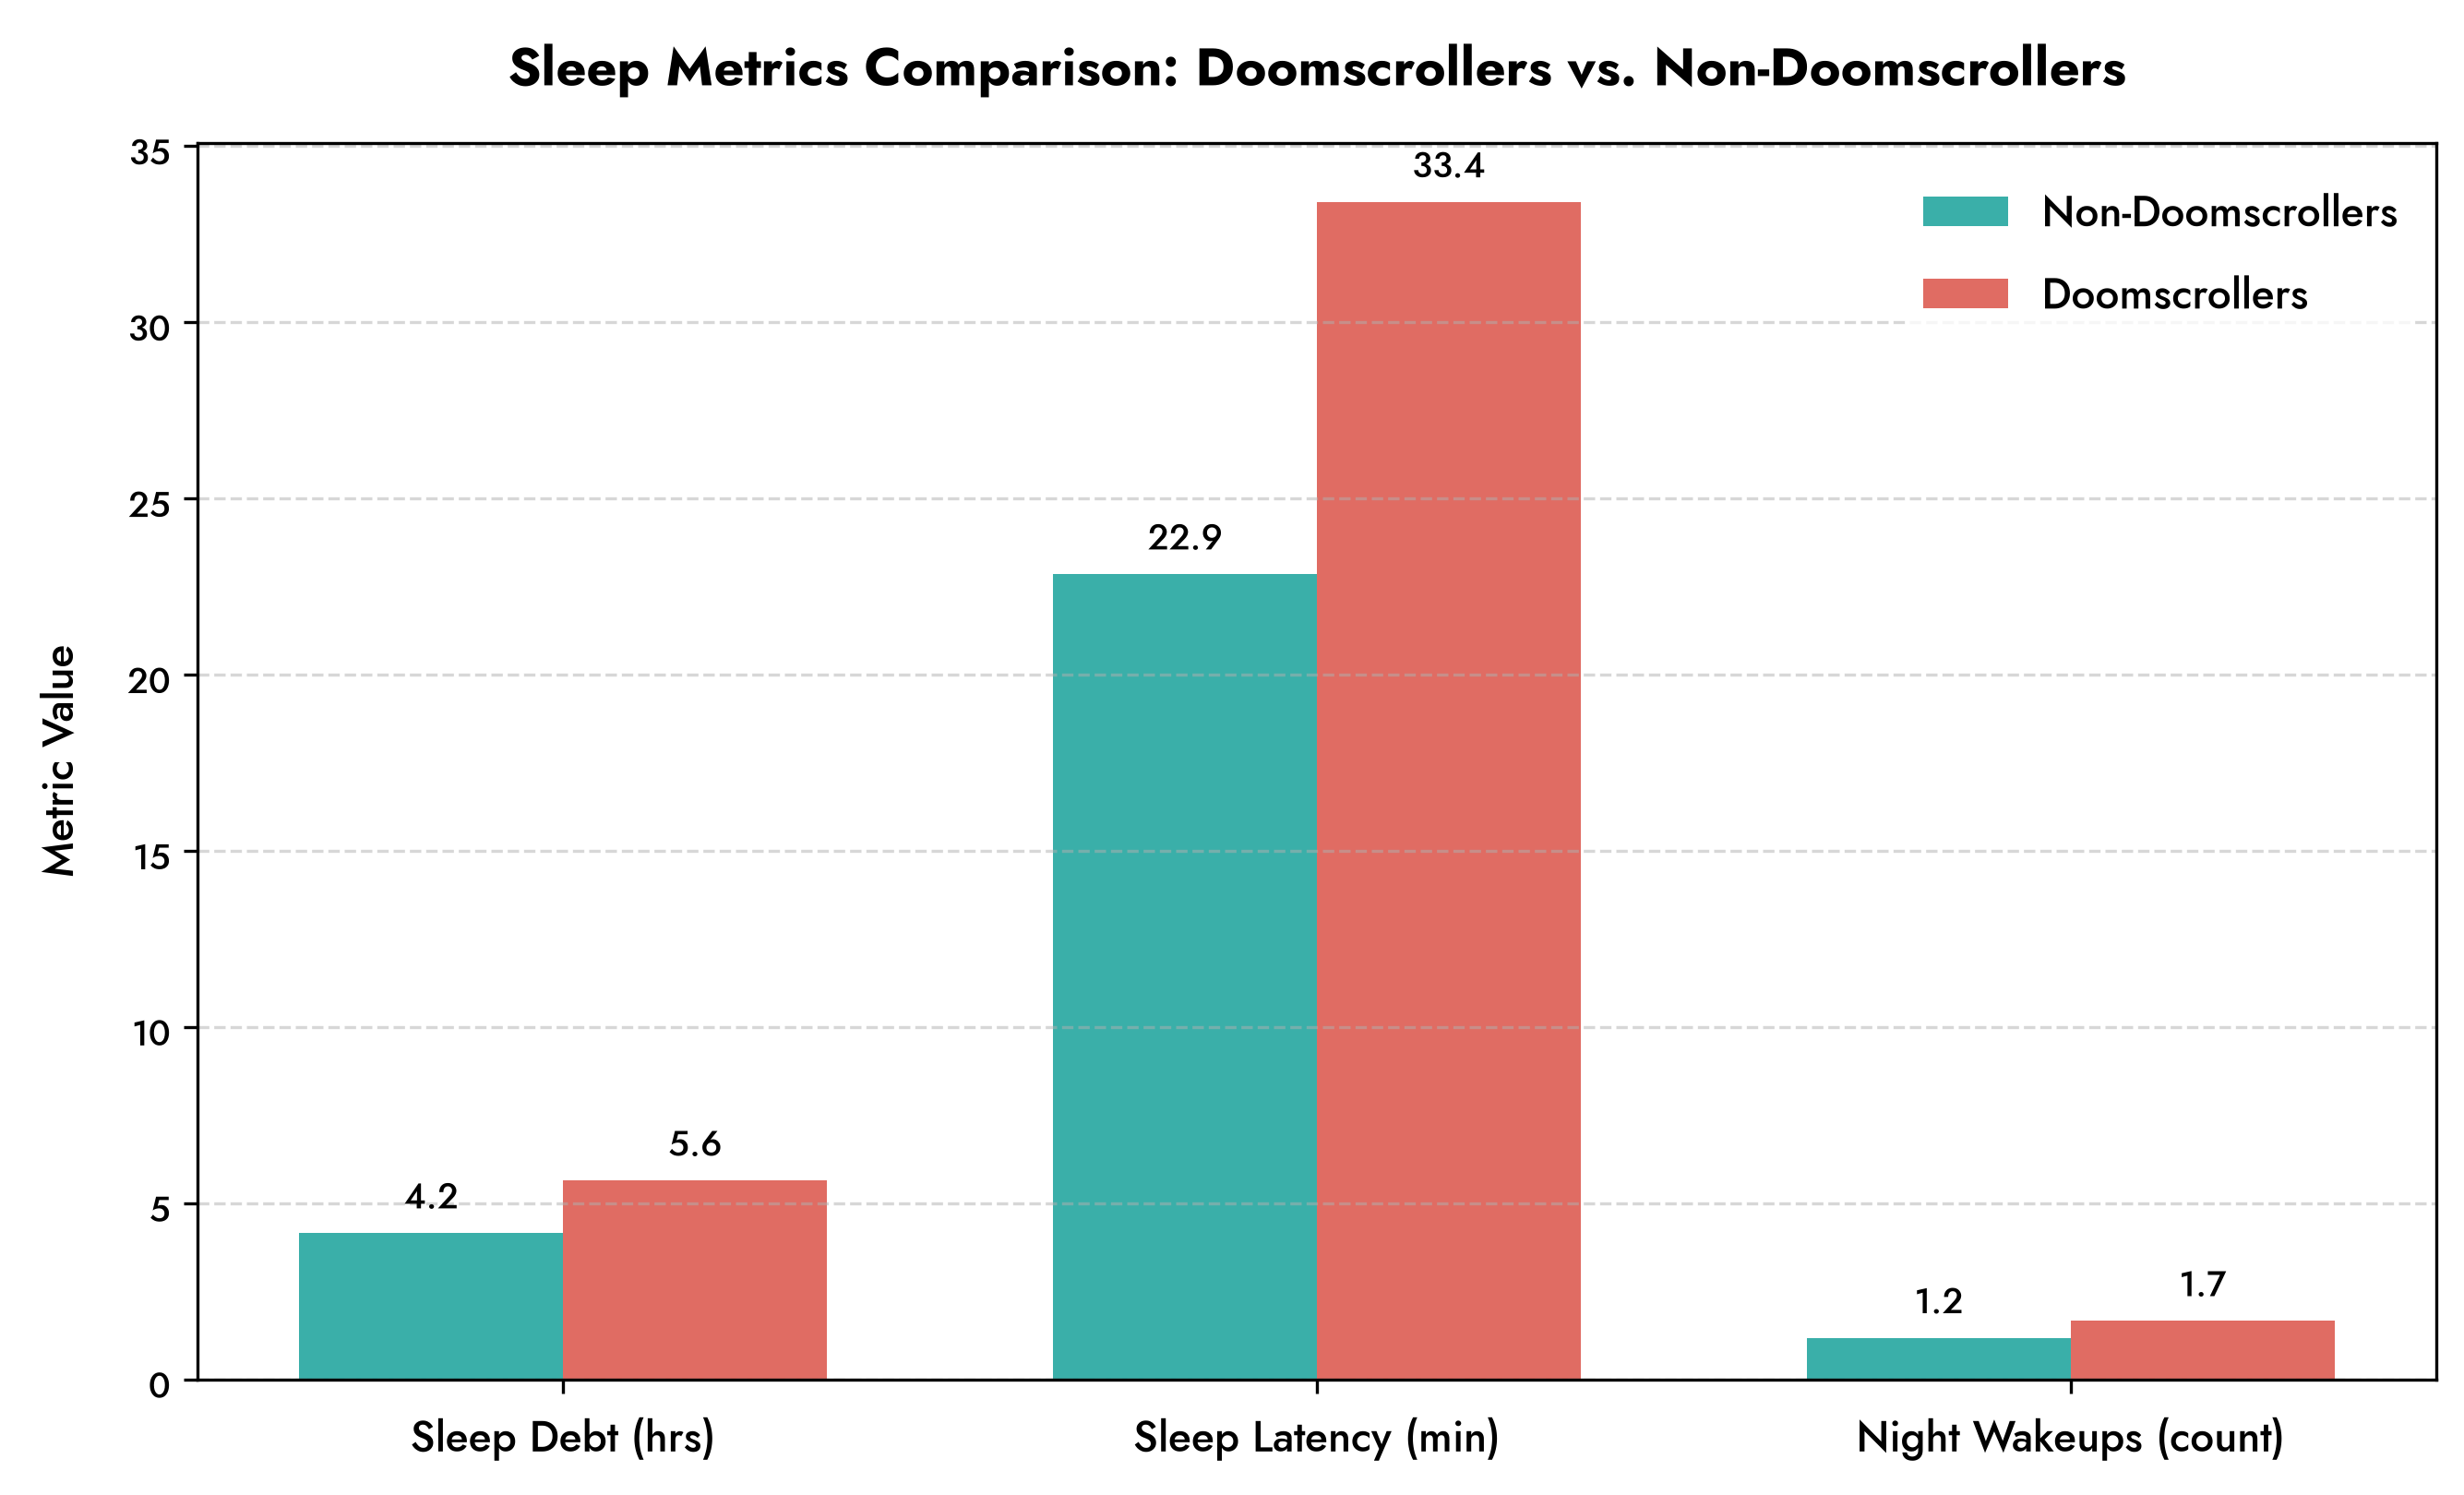

In [142]:
# 1. Aggregate metrics for Doomscrollers vs Non-Doomscrollers
doom_comparison = df_doom.groupby('doomscroller').agg(
    sleep_debt=('weekly_sleep_debt_hours', 'mean'),
    sleep_latency=('sleep_latency_minutes', 'mean'),
    night_wakeups=('number_of_night_wakeups', 'mean')
).reset_index()

doom_comparison['group_label'] = doom_comparison['doomscroller'].map({True: 'Doomscrollers', False: 'Non-Doomscrollers'})

print("Doomscroller Comparison Stats:")
print(doom_comparison)

# 2. Plot Grouped Bar Chart
labels = ['Sleep Debt (hrs)', 'Sleep Latency (min)', 'Night Wakeups (count)']
non_doom_values = [
    doom_comparison.loc[doom_comparison['doomscroller'] == False, 'sleep_debt'].values[0],
    doom_comparison.loc[doom_comparison['doomscroller'] == False, 'sleep_latency'].values[0],
    doom_comparison.loc[doom_comparison['doomscroller'] == False, 'night_wakeups'].values[0]
]

doom_values = [
    doom_comparison.loc[doom_comparison['doomscroller'] == True, 'sleep_debt'].values[0],
    doom_comparison.loc[doom_comparison['doomscroller'] == True, 'sleep_latency'].values[0],
    doom_comparison.loc[doom_comparison['doomscroller'] == True, 'night_wakeups'].values[0]
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5.5), dpi=300)

rects1 = plt.bar(x - width/2, non_doom_values, width, label='Non-Doomscrollers', color=colors['quality'])
rects2 = plt.bar(x + width/2, doom_values, width, label='Doomscrollers', color=colors['latency'])

# Add labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontproperties=font_ticks)

autolabel(rects1)
autolabel(rects2)

plt.title("Sleep Metrics Comparison: Doomscrollers vs. Non-Doomscrollers", fontproperties=font_title, pad=15)
plt.xticks(x, labels, fontproperties=font_label)
plt.yticks(fontproperties=font_ticks)
plt.ylabel("Metric Value", fontproperties=font_label, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(prop=font_label, frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

# 3 H4: Crises intensify doomscrolling and negativity
## 3.1 Overview
This section will cover topic of H4 "crises intensify doomscrolling and negativity".

What we currently have:

### 3.1.1 Events
Four major events fall inside the data range(brainrot era). We checked their dates on 2026-10-04 against news and reference sources.

1. The WHO declares COVID-19 a pandemic (11 March 2020)
2. The full-scale Russian invasion of Ukraine (24 February 2022)
3. The Hamas attack on Israel that starts the Gaza war (7 October 2023)
4. The assassination of Charlie Kirk (10 September 2025)

The last one was not on our list at first. It showed up as the busiest r/nosurf day: 11 September 2025 had 530 comments, 2.8 times the month before. Three threads carried 72% of that day, and the two biggest were about the assassination.

### 3.1.2 Communities
1. Short-form: r/memes + r/teenagers
2. Long-form: r/books + r/explainlikeimfive
3. Baseline: r/todayilearned
4. Qualitative: r/nosurf

We only test whether non-news communities react. Later adding news subreddits is considered.

### 3.1.3 Data
Comments from the six subreddits, January 2012 to September 2026. We use cleaned comments only: bots, moderator messages, templated text, removed text and spam are dropped.

In [143]:
import pathlib
H4_ROOT = pathlib.Path.cwd()
if not (H4_ROOT / "data").exists():  # opened from subfolder
    H4_ROOT = H4_ROOT.parent
import warnings; warnings.filterwarnings("ignore")

## 3.2 Methods

List of methods we used for data exctraction:

1. Using mean VADER compound score (tone)
2. Searching words about the event itself, to check that the event reached the community
3. Searching for crisis words in general
4. `doomscroll*` mentions
5. Brainrot words (rizz, skibidi, gyatt, brain rot, tung tung, mewing)
6. Length of posting sessions

In [144]:
import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from matplotlib.colors import LogNorm, Normalize
from scipy.interpolate import PchipInterpolator
from matplotlib.patches import Polygon, Rectangle
from IPython.display import Markdown, display

In [145]:
# only data/ is read: aggregates (tracked), processed (local, c24 + c26 only)
AGG, PROC = H4_ROOT / "data" / "aggregates", H4_ROOT / "data" / "processed"
EVENTS = {
    "COVID-19 pandemic declared": "2020-03-11",
    "Russia full-scale invasion of Ukraine": "2022-02-24",
    "Hamas attack / Gaza war begins": "2023-10-07",
    "Assassination of Charlie Kirk": "2025-09-10",
}
ORDER = ["memes", "teenagers", "books", "explainlikeimfive", "todayilearned", "nosurf"]
EV_SHORT = {"COVID-19 pandemic declared": "COVID-19 declared", "Russia full-scale invasion of Ukraine": "Ukraine invasion",
                "Hamas attack / Gaza war begins": "Gaza war", "Assassination of Charlie Kirk": "Kirk"}


OUTCOMES = {  # outcome: (num, den)
    "sentiment": ("sum_compound", "n"),
    "neg_share": ("n_neg", "n"),
    "crisis_rate": ("hits_crisis", "tokens"),
    "doom_rate": ("hits_doom", "tokens"),
    "covid_rate": ("hits_covid", "tokens"),
    "ukraine_rate": ("hits_ukraine", "tokens"),
    "gaza_rate": ("hits_gaza", "tokens"),
    "kirk_rate": ("hits_kirk", "tokens"),
}


PER_10K = {"crisis_rate", "doom_rate", "covid_rate", "ukraine_rate", "gaza_rate", "kirk_rate"}


EVENT_OUTCOME = {"COVID-19 pandemic declared": "covid_rate", "Russia full-scale invasion of Ukraine": "ukraine_rate",
                 "Hamas attack / Gaza war begins": "gaza_rate", "Assassination of Charlie Kirk": "kirk_rate"}


def load_daily():
    return pd.read_parquet(AGG / "daily_features.parquet")


def dense(daily, subs):
    # missing days -> 0
    d = daily[daily.subreddit.isin(subs)].drop(columns="subreddit").groupby("day").sum()
    full = pd.date_range("2012-01-01", "2026-09-30", freq="D")
    return d.reindex(full, fill_value=0)


def effect(cum, i0, outcome, pre=56, post=28):
    # cum has leading zero row
    num, den = OUTCOMES[outcome]
    def r(a, b):
        den_v = cum[den][b + 1] - cum[den][a]
        return np.nan if den_v == 0 else (cum[num][b + 1] - cum[num][a]) / den_v
    scale = 1e4 if outcome in PER_10K else 1
    return (r(i0, i0 + post - 1) - r(i0 - pre, i0 - 1)) * scale


def _cum(d):
    out = {}
    for c in set(sum(([a, b] for a, b in OUTCOMES.values()), [])):
        out[c] = np.r_[0, d[c].to_numpy().cumsum()]
    return out


def placebo(d, outcome, real_events, n=400, pre=56, post=28, seed=42, min_n=300, buffer=120):
    cum = _cum(d)
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2013-03-01", "2026-08-01", freq="D")
    real = [pd.Timestamp(e) for e in real_events]
    ok = [t for t in idx if all(abs((t - r).days) > buffer for r in real)]
    out = []
    for j in rng.permutation(len(ok)):
        i0 = d.index.get_loc(ok[j])
        if d["n"].iloc[i0:i0 + post].sum() < min_n or d["n"].iloc[i0 - pre:i0].sum() < min_n:
            continue
        out.append(effect(cum, i0, outcome, pre, post))
        if len(out) == n:
            break
    return np.array(out)


def real_effect(d, event, outcome, pre=56, post=28):
    return effect(_cum(d), d.index.get_loc(pd.Timestamp(event)), outcome, pre, post)


def placebo_p(real, fake):
    # two-sided
    fake = fake[~np.isnan(fake)]
    return float((np.abs(fake) >= abs(real)).mean())


TERM_GROUPS = ["rizz", "skibidi", "gyatt", "brain rot", "tung tung", "mewing"]


def term_group(word):
    w = word.replace("-", " ")
    return "rizz" if w.startswith("rizz") else "brain rot" if w.startswith("brain") else w


def term_daily(subs=None):
    full = pd.date_range("2012-01-01", "2026-09-30")
    t = pd.read_parquet(AGG / "lexicon_terms_daily.parquet")
    t = t[(t.type == "comment") & t.tier.isin(["core", "extended"])]
    if subs:
        t = t[t.subreddit.isin(subs)]
    t = t.assign(grp=t["term"].map(term_group))
    hits = t.groupby(["day", "grp"])["n"].sum().unstack().reindex(full, fill_value=0).reindex(columns=TERM_GROUPS).fillna(0)
    daily = load_daily()
    if subs:
        daily = daily[daily.subreddit.isin(subs)]
    words = daily.groupby("day")["tokens"].sum().reindex(full, fill_value=0)
    return hits, words


def term_event_effects(subs=None, n_fake=300, seed=42, pre=56, post=28):
    # fake dates from 2022-11 on, slang exists
    hits, words = term_daily(subs)
    full = hits.index
    cw = np.r_[0, words.to_numpy().cumsum()]
    rng = np.random.default_rng(seed)
    real = [pd.Timestamp(v) for v in EVENTS.values()]
    pool = [d for d in pd.date_range("2022-11-01", "2026-08-01") if all(abs((d - r).days) > 120 for r in real)]
    rows = []
    for g in TERM_GROUPS:
        ch = np.r_[0, hits[g].to_numpy().cumsum()]

        def eff(i0):
            rate = lambda a, b: (ch[b + 1] - ch[a]) / max(cw[b + 1] - cw[a], 1) * 1e4
            return rate(i0, i0 + post - 1) - rate(i0 - pre, i0 - 1), rate(i0 - pre, i0 - 1), rate(i0, i0 + post - 1)
        fake = np.array([eff(full.get_loc(pool[j]))[0] for j in rng.choice(len(pool), n_fake, replace=False)])
        for name, date in EVENTS.items():
            i0 = full.get_loc(pd.Timestamp(date))
            change, before, after = eff(i0)
            rows.append(dict(term=g, event=name, pre=before, post=after, change=change, hits_post=int(ch[i0 + post] - ch[i0]),
                             placebo_p=float((np.abs(fake) >= abs(change)).mean())))
    return pd.DataFrame(rows)


GROUPS = {"short_form": ["memes", "teenagers"], "long_form": ["books", "explainlikeimfive"], "baseline": ["todayilearned"], "reflective": ["nosurf"]}


EV_NAMES = list(EVENTS)


PRE, POST = 56, 28


def effects_table(n=400):
    daily = load_daily()
    rows = []
    for g, subs in GROUPS.items():
        d = dense(daily, subs)
        for name, date in EVENTS.items():
            for oc in ("sentiment", "neg_share", EVENT_OUTCOME[name], "crisis_rate"):
                real = real_effect(d, date, oc)
                fake = placebo(d, oc, EVENTS.values(), n=n)
                rows.append(dict(group=g, event=name, outcome=oc, effect=real, placebo_sd=np.nanstd(fake), p=placebo_p(real, fake),
                                 placebo_lo=np.nanpercentile(fake, 2.5), placebo_hi=np.nanpercentile(fake, 97.5)))
    df = pd.DataFrame(rows)
    df.to_parquet(AGG / "event_effects.parquet", index=False)
    return df


def effects_table_cached():
    p = AGG / "event_effects.parquet"
    return pd.read_parquet(p) if p.exists() else effects_table()


def nosurf_comments():
    return duckdb.sql(f"""
        SELECT f.id, f.ts, f.compound, p.author_id FROM read_parquet('{PROC}/derived/features_nosurf.parquet') f
        JOIN read_parquet('{PROC}/comment_nosurf.parquet') p USING (id)""").df()


def nosurf_sessions():
    lf = pl.concat([pl.scan_parquet(PROC / "comment_nosurf.parquet").select("author_id", "ts"),
                    pl.scan_parquet(PROC / "submission_nosurf.parquet").select("author_id", "ts")])
    return sessions(lf).collect().to_pandas()


BUCKETS = [(1, 1, "1 min"), (2, 4, "2-4"), (5, 9, "5-9"), (10, 29, "10-29"), (30, 1e9, "30+")]


def session_stats(n_fake=100):
    s = nosurf_sessions()

    def windows(t0):
        a = s[(s.start >= t0 - pd.Timedelta(days=PRE)) & (s.start < t0) & (s.n_msgs >= 2)]["minutes"].clip(lower=1).to_numpy()
        b = s[(s.start >= t0) & (s.start < t0 + pd.Timedelta(days=POST)) & (s.n_msgs >= 2)]["minutes"].clip(lower=1).to_numpy()
        return a, b

    def shares(a, b):
        return [(((a >= lo) & (a <= hi)).mean() * 100, ((b >= lo) & (b <= hi)).mean() * 100, lab) for lo, hi, lab in BUCKETS]

    W, med, big = {}, {}, {}
    for n in EV_NAMES:
        a, b = windows(pd.Timestamp(EVENTS[n]))
        W[n], med[n] = (a, b), (np.median(a), np.median(b))
        big[n] = max(shares(a, b), key=lambda r: abs(r[1] - r[0]))  # biggest mover
    rng = np.random.default_rng(42)
    realev = [pd.Timestamp(v) for v in EVENTS.values()]
    ok = [d for d in pd.date_range("2018-01-01", "2026-07-15") if all(abs((d - r).days) > 120 for r in realev)]
    fake = np.array([max(abs(r[1] - r[0]) for r in shares(*windows(ok[i]))) for i in rng.choice(len(ok), n_fake, replace=False)])
    top_n = max(EV_NAMES, key=lambda n: abs(big[n][1] - big[n][0]))
    gap = abs(big[top_n][1] - big[top_n][0])
    others = max(abs(big[n][1] - big[n][0]) for n in EV_NAMES if n != top_n)
    return dict(W=W, med=med, big=big, top=top_n, gap=gap, others=others, p=float((fake >= gap).mean()), shares=shares)


def authors_stats(n_boot=500, n_fake=120):
    df = nosurf_comments()
    df = df[df.author_id.notna()]
    rng = np.random.default_rng(42)

    def change(t0):
        pre = df[(df.ts >= t0 - pd.Timedelta(days=PRE)) & (df.ts < t0)].groupby("author_id").compound.mean()
        post = df[(df.ts >= t0) & (df.ts < t0 + pd.Timedelta(days=POST))].groupby("author_id").compound.mean()
        both = pre.index.intersection(post.index)
        return (post[both] - pre[both]).to_numpy()

    real = [pd.Timestamp(v) for v in EVENTS.values()]
    ok = [d for d in pd.date_range("2018-01-01", "2026-07-15") if all(abs((d - r).days) > 120 for r in real)]
    fake = np.array([change(ok[i]).mean() for i in rng.choice(len(ok), n_fake, replace=False)])
    lo_f, hi_f = np.percentile(fake, [2.5, 97.5])
    D = {n: change(pd.Timestamp(EVENTS[n])) for n in EV_NAMES}
    CI = {n: np.percentile([rng.choice(D[n], len(D[n])).mean() for _ in range(n_boot)], [2.5, 97.5]) for n in EV_NAMES}
    return D, CI, lo_f, hi_f


def sessions(lf: pl.LazyFrame, gap_minutes=30) -> pl.LazyFrame:
    # lf needs author_id, ts
    return (lf.filter(pl.col("author_id").is_not_null()).sort(["author_id", "ts"])
            .with_columns((pl.col("ts").diff().over("author_id") > pl.duration(minutes=gap_minutes))
                          .fill_null(True).cast(pl.Int32).alias("new"))
            .with_columns(pl.col("new").cum_sum().over("author_id").alias("sess"))
            .group_by(["author_id", "sess"])
            .agg(pl.col("ts").min().alias("start"), pl.col("ts").max().alias("end"), pl.len().alias("n_msgs"))
            .with_columns((pl.col("end") - pl.col("start")).dt.total_minutes().alias("minutes")))

In [146]:
from contextlib import contextmanager
from matplotlib import font_manager as fm
from matplotlib.colors import LinearSegmentedColormap

# H4 look: jost, no frame, soft gray axes
# hack: ttfs share one family name, so one FontEntry per weight
H4_INK, H4_MUTED, H4_FAINT, H4_GRID = "#1c1c1c", "#6f6f6f", "#9b9b9b", "#e6e6e6"
H4_SUB = {"teenagers": "#E8575F", "memes": "#A82E3C", "books": "#C46FBC", "explainlikeimfive": "#8A2B87",
          "todayilearned": "#E9A23B", "nosurf": "#10A38E"}  # danylo's hues
H4_GROUP = {"short_form": "#C9404B", "long_form": "#8A2B87", "baseline": "#E9A23B", "reflective": "#10A38E"}
H4_GROUP_LABEL = {"short_form": "r/memes + r/teenagers", "long_form": "r/books + r/explainlikeimfive",
                  "baseline": "r/todayilearned", "reflective": "r/nosurf"}
H4_RAMP_COLORS = ["#003f5c", "#594e90", "#bc4c96", "#ff5f66", "#ffa600"]
H4_RAMP = LinearSegmentedColormap.from_list("h4_ramp", H4_RAMP_COLORS)
H4_TERMS = {"rizz": "#ffa600", "skibidi": "#bc4c96", "gyatt": "#594e90", "brain rot": "#003f5c", "tung tung": "#ff5f66", "mewing": "#7a9cb0"}
_FONTS_DONE = []


def h4_text_color(color):
    return {"#E9A23B": "#B87A14", "#ffa600": "#B87300", "#10A38E": "#0A7566", "#7a9cb0": "#4E7388"}.get(color, color)


def register_jost():
    if _FONTS_DONE:
        return
    for w, f in {300: "Light", 400: "Medium", 500: "Medium", 600: "SemiBold", 700: "Bold", 800: "ExtraBold"}.items():  # 400 = regular
        path = H4_ROOT / "fonts" / f"Jost-{f}.ttf"
        if path.exists():
            fm.fontManager.ttflist.append(fm.FontEntry(fname=str(path), name="Jost", style="normal", variant="normal",
                                                       weight=w, stretch="normal", size="scalable"))
    _FONTS_DONE.append(True)


@contextmanager
def h4_style():
    register_jost()
    rc = {"font.family": "Jost", "font.size": 11, "text.color": H4_INK, "axes.labelcolor": H4_FAINT, "axes.labelsize": 10,
          "axes.labelweight": 600, "xtick.color": H4_FAINT, "ytick.color": H4_FAINT, "xtick.labelsize": 10, "ytick.labelsize": 10,
          "xtick.major.size": 0, "ytick.major.size": 0, "axes.spines.top": False, "axes.spines.right": False,
          "axes.spines.left": False, "axes.spines.bottom": False, "axes.grid": True, "grid.color": H4_GRID, "grid.linewidth": 0.8,
          "axes.axisbelow": True, "axes.titlelocation": "left", "figure.facecolor": "white", "axes.facecolor": "white"}
    with plt.rc_context(rc):
        yield


def h4_title(fig, text, size=26):
    H = fig.get_figheight()
    fig.text(0.012, 1 - 0.14 / H, text.upper(), fontsize=size, fontweight=800, va="top", ha="left", color=H4_INK)
    return 1 - (0.14 + size / 72 * 1.25 + 0.22) / H  # returns plot-area top, fig fraction


def h4_legend(fig, entries, x_right=0.985, y_top=None, ncol=None, col_w=1.55):
    # entries: (label, color, style)
    from matplotlib.patches import Rectangle
    W, H = fig.get_size_inches()
    ncol = ncol or min(len(entries), 4)
    rows = -(-len(entries) // ncol)
    row_h, pad = 0.42, 0.18
    box_w, box_h = ncol * col_w + 2 * pad - 0.16, rows * row_h + 0.2
    y_top = (1 - 0.12 / H) if y_top is None else y_top
    lg = fig.add_axes([x_right - box_w / W, y_top - box_h / H, box_w / W, box_h / H])
    lg.set_xlim(0, box_w)
    lg.set_ylim(0, box_h)
    lg.axis("off")
    lg.add_patch(Rectangle((0.04, -0.04), box_w, box_h, facecolor="#eeeeee", edgecolor="none", clip_on=False, zorder=0))
    lg.add_patch(Rectangle((0, 0), box_w, box_h, facecolor="white", edgecolor="#d6d6d6", linewidth=1, clip_on=False, zorder=1))
    for i, (lab, col, style) in enumerate(entries):
        x0, y0 = pad + (i % ncol) * col_w, box_h - 0.15 - (i // ncol) * row_h
        lg.text(x0, y0, lab, fontsize=9.5, fontweight=700, color=H4_INK, va="top", ha="left", zorder=2)
        if style == "outline":
            lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=col, alpha=0.25, edgecolor=col, linewidth=1.2, zorder=2))
        elif style:
            lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=col, alpha=0.3, hatch=style, edgecolor=col, linewidth=0, zorder=2))
        else:
            lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=col, edgecolor="none", zorder=2))
    return lg


def h4_chips(ax, events, ypos=1.0, fontsize=9):
    import pandas as pd
    for date, label in events:
        ax.axvline(pd.Timestamp(date), color="#333", lw=0.9, ls=(0, (4, 3)), alpha=0.75, zorder=1)
        ax.annotate(label, (pd.Timestamp(date), ypos), xycoords=("data", "axes fraction"), xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=fontsize, fontweight=600, color="#333",
                    bbox=dict(boxstyle="round,pad=0.25", fc="#f2f2f2", ec="none"), annotation_clip=False)


def h4_done(fig, finding):
    # attach the finding: the notebook prints it above the chart
    fig.h4_finding = finding
    return fig


## 3.3 Do crises show up in what people write?

Crisis talk spikes in r/memes

**What we did:** Counted a broad list of crisis words per 10,000 words. The list: war, pandemic, covid, lockdown, invasion, Ukraine, Gaza, Hamas, Israel, Palestine, genocide, terror, shooting, assassination, crisis, recession, famine, refugees, earthquake, hurricane. The chart shows one line per subreddit on one scale, as a 3-month mean.

**Result:** r/memes shows one clear crisis peak: 34 crisis words per 10,000 words in March 2022, 4.1 times its monthly median (8.2). The other communities have no common peak:

- r/teenagers peaks in July 2026 (18.2, median 4.2)
- r/books in December 2025 (12.3, median 5.9)
- r/todayilearned in August 2022 (18.4, median 11.6)
- r/nosurf in December 2020 (6.8, median 3.1)
- r/explainlikeimfive in October 2012 (14.8, median 5.4)

**Crisis talk spikes once in r/memes (Mar 2022: 34 per 10,000 words, 4.1x its median); the other communities peak at different times.**

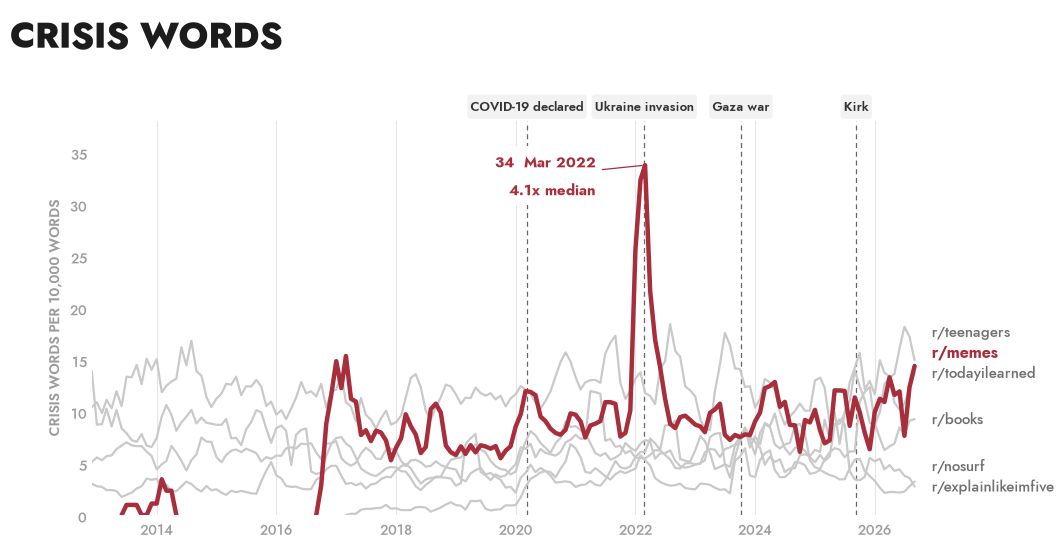

In [147]:
CHIPS = [(v, EV_SHORT[k]) for k, v in EVENTS.items()]


def _axbox(fig, left, bottom, right, top):
    # margins in inches
    W, H = fig.get_size_inches()
    return [left / W, bottom / H, (W - left - right) / W, (H - bottom - top) / H]


def _top_in(fig, top_frac):
    # inches from top to plot area
    return (1 - top_frac) * fig.get_figheight()


def _year_axis(ax, step=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(step, month=1, day=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)


def c20():
    d = load_daily()
    months = pd.date_range(d.day.min().to_period("M").to_timestamp(), d.day.max().to_period("M").to_timestamp(), freq="MS")
    raw, sm = {}, {}
    for s in ORDER:
        x = d[d.subreddit == s].assign(month=lambda z: z.day.dt.to_period("M").dt.to_timestamp())
        g = x.groupby("month")[["hits_crisis", "tokens"]].sum()
        g = g[g.tokens >= 50_000]
        r = g.hits_crisis / g.tokens * 1e4
        raw[s] = r
        f = r.reindex(months).fillna(0).rolling(3, min_periods=1, center=True).mean()  # gap months = 0, ramps to axis
        sm[s] = f.where((f > 0) | (f.shift(1) > 0) | (f.shift(-1) > 0))  # no flat zero line through empty years
    pk, pv = sm["memes"].idxmax(), sm["memes"].max()
    finding = (f"Crisis talk spikes once in r/memes ({pk:%b %Y}: {pv:.0f} per 10,000 words, {pv / raw['memes'].median():.1f}x "
               f"its median); the other communities peak at different times.")
    ymax = 38
    with h4_style():
        fig = plt.figure(figsize=(11, 6.2))
        top = _top_in(fig, h4_title(fig, "Crisis words"))
        ax = fig.add_axes(_axbox(fig, 0.95, 1.0, 1.75, top + 0.45))
        for s in ORDER:
            if s != "memes":
                ax.plot(sm[s].index, sm[s], color="#c9c9c9", lw=1.6, zorder=3, solid_capstyle="round")
        ax.plot(sm["memes"].index, sm["memes"], color=H4_SUB["memes"], lw=3.2, zorder=6, solid_capstyle="round")
        placed = []  # dodge end labels
        for v, s in sorted((sm[s].iloc[-1], s) for s in ORDER):
            placed.append((max(v, placed[-1][0] + 0.052 * ymax) if placed else v, s))
        for y, s in placed:
            hi = s == "memes"
            ax.text(1.012, y, f"r/{s}", transform=ax.get_yaxis_transform(), fontsize=11.5 if hi else 10.5, fontweight=700 if hi else 500,
                    color=h4_text_color(H4_SUB[s]) if hi else H4_MUTED, va="center", ha="left")
        ax.annotate(f"{pv:.0f}  {pk:%b %Y}\n{pv / raw['memes'].median():.1f}x median", xy=(pk, pv), xytext=(pk - pd.Timedelta(days=300), pv - 1),
                    ha="right", va="center", fontsize=10.5, fontweight=700, color=H4_SUB["memes"], linespacing=1.3,
                    bbox=dict(boxstyle="square,pad=0.15", fc="white", ec="none"), zorder=8,
                    arrowprops=dict(arrowstyle="-", color=H4_SUB["memes"], lw=0.9, shrinkA=3, shrinkB=2))
        h4_chips(ax, CHIPS, ypos=1.0)
        _year_axis(ax, 2)
        ax.set_xlim(pd.Timestamp("2012-12-01"), pd.Timestamp("2026-10-15"))
        ax.set_ylim(0, ymax)
        ax.set_yticks(range(0, 36, 5))
        ax.set_ylabel("CRISIS WORDS PER 10,000 WORDS")
        return h4_done(fig, finding)


fig = c20()
display(Markdown(f"**{fig.h4_finding}**"))
plt.show()

## 3.4 Did each event reach each community?

Nearly every event reached nearly every community

**What we did:** Counted event-specific words per 10,000 words in the 4 weeks after each event and compared them with the 8 weeks before. The words are covid/pandemic/lockdown, Ukraine/Russia/Putin/invasion, Gaza/Hamas/Israel/Palestine and Kirk/Turning Point/assassination. To judge a change we repeated the same calculation at 400 random fake dates. The share of fake dates with an equal or larger change is p. The chart shows one panel per event, and solid bars are beyond random dates (p < 0.05).

**Result:** Event words rose in 13 of 16 community-event pairs (p < 0.05 against random dates). The change per 10,000 words:

- Short-form: +8.2 (COVID), +56.4 (Ukraine), +5.6 (Gaza), +4.1 (Kirk)
- Long-form: +4.6, +2.1, +3.9, +2.0
- r/nosurf: +6.3, +5.0, +5.0, +5.2
- r/todayilearned: +4.0 for COVID, but not for the other three (+0.4, -0.6, +0.3)

**Every event reached the communities: event words rose in 13 of 16 community-event pairs (p < 0.05 against random dates); r/todayilearned barely reacted to 3 of the four events.**

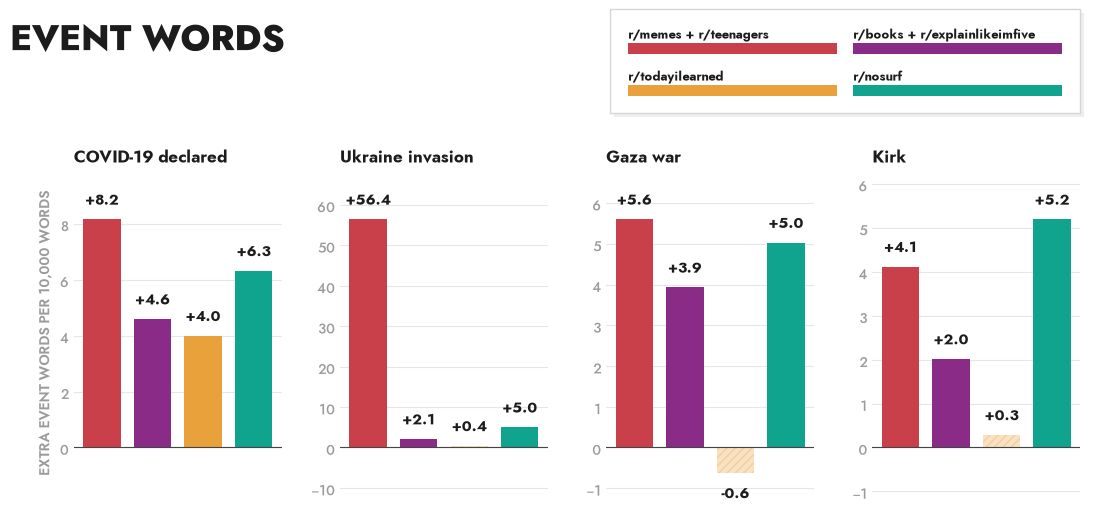

In [148]:


def _eff(group, event, outcome):
    t = effects_table_cached()
    r = t[(t.group == group) & (t.event == event) & (t.outcome == outcome)].iloc[0]
    return float(r.effect), float(r.p)


def c20b():
    gk = list(GROUPS)
    cells = {(n, g): _eff(g, n, EVENT_OUTCOME[n]) for n in EV_NAMES for g in gk}
    n_sig = sum(1 for (e, p) in cells.values() if p < 0.05 and e > 0)
    quiet = sum(1 for n in EV_NAMES if cells[(n, "baseline")][1] >= 0.05)
    finding = (f"Every event reached the communities: event words rose in {n_sig} of {len(cells)} community-event pairs (p < 0.05 against random dates); "
               f"r/todayilearned barely reacted to {quiet} of the four events.")
    with h4_style():
        fig, axes = plt.subplots(1, 4, figsize=(11, 5.9))
        top = _top_in(fig, h4_title(fig, "Event words"))
        for ax, n in zip(axes, EV_NAMES):
            vals = [cells[(n, g)] for g in gk]
            m = max(abs(v[0]) for v in vals) or 1
            for i, (g, (e, p)) in enumerate(zip(gk, vals)):
                sig = p < 0.05
                ax.bar(i, e, color=H4_GROUP[g], alpha=1 if sig else 0.3, width=0.74, hatch=None if sig else "////", ec=H4_GROUP[g], lw=0)
                ax.text(i, e + 0.04 * m * (1 if e >= 0 else -1), f"{e:+.1f}", ha="center", va="bottom" if e >= 0 else "top", fontsize=10.5,
                        fontweight=700, color=H4_INK)
            ax.set_title(f"{EV_SHORT[n]}", fontsize=12.5, fontweight=700, pad=8)
            ax.axhline(0, color="#444", lw=0.8)
            ax.set_xticks([])
            ax.grid(axis="x", visible=False)
            ax.set_ylim(-0.2 * m, 1.2 * m)
        axes[0].set_ylabel("EXTRA EVENT WORDS PER 10,000 WORDS")
        fig.subplots_adjust(top=1 - (top + 0.95) / fig.get_figheight(), bottom=0.16, left=0.07, right=0.985, wspace=0.28)
        h4_legend(fig, [(H4_GROUP_LABEL[g], H4_GROUP[g], None) for g in gk] , ncol=2, col_w=2.25)
        return h4_done(fig, finding)


fig = c20b()
display(Markdown(f"**{fig.h4_finding}**"))
plt.show()

## 3.5 Did tone get more negative after the events?

A small dip in tone, too weak to call a finding

**What we did:** Measured the change in mean VADER compound score (-1 to +1) in the 4 weeks after each event versus the 8 weeks before. The tile matrix shows four community groups and four events: dark blue = tone fell, amber = tone rose, magenta = no change. A ring marks tiles beyond the placebo range (p < 0.05), and each tile shows its p-value.

**Result:** After the three violent events (Ukraine, Gaza, Kirk) tone was lower in 11 of the 12 community-event pairs, by up to 0.05 compound points. The twelfth, r/todayilearned after Kirk, is zero. The largest drops:

- r/nosurf: Kirk -0.053, Gaza -0.050
- r/todayilearned: Ukraine -0.044
- long-form: Ukraine -0.038

After the COVID declaration tone rose slightly in three groups (+0.007 to +0.019) and fell in r/nosurf (-0.037). Three of the 16 tiles are ringed: r/nosurf after Gaza (p = 0.04) and after Kirk (p = 0.03), and r/todayilearned after Ukraine (p = 0.04). About 0.8 would be expected by chance, so we do not call this a finding. For scale, r/nosurf's mean tone fell by 0.20 over nine years (0.36 in 2017, 0.16 in 2026).

**After the three violent events tone dipped in 11 of 12 community-event pairs, by no more than 0.05 compound points; 3 of 16 tests (ringed) fall outside random dates, 0.8 expected by chance alone.**

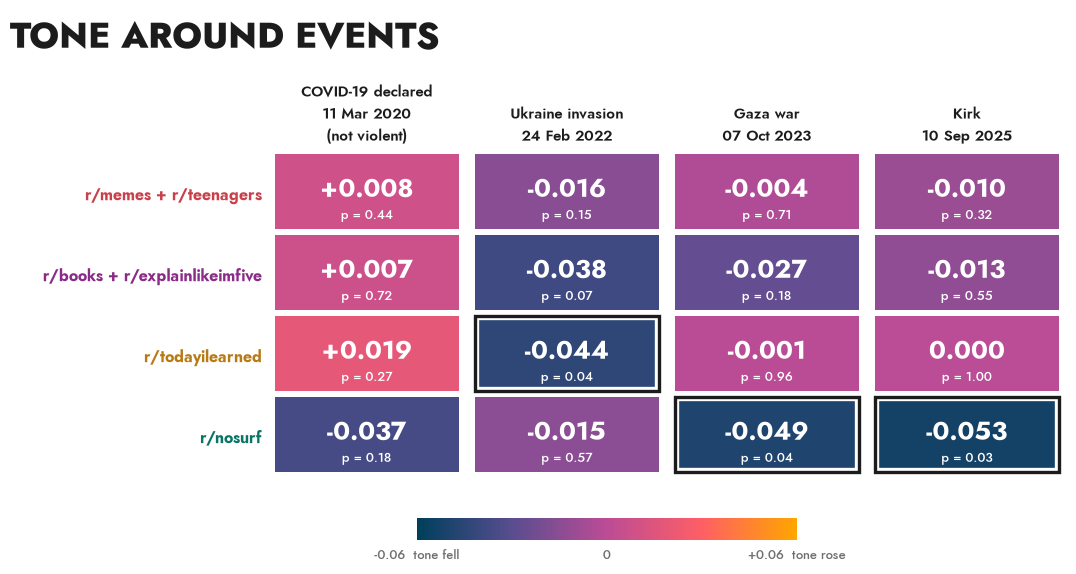

In [149]:
GROUP_LABEL = H4_GROUP_LABEL


def c21():
    gk = list(GROUPS)
    cells = {(n, g): _eff(g, n, "sentiment") for n in EV_NAMES for g in gk}
    dips = sum(1 for n in EV_NAMES[1:] for g in gk if cells[(n, g)][0] < -0.0005)  # |change| < 0.0005 = none
    mx = max(abs(e) for e, _ in cells.values())
    n_sig = sum(1 for _, p in cells.values() if p < 0.05)
    finding = (f"After the three violent events tone dipped in {dips} of 12 community-event pairs, by no more than {mx:.2f} compound points; "
               f"{n_sig} of {len(cells)} tests (ringed) fall outside random dates, {0.05 * len(cells):.1f} expected by chance alone.")
    LIM = 0.06
    with h4_style():
        fig = plt.figure(figsize=(11, 6.5))
        top = _top_in(fig, h4_title(fig, "Tone around events"))
        ax = fig.add_axes(_axbox(fig, 2.7, 1.7, 0.3, top + 0.75))
        for j, n in enumerate(EV_NAMES):
            for i, g in enumerate(gk):
                e, p = cells[(n, g)]
                rgb = H4_RAMP(0.5 + 0.5 * np.clip(e / LIM, -1, 1))  # 0 = ramp middle, like c26
                ax.add_patch(Rectangle((j + 0.04, i + 0.04), 0.92, 0.92, fc=rgb, ec="none"))
                if p < 0.05:  # white halo, shows on any tile
                    ax.add_patch(Rectangle((j + 0.04, i + 0.04), 0.92, 0.92, fc="none", ec="white", lw=6))
                    ax.add_patch(Rectangle((j + 0.04, i + 0.04), 0.92, 0.92, fc="none", ec=H4_INK, lw=2.4))
                dark = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2] < 0.55  # luminance flip for text
                ax.text(j + 0.5, i + 0.45, "0.000" if abs(e) < 0.0005 else f"{e:+.3f}", ha="center", va="center", fontsize=19, fontweight=700,
                        color="white" if dark else H4_INK)
                ax.text(j + 0.5, i + 0.78, f"p = {p:.2f}", ha="center", va="center", fontsize=9.5, color="white" if dark else H4_MUTED)
        ax.set_xlim(0, 4)
        ax.set_ylim(4, 0)
        ax.grid(False)
        ax.set_xticks(np.arange(4) + 0.5, [f"{EV_SHORT[n]}\n{pd.Timestamp(EVENTS[n]):%d %b %Y}" + ("\n(not violent)" if k == 0 else "")
                                           for k, n in enumerate(EV_NAMES)], fontsize=11, color=H4_INK, fontweight=600)
        ax.xaxis.tick_top()
        ax.set_yticks(np.arange(4) + 0.5, [GROUP_LABEL[g] for g in gk], fontsize=11.5, fontweight=700)
        for t, g in zip(ax.get_yticklabels(), gk):
            t.set_color(h4_text_color(H4_GROUP[g]))
        cax = fig.add_axes(_axbox(fig, 4.2, 1.05, 3.0, fig.get_figheight() - 1.27))
        cax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=H4_RAMP, extent=[-LIM, LIM, 0, 1])
        cax.set_yticks([])
        cax.set_xticks([-LIM, 0, LIM], [f"-{LIM}  tone fell", "0", f"+{LIM}  tone rose"], fontsize=9.5, color=H4_MUTED)
        cax.grid(False)
        return h4_done(fig, finding)


fig = c21()
display(Markdown(f"**{fig.h4_finding}**"))
plt.show()

## 3.6 Did talk about doomscrolling rise after the events?

Doomscroll talk climbs, with or without crises

**What we did:** Counted `doomscroll*` and `doom surf*` mentions per 10,000 words in r/nosurf only, where we hold every comment. The rate is weekly, as a 4-week rolling rate from 2020. The chart is smoothed once more with a 5-week moving average, but the numbers below come from the unsmoothed rate. The events are dashed lines, and the 4 test weeks after each are pale bands.

**Result:** The rate climbs steadily. Per 10,000 words it is:

- 0.08 in 2020, 0.29 in 2021, 0.66 in 2022, 1.14 in 2023
- 1.88 in 2024, 3.24 in 2025, 4.95 in 2026 (to September)

The 4-week rate peaked at 6.3 in the week of 19 July 2026 and is 3.8 now. The four-week changes at the events are small blips on that rise: COVID 0.0 (p = 1.0), Ukraine +0.8 (p = 0.05), Gaza +0.5 (p = 0.16), Kirk -0.3 (p = 0.28), against a random-date spread of about 0.3. So the events do not explain the climb.

**Doomscroll talk in r/nosurf climbed from 0.08 per 10,000 words in 2020 to 5.0 in 2026; the four events are small blips on that rise.**

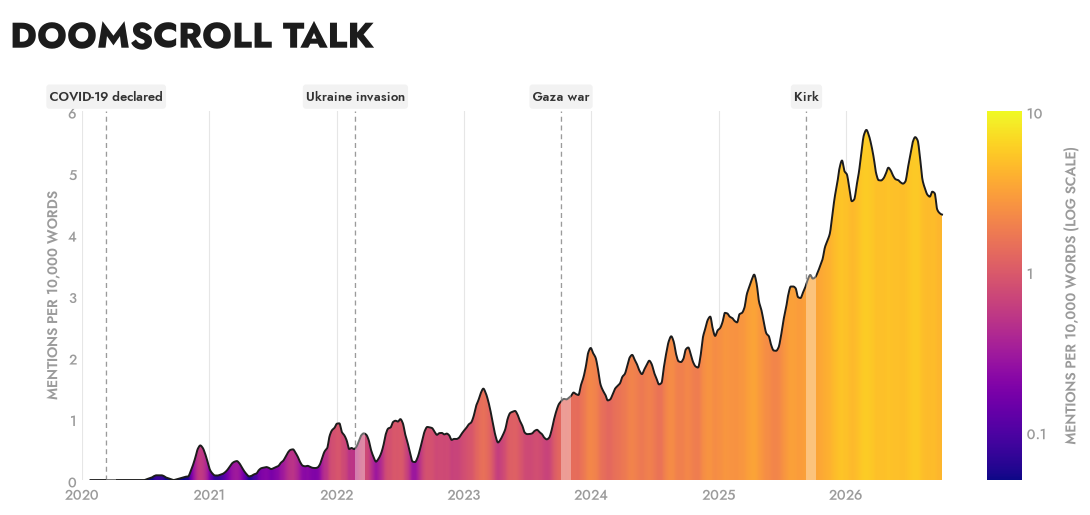

In [150]:
def _fmt(v):
    return f"{v:.2f}" if abs(v) < 1 else f"{v:.1f}"


def c22():
    d = load_daily()
    x = d[d.subreddit == "nosurf"].set_index("day")[["hits_doom", "tokens"]]
    yr = x.groupby(x.index.year).sum()
    yr_rate = yr.hits_doom / yr.tokens * 1e4
    w = x.resample("W").sum()
    w = w[w.index >= "2020-01-01"]
    r = (w.hits_doom.rolling(4).sum() / w.tokens.rolling(4).sum() * 1e4).dropna()  # 4wk rate = number in text
    sm = r.rolling(5, center=True, min_periods=1).mean()  # display only: 5wk avg + pchip
    days = pd.date_range(sm.index[0], sm.index[-1], freq="D")
    yv = PchipInterpolator(mdates.date2num(sm.index), sm.to_numpy())(mdates.date2num(days))
    finding = (f"Doomscroll talk in r/nosurf climbed from {_fmt(yr_rate[2020])} per 10,000 words in 2020 to {_fmt(yr_rate[2026])} in 2026; "
               f"the four events are small blips on that rise.")
    with h4_style():
        fig = plt.figure(figsize=(11, 5.6))
        top = _top_in(fig, h4_title(fig, "Doomscroll talk"))
        ax = fig.add_axes(_axbox(fig, 0.85, 0.75, 1.45, top + 0.35))
        cax = fig.add_axes(_axbox(fig, 9.9, 0.75, 0.75, top + 0.35))
        ax.plot(days, yv, color=H4_INK, lw=1.4, zorder=4)
        norm, cmap = LogNorm(0.05, 10), plt.get_cmap("plasma")  # plasma log, like danylo's posts/day
        xn = mdates.date2num(days)
        grad = cmap(norm(np.clip(yv, 0.05, 10)))[None, :, :]
        poly = Polygon(np.column_stack([np.r_[xn, xn[::-1]], np.r_[yv, np.zeros(len(yv))]]), facecolor="none", edgecolor="none")
        ax.add_patch(poly)
        ymax = float(np.ceil(yv.max()))
        im = ax.imshow(grad, extent=[xn[0], xn[-1], 0, ymax], aspect="auto", origin="lower", zorder=3, interpolation="bilinear")
        im.set_clip_path(poly)
        for n in EV_NAMES:
            t = pd.Timestamp(EVENTS[n])
            ax.axvspan(t, t + pd.Timedelta(days=28), color="white", alpha=0.35, lw=0, zorder=5)
        h4_chips(ax, CHIPS, ypos=1.0)
        _year_axis(ax, 1)
        ax.set_ylim(0, ymax)
        ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2026-11-01"))
        ax.set_ylabel("MENTIONS PER 10,000 WORDS")
        cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax)
        cb.outline.set_visible(False)
        cb.set_ticks([0.1, 1, 10], labels=["0.1", "1", "10"])
        cb.ax.minorticks_off()
        cb.ax.tick_params(labelsize=10, length=0)
        cb.set_label("MENTIONS PER 10,000 WORDS (LOG SCALE)", labelpad=10)
        return h4_done(fig, finding)


fig = c22()
display(Markdown(f"**{fig.h4_finding}**"))
plt.show()

## 3.7 Did brainrot words spike around the crises?

Are brainrot spikes really tied to major events?

**What we did:** Counted brainrot words per 10,000 words in r/memes + r/teenagers (monthly, 3-month mean) and drew one band per word, thickness = rate. The axis starts in January 2022, because COVID-19 (March 2020) came before the slang existed. Then we pooled all the words and compared the 8 weeks before each event with the weeks after it, against random dates (every day from November 2022 that is more than 120 days from an event).

**Result:** In all six subreddits together, rizz is 83% of brainrot-word hits in 2022. Skibidi (23%) and gyatt (9%) join in 2023, and 'brain rot' / 'brainrot' take 41% in 2024 and 72% in 2025. The pooled rate in r/memes + r/teenagers, per 10,000 words:

- Gaza war, 4 weeks after: 0.95 before, 1.53 after (+0.58, p = 0.41), no jump yet
- Gaza war, 8 weeks after: 0.95 before, 3.40 after (+2.44), beyond every random date (they give -1.41 to +1.41)
- Kirk, 8 weeks after: 0.96 before, 1.11 after (+0.16, p = 0.69)

The jump comes late: the weekly rate is 4.45, 11.00 and 5.36 in weeks 5, 6 and 7 after 7 October 2023, against 0.43 to 1.65 in the 8 weeks before. We chose the 8-week window after seeing this weekly series, so read the p-value as a guide. With all six subreddits pooled the Gaza change is smaller (+0.38, p = 0.035). Week 6 rests on 25 sampled comments with brainrot words, from 24 authors on 3 days. The comments are not about the war: of 91 comments with brainrot words in November 2023, none mentions Gaza, Israel, Palestine or Hamas.

So brainrot words do jump after the Gaza war, five to seven weeks late and not about the war. We cannot tell whether the crisis or the slang's own rise drove it. After Kirk's killing pretty much 
nothing moves.

**Brainrot words in r/memes and r/teenagers jump after the Gaza war and peak 6 weeks later (+2.4 per 10,000 words over the 8 weeks after, p < 0.01), but not after Kirk's killing (+0.2, p = 0.69).**

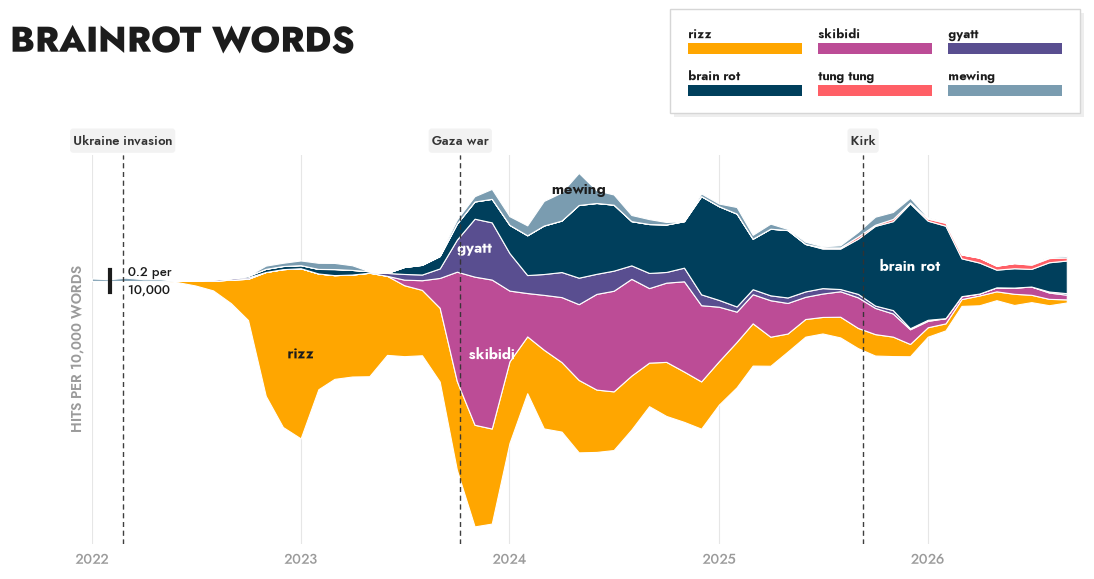

In [151]:
SHORT = ["memes", "teenagers"]


TERM_ORDER = ["rizz", "skibidi", "gyatt", "brain rot", "tung tung", "mewing"]


def _pooled(subs, name, post):
    # all brainrot words pooled: change in rate (post days after vs 56 before), placebo p over every day from 2022-11 that is >120 days from an event, peak week after
    hits, words = term_daily(subs)
    h = hits.sum(axis=1)
    ch, cw = np.r_[0, h.to_numpy().cumsum()], np.r_[0, words.to_numpy().cumsum()]
    rate = lambda a, b: (ch[b + 1] - ch[a]) / max(cw[b + 1] - cw[a], 1) * 1e4
    real = [pd.Timestamp(v) for v in EVENTS.values()]
    pool = [d for d in pd.date_range("2022-11-01", "2026-08-01") if all(abs((d - r).days) > 120 for r in real)]
    fake = np.array([rate(i, i + post - 1) - rate(i - 56, i - 1) for i in (h.index.get_loc(d) for d in pool)])
    i0 = h.index.get_loc(pd.Timestamp(EVENTS[name]))
    change = rate(i0, i0 + post - 1) - rate(i0 - 56, i0 - 1)
    peak = int(np.argmax([rate(i0 + 7 * w, i0 + 7 * w + 6) for w in range(13)]))
    return change, float((np.abs(fake) >= abs(change)).mean()), peak


def c23():
    tt = pd.read_parquet(AGG / "lexicon_terms_by_month.parquet")
    tt = tt[(tt.type == "comment") & tt.tier.isin(["core", "extended"]) & tt.subreddit.isin(SHORT)].copy()
    tt["g"] = tt["term"].map(term_group)
    ov = pd.read_parquet(AGG / "overview_counts.parquet")
    tok = ov[(ov.type == "comment") & ov.subreddit.isin(SHORT)].groupby("month")["tokens"].sum()
    full = pd.date_range("2022-01-01", "2026-09-01", freq="MS")
    p = tt.groupby(["month", "g"])["n"].sum().unstack().reindex(columns=TERM_ORDER).reindex(full).fillna(0)
    rate = (p.div(tok.reindex(full), axis=0) * 1e4).rolling(3, min_periods=1, center=True).mean()
    g, pg, wk = _pooled(SHORT, EV_NAMES[2], 56)
    k, pk, _ = _pooled(SHORT, EV_NAMES[3], 56)
    pf = lambda p: "p < 0.01" if p < 0.01 else f"p = {p:.2f}"
    finding = (f"Brainrot words in r/memes and r/teenagers jump after the Gaza war and peak {wk} weeks later ({g:+.1f} per 10,000 words over the 8 weeks after, "
               f"{pf(pg)}), but not after Kirk's killing ({k:+.1f}, {pf(pk)}).")
    with h4_style():
        fig = plt.figure(figsize=(11, 6.2))
        top = _top_in(fig, h4_title(fig, "Brainrot words"))
        ax = fig.add_axes(_axbox(fig, 0.95, 0.75, 0.3, top + 0.75))
        y = rate.T.to_numpy()
        ax.stackplot(rate.index, y, colors=[H4_TERMS[t] for t in TERM_ORDER], baseline="wiggle", edgecolor="white", linewidth=0.8)
        m = len(TERM_ORDER)
        base = -(y * (m - 0.5 - np.arange(m)[:, None])).sum(axis=0) / m
        lower = base + np.vstack([np.zeros(y.shape[1]), np.cumsum(y, axis=0)[:-1]])
        thick = y.sum(axis=0).max()
        for i, t in enumerate(TERM_ORDER):
            j = int(np.argmax(y[i]))
            if y[i, j] >= 0.06 * thick:
                ax.text(rate.index[j], lower[i, j] + y[i, j] / 2, t, ha="center", va="center", fontsize=10.5, fontweight=700,
                        color="white" if t in ("brain rot", "gyatt", "tung tung", "skibidi") else H4_INK)
        ax.set_yticks([])
        ax.set_ylabel("HITS PER 10,000 WORDS")
        ax.plot([pd.Timestamp("2022-02-01")] * 2, [-0.1, 0.1], color=H4_INK, lw=3)
        ax.text(pd.Timestamp("2022-03-05"), 0, "0.2 per\n10,000", va="center", fontsize=9, color=H4_INK)
        for date, _lab in CHIPS[1:]:
            ax.axvline(pd.Timestamp(date), color="#333", lw=0.9, ls=(0, (4, 3)), alpha=0.75, zorder=5)
        h4_chips(ax, CHIPS[1:], ypos=1.0)
        ax.set_xlim(full[0], full[-1])
        ax.grid(axis="y", visible=False)
        ax.xaxis.set_major_locator(mdates.YearLocator(1, month=1, day=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        h4_legend(fig, [(t, H4_TERMS[t], None) for t in TERM_ORDER], ncol=3, col_w=1.3, y_top=1 - 0.1 / 6.2)
        return h4_done(fig, finding)


fig = c23()
display(Markdown(f"**{fig.h4_finding}**"))
plt.show()

## 3.8 Did posting sessions in r/nosurf get longer?

Posting sessions barely move, with one lead after Ukraine

**What we did:** Built gap-based sessions (messages by one author with gaps of at most 30 minutes) from comments and submissions, r/nosurf only. Kept sessions with 2 or more messages and split them into five length buckets (1 minute, 2-4, 5-9, 10-29, 30+). Bars show the share of sessions in each bucket: light outlined bars are the 8 weeks before, solid bars the 4 weeks after. As a yardstick we repeated the largest bucket shift at 100 random fake dates.

**Result:** The share of sessions with two or more messages, before vs after:

- COVID: 11.5% vs 11.4%
- Ukraine: 13.9% vs 11.9%
- Gaza: 12.5% vs 13.3%
- Kirk: 17.0% vs 16.0%

Around COVID, Gaza and Kirk no length bucket moves by more than 3.3 percentage points, and the median session stays at 6 to 7 minutes.

After the Russian invasion of Ukraine the 10-29 minute bucket grows from 30% to 39% of the sessions with two or more messages (+9.2 points), while 1-minute and 2-4-minute sessions shrink (21% to 17% each). That shift is beyond what random dates produce (p = 0.02). With four events tested, one p-value of 0.02 or lower happens about 8% of the time by chance, so it is a lead, not a conclusion.

So sessions are unchanged at COVID, Gaza and Kirk. Only the Ukraine invasion moves them.

**Posting sessions in r/nosurf kept their usual length around three events (no length bucket moves more than 3.3 points; typical session 6-9 minutes); after the Ukraine invasion the 10-29 min bucket grew from 30% to 39% of sessions, beyond what random dates produce (p = 0.02).**

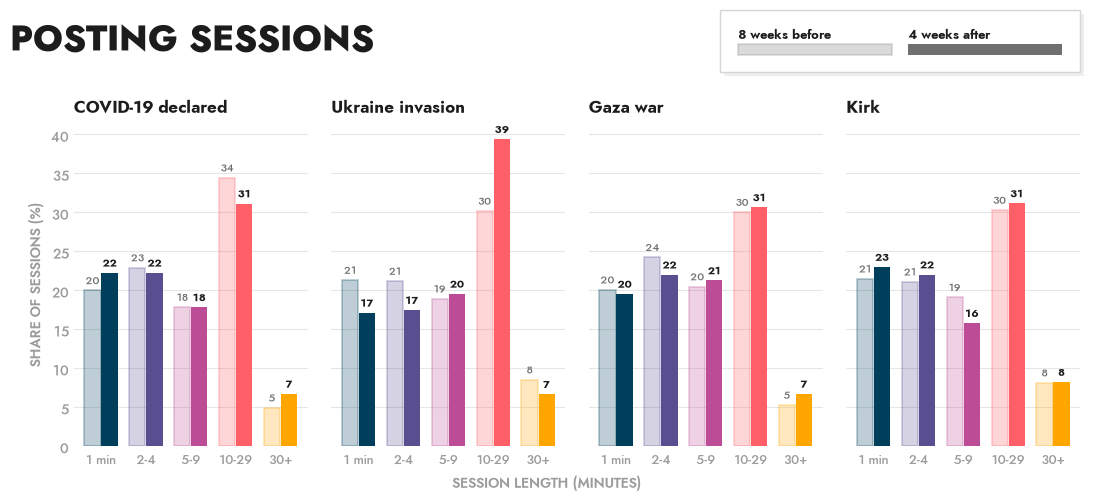

In [152]:
def c24():
    st = session_stats()
    W, med, big, top_n, others, p_big = st["W"], st["med"], st["big"], st["top"], st["others"], st["p"]
    allm = [v for m in med.values() for v in m]
    verb = "grew" if big[top_n][1] > big[top_n][0] else "shrank"
    finding = (f"Posting sessions in r/nosurf kept their usual length around three events (no length bucket moves more than {others:.1f} points; typical session "
               f"{min(allm):.0f}-{max(allm):.0f} minutes); after the {EV_SHORT[top_n]} the {big[top_n][2]} min bucket {verb} from {big[top_n][0]:.0f}% to "
               f"{big[top_n][1]:.0f}% of sessions, {'beyond' if p_big < 0.05 else 'within'} what random dates produce (p = {p_big:.2f}).")
    with h4_style():
        fig, axes = plt.subplots(1, 4, figsize=(11, 5.6), sharey=True)
        top = _top_in(fig, h4_title(fig, "Posting sessions"))
        for ax, n in zip(axes, EV_NAMES):
            a, b = W[n]
            for k, (lo, hi, lab) in enumerate(BUCKETS):
                sa, sb = ((a >= lo) & (a <= hi)).mean() * 100, ((b >= lo) & (b <= hi)).mean() * 100
                col = H4_RAMP_COLORS[k]
                ax.bar(k - 0.19, sa, width=0.36, facecolor=col, alpha=0.25, edgecolor=col, linewidth=1.4)
                ax.bar(k + 0.19, sb, width=0.36, color=col)
                ax.text(k - 0.19, sa + 0.8, f"{sa:.0f}", ha="center", fontsize=8, color=H4_MUTED)
                ax.text(k + 0.19, sb + 0.8, f"{sb:.0f}", ha="center", fontsize=8, fontweight=700, color=H4_INK)
            ax.set_title(EV_SHORT[n], fontsize=12.5, fontweight=700, pad=8)
            ax.set_xticks(range(5), [b[2] for b in BUCKETS], fontsize=9)
            ax.grid(axis="x", visible=False)
        axes[0].set_ylabel("SHARE OF SESSIONS (%)")
        fig.text(0.5, 0.125, "SESSION LENGTH (MINUTES)", ha="center", fontsize=10, fontweight=600, color=H4_FAINT)
        fig.subplots_adjust(top=1 - (top + 0.45) / 5.6, bottom=0.2, left=0.07, right=0.985, wspace=0.1)
        h4_legend(fig, [("8 weeks before", H4_MUTED, "outline"), ("4 weeks after", H4_MUTED, None)], ncol=2, col_w=1.7)
        return h4_done(fig, finding)


fig = c24()
display(Markdown(f"**{fig.h4_finding}**"))
plt.show()

## 3.9 Do the same r/nosurf authors write differently after an event?

The same authors write less positively

**What we did:** Took authors with comments in both windows (8 weeks before, 4 weeks after). Each dot is one author's change in mean VADER score, and the cloud shows the same data as a distribution. The big dot and bar are the mean with a 95% bootstrap interval, and the gray band is the 95% range of the same statistic at 120 random fake dates.

**Result:** The same authors wrote less positively after all four events:

- COVID: -0.037 (322 authors)
- Ukraine: -0.042 (401)
- Gaza: -0.058 (385)
- Kirk: -0.070 (613)

The intervals of Gaza and Kirk exclude zero. Only the Kirk change lies outside the random-date band (-0.063 to +0.058). This is the tone of the text, not the mood of the people.

**The same r/nosurf authors wrote less positively after all four events (-0.07 to -0.04); 1 of 4 shifts falls outside random dates (Kirk).**

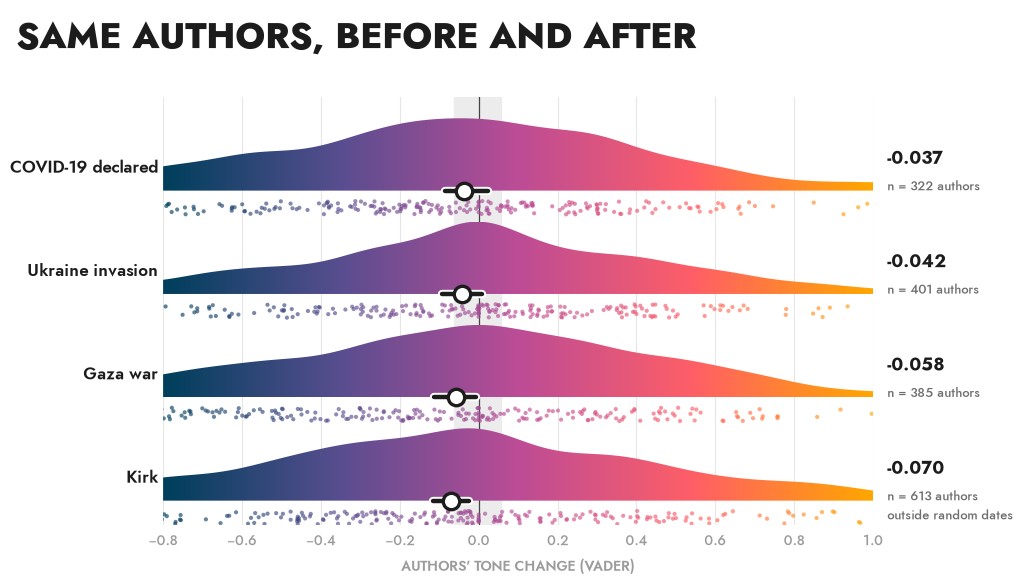

In [153]:
def c26():
    from scipy.stats import gaussian_kde
    D, CI, lo_f, hi_f = authors_stats()
    means = [D[n].mean() for n in EV_NAMES]
    outside = [n for n in EV_NAMES if D[n].mean() < lo_f or D[n].mean() > hi_f]
    direction = "less positively after all four events" if max(means) < 0 else "differently after the events"
    finding = (f"The same r/nosurf authors wrote {direction} ({min(means):+.2f} to {max(means):+.2f}); "
               f"{len(outside)} of 4 shifts {'falls' if len(outside) == 1 else 'fall'} outside random dates" + (f" ({', '.join(EV_SHORT[n] for n in outside)})." if outside else "."))
    norm = Normalize(-0.8, 1.0)
    with h4_style():
        fig = plt.figure(figsize=(11, 6.6))
        top = _top_in(fig, h4_title(fig, "Same authors, before and after"))
        ax = fig.add_axes(_axbox(fig, 1.6, 1.3, 2.3, top + 0.2))
        ax.axvspan(lo_f, hi_f, color="#ececec", zorder=0)
        ax.axvline(0, color="#444", lw=0.9, zorder=1)
        xs = np.linspace(-0.8, 1.0, 400)
        grad = H4_RAMP(norm(xs))[None, :, :]
        r2 = np.random.default_rng(1)
        for i, n in enumerate(EV_NAMES[::-1]):
            off, d = float(i), D[n]
            k = gaussian_kde(d, bw_method=0.18)(xs)
            k = k / k.max() * 0.7
            poly = Polygon(np.column_stack([np.r_[xs, xs[::-1]], np.r_[off + 0.14 + k, np.full_like(xs, off + 0.14)]]), facecolor="none", edgecolor="none",
                           transform=ax.transData)
            ax.add_patch(poly)
            im = ax.imshow(grad, extent=[xs[0], xs[-1], off + 0.14, off + 0.14 + 0.7], aspect="auto", origin="lower", zorder=3, interpolation="bilinear")
            im.set_clip_path(poly)
            sel = r2.choice(len(d), min(len(d), 240), replace=False)
            ax.scatter(d[sel], off + 0.04 - r2.uniform(0, 0.13, len(sel)), s=9, c=d[sel], cmap=H4_RAMP, norm=norm, alpha=0.65, lw=0, zorder=4)
            ax.plot(CI[n], [off + 0.14] * 2, color="white", lw=6, solid_capstyle="round", zorder=5)
            ax.plot(CI[n], [off + 0.14] * 2, color=H4_INK, lw=3.2, solid_capstyle="round", zorder=6)
            ax.scatter([d.mean()], [off + 0.14], s=140, color="white", ec=H4_INK, lw=2.4, zorder=7)
            ax.text(1.02, off + 0.46, f"{d.mean():+.3f}", transform=ax.get_yaxis_transform(), fontsize=13, fontweight=700, ha="left", va="center")
            note = f"n = {len(d)} authors" + ("\noutside random dates" if n in outside else "")
            ax.text(1.02, off + 0.28, note, transform=ax.get_yaxis_transform(), fontsize=9.5, ha="left", va="top", color=H4_MUTED)
        ax.set_yticks([i + 0.4 for i in range(4)], [EV_SHORT[n] for n in EV_NAMES[::-1]], fontsize=12, fontweight=600, color=H4_INK)
        ax.grid(axis="y", visible=False)
        ax.set_xlim(-0.8, 1.0)
        ax.set_ylim(-0.1, 4.05)
        ax.set_xlabel("AUTHORS' TONE CHANGE (VADER)")
        return h4_done(fig, finding)


fig = c26()
display(Markdown(f"**{fig.h4_finding}**"))
plt.show()

## 3.10 Result
Let's pull the threads together:

- **Events reach the communities.** Event words rose in 13 of 16 community-event pairs. r/todayilearned is the exception (4.4).
- **Tone: small, consistent direction, weak evidence.** Tone was lower after the three violent events in 11 of 12 pairs, by at most 0.05. Three of 16 tests are outside the placebo range, about what we expect by chance given many correlated tests (4.5). The same r/nosurf authors wrote 0.04-0.07 less positively afterwards, with only Kirk beyond random dates (4.9).
- **Doomscroll talk climbs steadily, and the events do not explain it.** In r/nosurf the rate went from 0.08 per 10,000 words in 2020 to 4.95 in 2026. The event effects are small blips (4.6).
- **Brainrot words jump weeks after the Gaza war, not after Kirk.** The pooled rate in r/memes + r/teenagers rises from 0.95 to 3.40 per 10,000 words in the 8 weeks after the Gaza war, peaking in week 6, beyond random dates. After Kirk's killing it does not move (0.96 to 1.11). The jump comes late and is not about the war, so we cannot say the crisis caused it (4.7).
- **Posting sessions** are unchanged at three events. After the Ukraine invasion r/nosurf sessions shifted towards 10-29 minutes (30% to 39% of sessions with 2+ messages, p = 0.02), one of four events (4.8).

**Verdict:** H4 is only weakly supported. The crises do reach the communities and tone dips a little afterwards, but too weakly to call a finding. Doomscroll talk climbs steadily, with or without crises. Brainrot words jump after the Gaza war, late and not connected to event itself.

# 4. Result
Conclusion is not here yet, work in progress
```
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣼⣿⣿⡟⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣴⡟
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣼⢟⣝⣿⣇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣼⡟⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣴⣭⣝⣿⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣾⡿⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣤⣤⣴⡞⣛⣿⣿⣿⣿⣿⣿⣧⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢠⣿⣿⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣀⣤⣴⣮⣽⣯⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣾⢷⣄⣀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣿⣿⠃⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⠴⣖⣋⣽⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣟⣻⡷⢦⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣾⣿⡿⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⣀⣠⣶⣿⣷⢾⣿⣿⣿⣿⣿⣛⣿⢿⣿⣿⣿⣿⣿⣿⣽⣿⣿⠛⣿⣿⣿⣿⣿⣿⣷⡄⠉⢳⣦⣀⠀⠀⠀⠀⢀⡄⠀⠀⠀⢀⣾⣟⣿⠁⠀⠀⠀⠀
⠀⠀⢀⣠⣴⣾⣿⢿⣭⣉⣿⣿⣿⣿⣿⡿⠿⠿⠿⠿⢿⣿⠿⣿⢿⢻⣿⣿⣿⣷⣿⣿⡀⣯⢙⡻⣿⣿⣦⡈⣙⣿⣶⣤⣀⣤⣾⡁⠀⢀⣀⣾⣿⣿⡏⠀⠀⠀⠀⠀
⠰⠿⣿⡿⠿⣟⠻⣶⠉⠿⠟⠉⢉⣉⣤⠤⠶⠶⢤⠀⡀⠙⢀⡈⠎⠊⠃⢻⣿⣿⣿⣿⣿⣿⣾⣿⣿⣿⣿⣧⣼⡿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠟⠃⢻⠀⠀⠀⠀⠀⠀
⠀⠀⠈⠻⠛⠛⠿⠥⠤⠶⠖⠊⠉⠉⠀⠀⠀⠀⠀⠀⠀⠀⠀⠁⠈⠀⠀⢿⠛⠿⣿⣿⣿⢿⡇⠀⠈⠉⠉⠻⠿⣷⣿⣿⣉⠻⡿⢛⣹⠟⠛⠳⣤⣿⣄⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠓⠒⠲⠶⠶⠤⠤⠤⣤⠀⠀⠀⠀⠀⠀⠀⠈⠛⠷⣶⡾⣿⣿⣾⣻⣦⡀⠤⢄⣰⣂⣈⣿⣿⣿⣦⡙⠻⢧⠀⠀⠀⠉⡻⢿⠤⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢸⠂⠰⢦⣤⠽⠦⢤⣄⣀⣀⣀⣀⣲⣿⣿⣷⣹⣧⡙⠿⠿⣿⣿⠋⠛⠺⣿⡿⢷⣾⣇⠀⠀⠀⠈⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣸⠀⠀⡼⠃⠀⠀⠀⠀⠈⠉⠉⠉⠉⠉⢹⣿⣿⣿⣧⡀⠀⠈⠛⠀⠀⠀⣽⣿⣿⣏⣿⡆⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣤⣾⠇⢀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢻⣿⣿⣿⣧⠀⠀⠀⠀⠀⠺⢻⣿⣿⣧⣽⡿⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢠⣾⡿⣿⣾⣰⢿⣧⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢻⣿⣟⣿⠂⠀⠀⠀⠾⢿⣿⣿⡿⠿⠋⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⡀⢈⣿⡿⣫⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⢀⣴⣾⣿⣿⣧⣤⣤⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣿⠟⢹⡇⠻⣫⣽⡿⢟⣛⣻⡀⠀⠀⠀⠀⠀⠀⣼⣿⠛⠻⢿⣿⣿⣿⡿⢷⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢀⣀⣤⣤⡾⠛⠁⣠⣼⢿⣿⣵⡤⠴⠚⠋⠉⠀⠀⠀⠀⠀⢀⡴⠯⣌⠻⠿⢮⡭⣸⣿⣧⢾⣧⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠘⠿⢿⣿⣿⣿⡿⠭⠚⠋⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣴⠛⠀⣀⠀⢀⣼⣿⣿⣿⠟⣡⣿⣿⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣰⡟⠀⠀⠀⠀⠀⣼⠃⠛⠛⣡⣾⠟⢛⡁⣧⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣤⠞⣹⡇⢀⠉⠀⠀⠀⢸⣷⣴⠞⠉⢀⣠⡿⠟⠋⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢠⣄⣾⡿⠷⠟⠋⠀⠀⢀⣀⣠⣶⠾⣋⣡⡶⠞⠋⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠸⣿⣿⣶⣶⣶⣶⣶⣛⣋⣉⣩⠶⠟⠋⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠉⠉⠉⠉⠉⠉⠉⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
```